Figure saved to: figures_code_comparison\fig_SETRA_HiVoSS_EN1990_weighting_functions_corrected.pdf


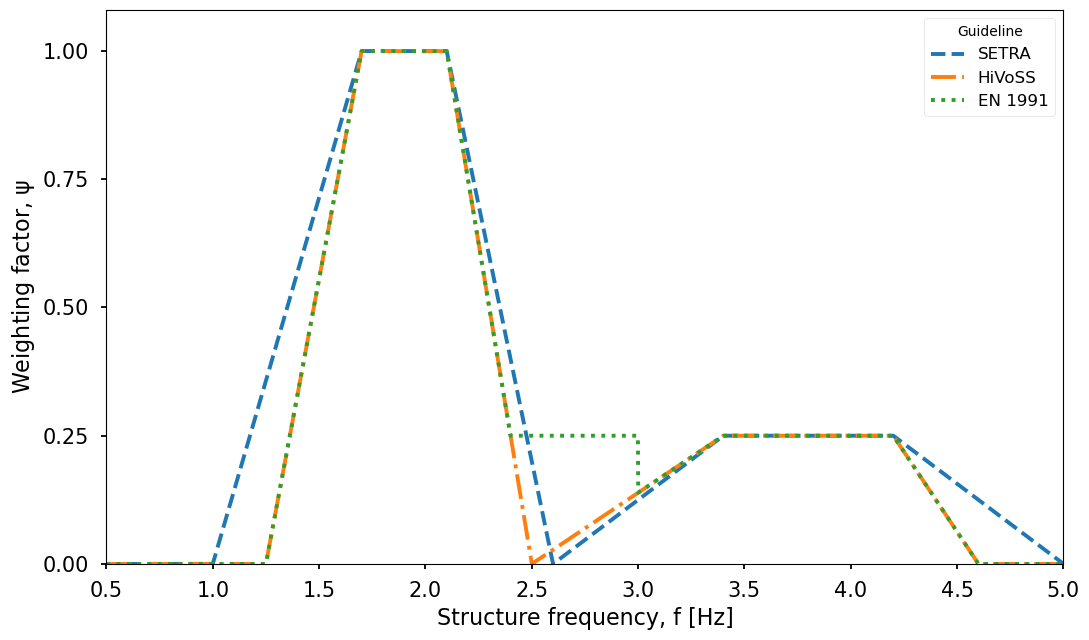

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STYLING
# ============================================================

plt.style.use('seaborn-v0_8-talk')
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'

# ============================================================
# HELPER FUNCTION
# ============================================================

def trapezoid(f, f1, f2, f3, f4, amplitude=1.0):
    """
    Piecewise trapezoid:
      0                 for f < f1
      linear rise       for f1 <= f < f2
      amplitude         for f2 <= f <= f3
      linear fall       for f3 < f <= f4
      0                 for f > f4
    """
    y = np.zeros_like(f, dtype=float)

    # Rising branch
    mask = (f >= f1) & (f < f2)
    y[mask] = amplitude * (f[mask] - f1) / (f2 - f1)

    # Plateau
    mask = (f >= f2) & (f <= f3)
    y[mask] = amplitude

    # Falling branch
    mask = (f > f3) & (f <= f4)
    y[mask] = amplitude * (f4 - f[mask]) / (f4 - f3)

    return y

# ============================================================
# FREQUENCY RANGE
# ============================================================

f = np.linspace(0, 5.05, 4000)

# ============================================================
# SETRA
# ============================================================

# 1st harmonic
setra_1 = trapezoid(
    f,
    f1=1.00,
    f2=1.70,
    f3=2.10,
    f4=2.60,
    amplitude=1.00
)

# 2nd harmonic (1/4 of first harmonic amplitude)
setra_2 = trapezoid(
    f,
    f1=2.60,
    f2=3.40,
    f3=4.20,
    f4=5.00,
    amplitude=0.25
)

# Governing curve
setra = np.maximum(setra_1, setra_2)

# ============================================================
# HIVOSS
# ============================================================

# 1st harmonic
hivoss_1 = trapezoid(
    f,
    f1=1.25,
    f2=1.70,
    f3=2.10,
    f4=2.50,   # corrected
    amplitude=1.00
)

# 2nd harmonic
hivoss_2 = trapezoid(
    f,
    f1=2.50,
    f2=3.40,
    f3=4.20,
    f4=4.60,
    amplitude=0.25
)

# Governing curve
hivoss = np.maximum(hivoss_1, hivoss_2)

# ============================================================
# EN 1990
# ============================================================

# Same base harmonic ranges as the EN figure
en_1 = trapezoid(
    f,
    f1=1.25,
    f2=1.70,
    f3=2.10,
    f4=2.50,   # corrected
    amplitude=1.00
)

en_2 = trapezoid(
    f,
    f1=2.50,
    f2=3.40,
    f3=4.20,
    f4=4.60,
    amplitude=0.25
)

# Minimum condition: psi_w >= 0.25 for 2.25 Hz to 3.00 Hz
en_floor = np.zeros_like(f)
en_floor[(f >= 2.25) & (f <= 3.00)] = 0.25

# Governing EN curve
en = np.maximum.reduce([en_1, en_2, en_floor])

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.plot(
    f, setra,
    linewidth=2.8,
    label='SETRA',
    linestyle='--',
)

ax.plot(
    f, hivoss,
    linewidth=2.8,
    label='HiVoSS',
    linestyle='-.',
)

ax.plot(
    f, en,
    linewidth=2.8,
    label='EN 1991',
    linestyle=':'
)

# ============================================================
# OPTIONAL MARKERS FOR EN MINIMUM REGION
# ============================================================




# ============================================================
# AXES / FORMATTING
# ============================================================

ax.set_xlim(0.5, 5.0)
ax.set_ylim(0, 1.08)

ax.set_xlabel('Structure frequency, f [Hz]')
ax.set_ylabel(r'Weighting factor, $\psi$')

from matplotlib.ticker import MultipleLocator

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

#ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
ax.legend(title='Guideline', loc='upper right', frameon=True)

# ============================================================
# SAVE FIGURE
# ============================================================

save_folder = "figures_code_comparison"
os.makedirs(save_folder, exist_ok=True)

save_path = os.path.join(
    save_folder,
    "fig_SETRA_HiVoSS_EN1990_weighting_functions_corrected.pdf"
)

plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

plt.show()

Figure saved to: figures_code_comparison\fig_EN1991_2_2023_walking_frequency_PDF_comparison.pdf


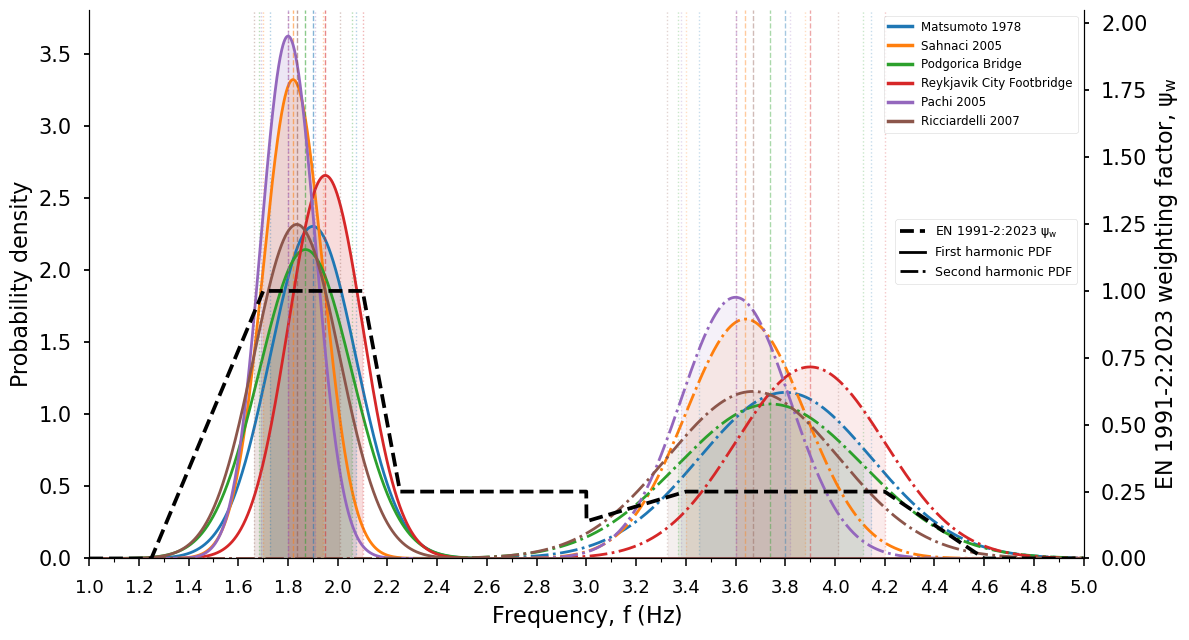

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import os


# ============================================================
# STYLING
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# NORMAL DISTRIBUTION DATA
# ============================================================

data = [
    {"label": "Matsumoto 1978",            "mean": 1.900, "sd": 0.173},
    {"label": "Sahnaci 2005",              "mean": 1.820, "sd": 0.120},
    {"label": "Podgorica Bridge",          "mean": 1.870, "sd": 0.186},
    {"label": "Reykjavik City Footbridge", "mean": 1.950, "sd": 0.150},
    {"label": "Pachi 2005",                "mean": 1.800, "sd": 0.110},
    {"label": "Ricciardelli 2007",         "mean": 1.835, "sd": 0.172},
]


def normal_pdf(x, mean, sd):
    return (
        1 / (sd * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((x - mean) / sd) ** 2)
    )


# ============================================================
# EN 1991-2:2023 WEIGHTING FUNCTION
# ============================================================

def psi_w_h1(x):

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # --------------------------------------------------------
    # First harmonic
    # --------------------------------------------------------

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # --------------------------------------------------------
    # Second harmonic
    # --------------------------------------------------------

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (
        1.0 - (x[m] - 4.20) / (4.60 - 4.20)
    )

    # --------------------------------------------------------
    # EN 1991-2:2023 minimum rule
    # psi_w >= 0.25 for 2.25 <= f <= 3.00 Hz
    # --------------------------------------------------------

    m = (x >= 2.25) & (x <= 3.00)

    psi[m] = np.maximum(
        psi[m],
        0.25
    )

    return psi


# ============================================================
# FREQUENCY RANGE
# ============================================================

x = np.linspace(1.0, 5.0, 4000)

psi_vals = psi_w_h1(x)


# ============================================================
# FIGURE
# ============================================================

fig, ax_pdf = plt.subplots(
    figsize=(12, 6.5)
)

# Second y-axis for EN weighting factor
ax_psi = ax_pdf.twinx()


# ============================================================
# EN 1991-2:2023 WEIGHTING FUNCTION
# RIGHT Y-AXIS
# ============================================================

psi_line, = ax_psi.plot(
    x,
    psi_vals,
    color="black",
    linestyle="--",
    linewidth=2.7,
    zorder=10,
    label=r"EN 1991-2:2023 $\psi_w$"
)


# ============================================================
# FIRST AND SECOND HARMONIC PDFs
# LEFT Y-AXIS
# ============================================================

source_handles = []

for item in data:

    label = item["label"]

    mean_1 = item["mean"]
    sd_1 = item["sd"]

    # Second harmonic distribution
    mean_2 = 2.0 * mean_1
    sd_2 = 2.0 * sd_1

    # --------------------------------------------------------
    # First harmonic PDF
    # --------------------------------------------------------

    y1 = normal_pdf(
        x,
        mean_1,
        sd_1
    )

    line1, = ax_pdf.plot(
        x,
        y1,
        linewidth=2,
        linestyle="-",
        label=label
    )

    line_color = line1.get_color()

    # Colour handle for source legend
    source_handles.append(
        Line2D(
            [0], [0],
            color=line_color,
            linewidth=2.5,
            label=label
        )
    )

    # --------------------------------------------------------
    # First harmonic ±1 SD region
    # --------------------------------------------------------

    m1_sigma = (
        (x >= mean_1 - sd_1)
        &
        (x <= mean_1 + sd_1)
    )

    ax_pdf.fill_between(
        x[m1_sigma],
        0,
        y1[m1_sigma],
        color=line_color,
        alpha=0.16
    )

    # Mean
    ax_pdf.axvline(
        mean_1,
        linestyle="--",
        linewidth=1,
        color=line_color,
        alpha=0.55
    )

    # ±1 SD
    ax_pdf.axvline(
        mean_1 - sd_1,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.35
    )

    ax_pdf.axvline(
        mean_1 + sd_1,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.35
    )

    # --------------------------------------------------------
    # Second harmonic PDF
    # --------------------------------------------------------

    y2 = normal_pdf(
        x,
        mean_2,
        sd_2
    )

    ax_pdf.plot(
        x,
        y2,
        linewidth=2,
        linestyle="-.",
        color=line_color
    )

    # --------------------------------------------------------
    # Second harmonic ±1 SD region
    # --------------------------------------------------------

    m2_sigma = (
        (x >= mean_2 - sd_2)
        &
        (x <= mean_2 + sd_2)
    )

    ax_pdf.fill_between(
        x[m2_sigma],
        0,
        y2[m2_sigma],
        color=line_color,
        alpha=0.09
    )

    # Mean
    ax_pdf.axvline(
        mean_2,
        linestyle="--",
        linewidth=1,
        color=line_color,
        alpha=0.40
    )

    # ±1 SD
    ax_pdf.axvline(
        mean_2 - sd_2,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.25
    )

    ax_pdf.axvline(
        mean_2 + sd_2,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.25
    )


# ============================================================
# X-AXIS
# ============================================================

ax_pdf.set_xlim(
    1.0,
    5.0
)

# Major ticks every 0.2 Hz
ax_pdf.xaxis.set_major_locator(
    MultipleLocator(0.2)
)

# Minor ticks every 0.1 Hz
ax_pdf.xaxis.set_minor_locator(
    MultipleLocator(0.1)
)

# One decimal place
ax_pdf.xaxis.set_major_formatter(
    FormatStrFormatter('%.1f')
)

# Proper engineering-style tick marks
ax_pdf.tick_params(
    axis='x',
    which='major',
    direction='out',
    length=6,
    width=1.1
)

ax_pdf.tick_params(
    axis='x',
    which='minor',
    direction='out',
    length=3,
    width=0.8
)


# ============================================================
# LEFT Y-AXIS — PDF
# ============================================================

ax_pdf.set_ylabel(
    r"Probability density"
)

ax_pdf.set_ylim(
    bottom=0
)

ax_pdf.tick_params(
    axis='y',
    direction='out'
)


# ============================================================
# RIGHT Y-AXIS — PSI
# ============================================================

ax_psi.set_ylabel(
    r"EN 1991-2:2023 weighting factor, $\psi_w$"
)

ax_psi.set_ylim(
    0,
    2.05
)

ax_psi.set_yticks(
    [0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
)

ax_psi.tick_params(
    axis='y',
    direction='out'
)


# ============================================================
# X LABEL
# ============================================================

ax_pdf.set_xlabel(
    r"Frequency, $f$ (Hz)"
)


# ============================================================
# TITLE
# ============================================================



# ============================================================
# NO GRID
# ============================================================

ax_pdf.grid(False)
ax_psi.grid(False)


# ============================================================
# LEGENDS
# ============================================================

harmonic_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.7,
        label=r"EN 1991-2:2023 $\psi_w$"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=2,
        label="First harmonic PDF"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-.",
        linewidth=2,
        label="Second harmonic PDF"
    ),
]

# ------------------------------------------------------------
# First legend: data sources at top-right
# ------------------------------------------------------------
legend_sources = ax_pdf.legend(
    handles=source_handles,
    fontsize=8.5,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
    frameon=True
)

ax_pdf.add_artist(legend_sources)

# ------------------------------------------------------------
# Second legend: line meaning below the first legend
# ------------------------------------------------------------
legend_lines = ax_pdf.legend(
    handles=harmonic_handles,
    fontsize=9,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.63),
    frameon=True
)
# ============================================================
# CLEAN SPINES
# ============================================================

# Keep conventional axes
ax_pdf.spines['top'].set_visible(False)
ax_psi.spines['top'].set_visible(False)


# ============================================================
# FINISH
# ============================================================

plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

save_folder = "figures_code_comparison"
os.makedirs(save_folder, exist_ok=True)

save_path = os.path.join(
    save_folder,
    "fig_EN1991_2_2023_walking_frequency_PDF_comparison.pdf"
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)

print(f"Figure saved to: {save_path}")
plt.show()

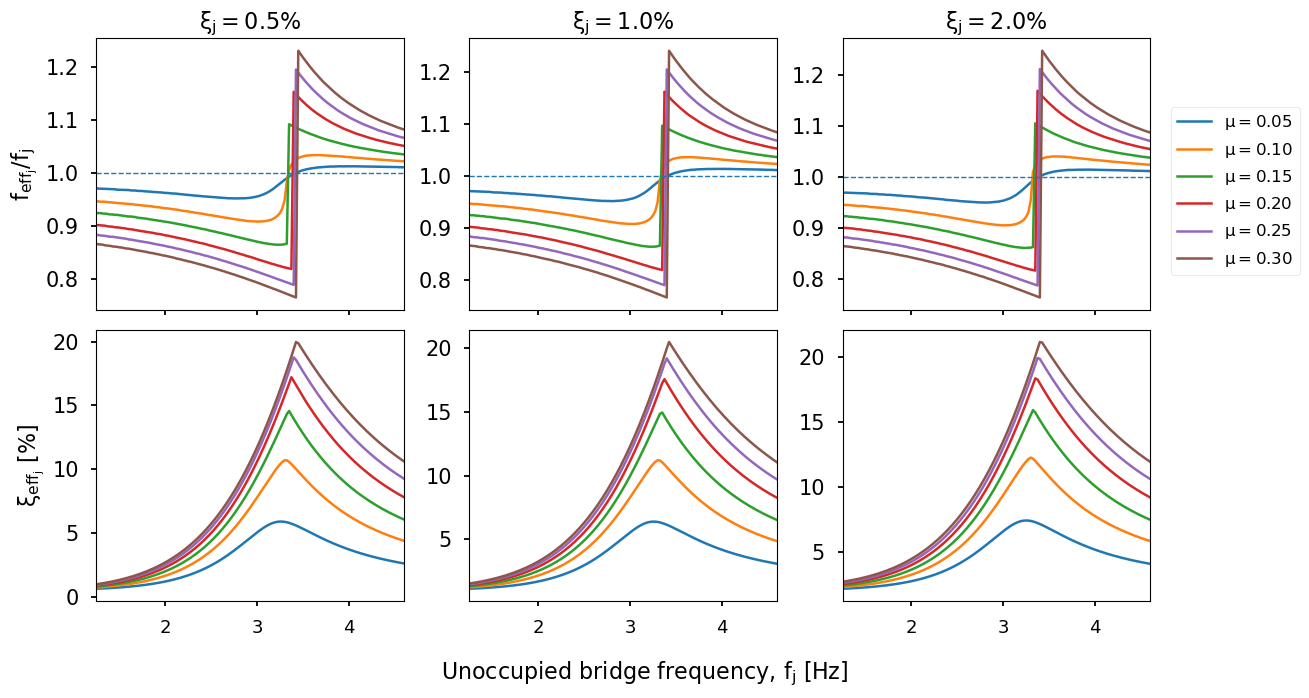

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STYLING
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# LOAD RESULTS
# ============================================================

with open("NMFR_2.pkl", "rb") as f:
    data = pickle.load(f)

results_all = data["results_all"]

bands_to_combine = list(results_all.keys())


# ============================================================
# SETTINGS
# ============================================================

# Structural damping ratios to show:
# 0.5%, 1.0%, 2.0%
dampings_to_plot = [0.005, 0.010, 0.020]

# Nominal mass ratios required
mass_ratios_to_plot = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

# Mapping used in your simulations
density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# Reverse mapping
mass_ratio_to_density = {
    mr: density
    for density, mr in density_to_mass_ratio.items()
}


# ============================================================
# HELPER: MATCH FLOAT DICTIONARY KEYS SAFELY
# ============================================================

def find_matching_key(dictionary, target, atol=1e-5):
    """
    Finds the dictionary key numerically closest to target.
    Useful because damping/density keys are floats.
    """

    keys = list(dictionary.keys())

    for key in keys:
        try:
            if np.isclose(float(key), float(target), atol=atol):
                return key
        except Exception:
            pass

    raise KeyError(f"No key matching {target} found.")


# ============================================================
# COLLECT f_eff/f0 AND xi_eff
# ============================================================

def collect_effective_properties(
    results_all,
    bands_to_combine,
    beamdamp,
    density
):
    """
    For one structural damping and one density:

    returns
        bridge frequency f0
        mean f_eff/f0
        mean xi_eff

    Duplicate frequencies occurring in overlapping bands
    are averaged.
    """

    freq_to_fratio = {}
    freq_to_xieff = {}

    for band_name in bands_to_combine:

        band_dict = results_all[band_name]

        # Match damping key
        damp_key = find_matching_key(
            band_dict,
            beamdamp,
            atol=5e-6
        )

        for bf in sorted(band_dict[damp_key].keys()):

            density_dict = band_dict[damp_key][bf]

            # Match density key
            density_key = find_matching_key(
                density_dict,
                density,
                atol=5e-5
            )

            result = density_dict[density_key]

            # ------------------------------------------------
            # Effective frequency
            # ------------------------------------------------

            f_eff = np.asarray(
                result["f_eff_peak"],
                dtype=float
            ).ravel()

            f0_peak = np.asarray(
                result["f0_peak"],
                dtype=float
            ).ravel()

            f_eff = f_eff[np.isfinite(f_eff)]
            f0_peak = f0_peak[np.isfinite(f0_peak)]

            if len(f_eff) == 0:
                continue

            # If f0_peak exists for every simulation
            if len(f0_peak) == len(f_eff):

                freq_ratio = np.mean(
                    f_eff / f0_peak
                )

            else:

                # Dictionary bridge frequency is the
                # unoccupied bridge frequency f0
                freq_ratio = np.mean(f_eff) / float(bf)

            # ------------------------------------------------
            # Effective damping
            # ------------------------------------------------

            frf_ratio = np.asarray(
                result["frf_ratio"],
                dtype=float
            ).ravel()

            frf_ratio = frf_ratio[
                np.isfinite(frf_ratio)
                & (frf_ratio > 0)
            ]

            if len(frf_ratio) == 0:
                continue

            # Your present definition:
            #
            # frf_ratio = |H_HSI| / |H_MF|
            #
            # therefore
            #
            # xi_eff = xi_b / frf_ratio

            xi_eff = beamdamp / frf_ratio

            xi_eff_mean = np.mean(xi_eff)

            # ------------------------------------------------
            # Store, allowing overlapping frequency bands
            # ------------------------------------------------

            if bf not in freq_to_fratio:

                freq_to_fratio[bf] = []
                freq_to_xieff[bf] = []

            freq_to_fratio[bf].append(freq_ratio)
            freq_to_xieff[bf].append(xi_eff_mean)

    # --------------------------------------------------------
    # Average duplicated frequencies from overlapping bands
    # --------------------------------------------------------

    frequencies = np.array(
        sorted(freq_to_fratio.keys()),
        dtype=float
    )

    f_ratio = np.array([
        np.mean(freq_to_fratio[f])
        for f in frequencies
    ])

    xi_eff = np.array([
        np.mean(freq_to_xieff[f])
        for f in frequencies
    ])

    return frequencies, f_ratio, xi_eff


# ============================================================
# MAKE 2 x 3 FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 7),
    sharex=True
)


for col, beamdamp in enumerate(dampings_to_plot):

    ax_freq = axes[0, col]
    ax_damp = axes[1, col]

    for mass_ratio in mass_ratios_to_plot:

        density = mass_ratio_to_density[mass_ratio]

        f0, f_ratio, xi_eff = collect_effective_properties(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        # ----------------------------------------------------
        # TOP:
        # effective frequency / unoccupied frequency
        # ----------------------------------------------------

        ax_freq.plot(
            f0,
            f_ratio,
            linewidth=1.8,
            label=rf"$\mu={mass_ratio:.2f}$"
        )

        # ----------------------------------------------------
        # BOTTOM:
        # effective damping in %
        # ----------------------------------------------------

        ax_damp.plot(
            f0,
            100.0 * xi_eff,
            linewidth=1.8
        )

    # Reference line: no frequency change
    ax_freq.axhline(
        1.0,
        linestyle="--",
        linewidth=1.0
    )

    # Column title
    ax_freq.set_title(
        rf"$\xi_j={100*beamdamp:.1f}\%$"
    )

    #ax_freq.grid(True, alpha=0.3)
    #ax_damp.grid(True, alpha=0.3)

    #ax_damp.set_xlabel(
    #    r"Unoccupied bridge frequency, $f_0$ [Hz]"
    #)

    ax_freq.set_xlim(1.25, 4.60)


# ============================================================
# AXIS LABELS
# ============================================================
fig.supxlabel(
    r"Unoccupied bridge frequency, $f_j$ [Hz]",
    fontsize=16
)
axes[0, 0].set_ylabel(
    r"$f_{\mathrm{eff}_j}/f_j$"
)

axes[1, 0].set_ylabel(
    r"$\xi_{\mathrm{eff}_j}$ [%]"
)


# ============================================================
# ONE LEGEND FOR WHOLE FIGURE
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.01, 0.72),
    frameon=True
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 0.90, 1]
)
plt.savefig(
    "fig_effective_frequency_and_damping.pdf",
    bbox_inches="tight"
)

plt.show()

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2704499039.py:685: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


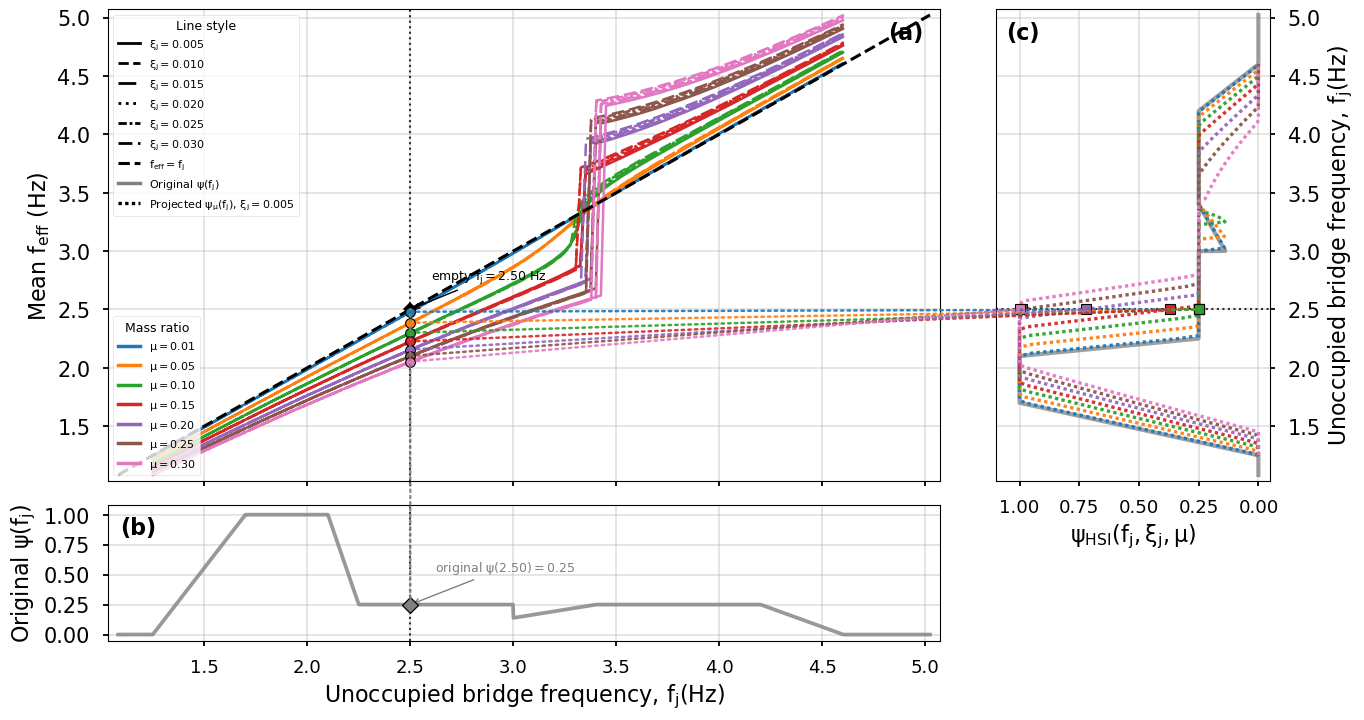


Mapping at empty frequency f0 = 2.50 Hz
---------------------------------------------------------
mu      f_eff(f0=2.50)      projected psi = psi(f_eff)
---------------------------------------------------------
0.01    2.480               0.250
0.05    2.386               0.250
0.10    2.300               0.250
0.15    2.226               0.370
0.20    2.156               0.720
0.25    2.102               0.990
0.30    2.053               1.000


In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch
plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'
# ==================================================
# LOAD SAVED NMFR RESULTS
# ==================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", pkl_file)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ==================================================
# DENSITY TO MASS RATIO LABEL
# ==================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ==================================================
# UPDATED ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# HELPER FUNCTION: COLLECT f0_peak AND f_eff_peak
# ==================================================

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(x_vals) == 0:
        return x_vals, y_vals

    order = np.argsort(x_vals)
    return x_vals[order], y_vals[order]


# ==================================================
# SETTINGS
# ==================================================

TARGET_F0 = 2.50
PROJECT_DAMPING = 0.005

line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (3, 1, 1, 1)),
    (0, (5, 2)),
]

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ==================================================
# FIGURE LAYOUT
# left top     : frequency shift, f0 vs f_eff
# left bottom  : original psi(f0)
# right top    : rotated projected psi, x = psi, y = f0
# right bottom : blank
# ==================================================
plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'
fig = plt.figure(figsize=(15, 8.2))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[5.0, 1.65],
    height_ratios=[4.7, 1.35],
    wspace=0.10,
    hspace=0.08
)

ax_main = fig.add_subplot(gs[0, 0])
ax_orig = fig.add_subplot(gs[1, 0], sharex=ax_main)

# right graph: y-axis is frequency and shares with ax_main
ax_proj = fig.add_subplot(gs[0, 1], sharey=ax_main)

ax_blank = fig.add_subplot(gs[1, 1])
ax_blank.axis("off")


# ==================================================
# MAIN PLOT: f0_peak vs f_eff_peak
# colour = mass ratio
# line style = damping ratio
# ==================================================

all_x = []
all_y = []

for density in densities:

    color = density_to_color[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        x_vals, y_vals = collect_f0_feff(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        if len(x_vals) == 0:
            continue

        all_x.extend(x_vals)
        all_y.extend(y_vals)

        ax_main.plot(
            x_vals,
            y_vals,
            color=color,
            linestyle=ls,
            linewidth=1.8,
            label="_nolegend_"
        )

all_x = np.asarray(all_x, dtype=float)
all_y = np.asarray(all_y, dtype=float)

lo = min(np.nanmin(all_x), np.nanmin(all_y))
hi = max(np.nanmax(all_x), np.nanmax(all_y))

# no-shift reference line
ax_main.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=2.2,
    color="black",
    label="_nolegend_"
)


# ==================================================
# BOTTOM LEFT: ORIGINAL psi(fj)
# ==================================================

f_grid = np.linspace(lo, hi, 1500)
psi_grid = psi_original(f_grid)

ax_orig.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=2.7,
    alpha=0.80,
    label=r"Original $\psi(f_j)$"
)

psi_at_target = float(psi_original(np.array([TARGET_F0]))[0])

ax_orig.plot(
    TARGET_F0,
    psi_at_target,
    marker="D",
    markersize=8,
    color="gray",
    markeredgecolor="black",
    markeredgewidth=0.9,
    zorder=20
)

ax_orig.axvline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)

ax_orig.annotate(
    fr"original $\psi({TARGET_F0:.2f})={psi_at_target:.2f}$",
    xy=(TARGET_F0, psi_at_target),
    xytext=(TARGET_F0 + 0.12, min(1.0, psi_at_target + 0.28)),
    fontsize=9,
    color="gray",
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.0)
)


# ==================================================
# RIGHT ROTATED PANEL:
# x = projected psi magnitude
# y = empty bridge frequency fj
#
# This is the 90-degree rotated version of:
# x = fj, y = projected psi
# ==================================================

# Original psi, rotated
ax_proj.plot(
    psi_grid,
    f_grid,
    color="gray",
    linestyle="-",
    linewidth=3.0,
    alpha=0.75,
    label=r"Original $\psi(f_j)$"
)

projected_curve_cache = {}

for density in densities:

    color = density_to_color[density]
    mu_val = mass_ratio_label.get(round(float(density), 4), density)

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    psi_projected = psi_original(feff_vals)

    projected_curve_cache[density] = {
        "x_vals": x_vals,
        "feff_vals": feff_vals,
        "psi_projected": psi_projected,
        "mu_val": mu_val
    }

    # Rotated projected curve:
    # x = psi_projected
    # y = f0
    ax_proj.plot(
        psi_projected,
        x_vals,
        color=color,
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        alpha=0.95,
        label="_nolegend_"
    )


# ==================================================
# SHOW THE MAPPING OF f0 = 2.50
#
# bottom original psi -> main f_eff point -> rotated right projected psi point
# ==================================================

main_ref_point = (TARGET_F0, TARGET_F0)

ax_main.plot(
    main_ref_point[0],
    main_ref_point[1],
    marker="D",
    markersize=7,
    color="black",
    markeredgecolor="black",
    zorder=20
)

ax_main.axvline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)

ax_main.annotate(
    fr"empty $f_j={TARGET_F0:.2f}$ Hz",
    xy=main_ref_point,
    xytext=(TARGET_F0 + 0.10, TARGET_F0 + 0.25),
    fontsize=9,
    color="black",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0)
)

# connect bottom original point -> main reference point
con_start = ConnectionPatch(
    xyA=(TARGET_F0, psi_at_target),
    coordsA=ax_orig.transData,
    xyB=main_ref_point,
    coordsB=ax_main.transData,
    axesA=ax_orig,
    axesB=ax_main,
    color="gray",
    linestyle=":",
    linewidth=1.7,
    alpha=0.90
)
fig.add_artist(con_start)


# Horizontal target line on rotated right panel:
# y = empty f0 = TARGET_F0
ax_proj.axhline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)


# For each mass ratio:
# read f_eff at f0 = TARGET_F0,
# compute psi(f_eff),
# plot on rotated right panel at y = TARGET_F0
mapping_rows = []

for density in densities:

    if density not in projected_curve_cache:
        continue

    color = density_to_color[density]
    mu_val = projected_curve_cache[density]["mu_val"]

    x_vals = projected_curve_cache[density]["x_vals"]
    feff_vals = projected_curve_cache[density]["feff_vals"]

    if TARGET_F0 < np.nanmin(x_vals) or TARGET_F0 > np.nanmax(x_vals):
        continue

    feff_now = np.interp(TARGET_F0, x_vals, feff_vals)
    psi_new_now = float(psi_original(np.array([feff_now]))[0])

    mapping_rows.append({
        "mu": mu_val,
        "fj": TARGET_F0,
        "feff": feff_now,
        "psi_projected": psi_new_now,
    })

    # point in main plot:
    # x = empty f0
    # y = coupled f_eff
    main_point = (TARGET_F0, feff_now)

    ax_main.plot(
        main_point[0],
        main_point[1],
        marker="o",
        markersize=7,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        zorder=25
    )

    # point in rotated right panel:
    # x = projected psi
    # y = empty f0
    proj_point = (psi_new_now, TARGET_F0)

    ax_proj.plot(
        proj_point[0],
        proj_point[1],
        marker="s",
        markersize=7,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        zorder=25
    )

    # connector from main frequency-shift point to rotated projected-psi point
    con_mid = ConnectionPatch(
        xyA=main_point,
        coordsA=ax_main.transData,
        xyB=proj_point,
        coordsB=ax_proj.transData,
        axesA=ax_main,
        axesB=ax_proj,
        color=color,
        linestyle=":",
        linewidth=1.8,
        alpha=0.90
    )
    fig.add_artist(con_mid)





# ==================================================
# LEGENDS
# ==================================================

# Mass ratio legend
color_handles = []

for density in densities:
    mu_val = mass_ratio_label.get(round(float(density), 4), density)
    color = density_to_color[density]

    color_handles.append(
        Line2D(
            [0], [0],
            color=color,
            linestyle="-",
            linewidth=2.5,
            label=fr"$\mu={mu_val:.2f}$"
        )
    )

legend1 = ax_main.legend(
    handles=color_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)
ax_main.add_artist(legend1)


# line-style legend
style_handles = []

for i, damp in enumerate(damping_values):
    style_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2.0,
            label=fr"$\xi_j={damp:.3f}$"
        )
    )

style_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.2,
        label=r"$f_{\mathrm{eff}}=f_j$"
    )
)

style_handles.append(
    Line2D(
        [0], [0],
        color="gray",
        linestyle="-",
        linewidth=2.5,
        label=r"Original $\psi(f_j)$"
    )
)

style_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        label=fr"Projected $\psi_\mu(f_j)$, $\xi_j={PROJECT_DAMPING:.3f}$"
    )
)

legend2 = ax_main.legend(
    handles=style_handles,
    title="Line style",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)


# ==================================================
# AXIS FORMATTING
# ==================================================

ax_main.set_ylabel(r"Mean $f_{\mathrm{eff}}$ (Hz)")
ax_main.grid(True, alpha=0.35)

ax_orig.set_xlabel(r"Unoccupied bridge frequency, $f_j$(Hz)")
ax_orig.set_ylabel(r"Original $\psi(f_j)$")
ax_orig.set_ylim(-0.05, 1.08)
ax_orig.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
ax_orig.grid(True, alpha=0.35)

# Rotated projected-psi panel formatting
ax_proj.set_xlabel(r"$\psi_{\mathrm{HSI}}(f_j,\xi_j,\mu)$")
ax_proj.set_ylabel(r"Unoccupied bridge frequency, $f_j$(Hz)")

# ==================================================
# IMPORTANT CHANGE:
# Flip right-side x-axis so 1 is left and 0 is right
# ==================================================

ax_proj.set_xlim(1.10, -0.05)
ax_proj.set_xticks([1.00, 0.75, 0.50, 0.25, 0.00])

ax_proj.grid(True, alpha=0.35)

# put y ticks on right side for projected panel
ax_proj.yaxis.tick_right()
ax_proj.yaxis.set_label_position("right")

# keep frequency range aligned between main y-axis and right-panel y-axis
ax_main.set_xlim(lo - 0.05, hi + 0.05)
ax_main.set_ylim(lo - 0.05, hi + 0.05)
ax_proj.set_ylim(ax_main.get_ylim())

# hide top-main x tick labels
plt.setp(ax_main.get_xticklabels(), visible=False)

# ==================================================
# SUBFIGURE LABELS
# ==================================================

ax_main.text(
    0.98, 0.975,
    "(a)",
    transform=ax_main.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="right"
)

ax_orig.text(
    0.015, 0.92,
    "(b)",
    transform=ax_orig.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_proj.text(
    0.04, 0.975,
    "(c)",
    transform=ax_proj.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)
plt.tight_layout()

plt.savefig(
    "fig_psi_mapping.pdf",
    bbox_inches="tight"
)

plt.show()


# ==================================================
# PRINT MAPPING TABLE AT fj = 2.50
# ==================================================

print("\nMapping at empty frequency f0 = {:.2f} Hz".format(TARGET_F0))
print("---------------------------------------------------------")
print("mu      f_eff(f0=2.50)      projected psi = psi(f_eff)")
print("---------------------------------------------------------")

for row in mapping_rows:
    print(
        f"{row['mu']:.2f}    "
        f"{row['feff']:.3f}               "
        f"{row['psi_projected']:.3f}"
    )

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


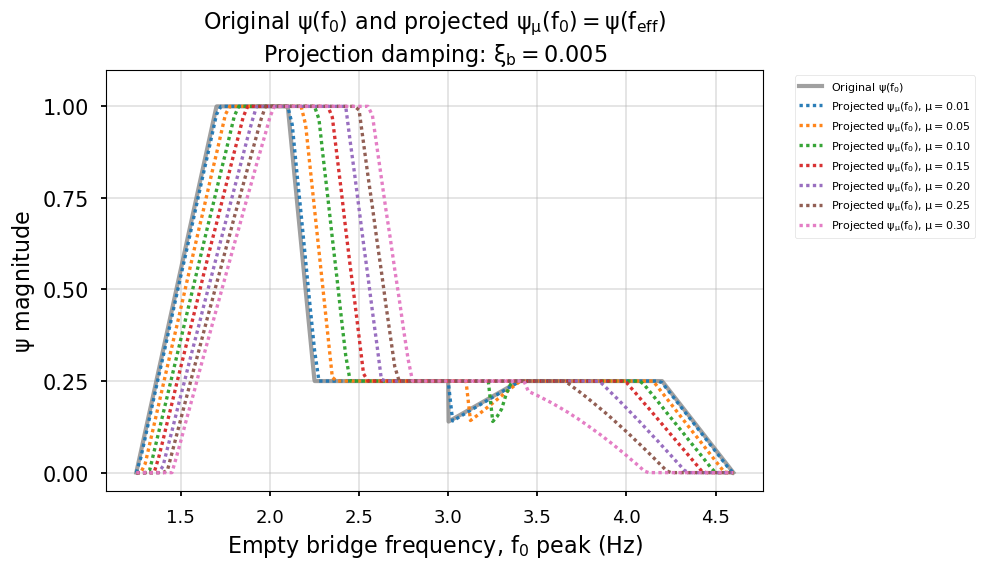

In [32]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# LOAD SAVED NMFR RESULTS
# ==================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", pkl_file)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ==================================================
# DENSITY TO MASS RATIO LABEL
# ==================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ==================================================
# UPDATED ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# HELPER FUNCTION: COLLECT f0_peak AND f_eff_peak
# ==================================================

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals)
    y_vals = np.asarray(y_vals)

    if len(x_vals) == 0:
        return x_vals, y_vals

    order = np.argsort(x_vals)
    return x_vals[order], y_vals[order]


# ==================================================
# SETTINGS
# ==================================================

PROJECT_DAMPING = 0.005

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ==================================================
# PLOT ORIGINAL PSI AND PROJECTED PSI ONLY
# ==================================================

fig, ax = plt.subplots(figsize=(10, 5.8))

# --------------------------------------------------
# Determine frequency range from projected data
# --------------------------------------------------

all_f0 = []

for density in densities:

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) > 0:
        all_f0.extend(x_vals)

all_f0 = np.asarray(all_f0, dtype=float)

lo = np.nanmin(all_f0)
hi = np.nanmax(all_f0)


# --------------------------------------------------
# Original psi:
# x = f0
# y = psi_original(f0)
# --------------------------------------------------

f_grid = np.linspace(lo, hi, 1500)
psi_grid = psi_original(f_grid)

ax.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=3.0,
    alpha=0.75,
    label=r"Original $\psi(f_0)$"
)


# --------------------------------------------------
# Projected psi:
# x = f0
# y = psi_original(f_eff(f0, mu, xi_b))
# --------------------------------------------------

for density in densities:

    color = density_to_color[density]
    mu_val = mass_ratio_label.get(round(float(density), 4), density)

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        print(f"No projected psi data for density={density}, damping={PROJECT_DAMPING}")
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    psi_projected = psi_original(feff_vals)

    ax.plot(
        x_vals,
        psi_projected,
        color=color,
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        alpha=0.95,
        label=fr"Projected $\psi_\mu(f_0)$, $\mu={mu_val:.2f}$"
    )


# ==================================================
# FORMATTING
# ==================================================

ax.set_xlabel(r"Empty bridge frequency, $f_0$ peak (Hz)")
ax.set_ylabel(r"$\psi$ magnitude")

ax.set_title(
    r"Original $\psi(f_0)$ and projected $\psi_\mu(f_0)=\psi(f_{\mathrm{eff}})$"
    "\n"
    fr"Projection damping: $\xi_b={PROJECT_DAMPING:.3f}$"
)

ax.set_ylim(-0.05, 1.10)
ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax.grid(True, alpha=0.35)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

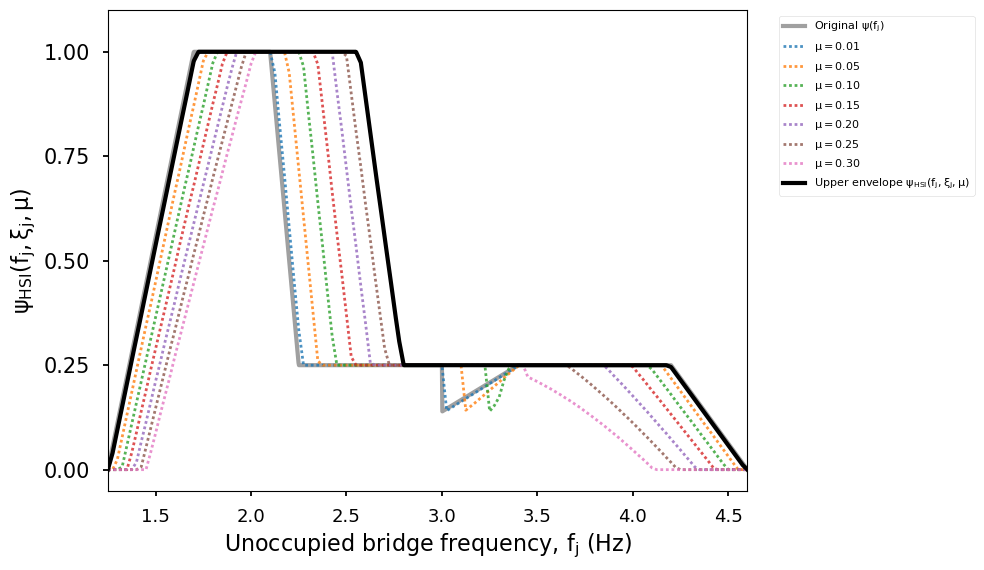

In [33]:
# ==================================================
# PLOT ORIGINAL PSI, PROJECTED PSI, AND UPPER ENVELOPE
# ==================================================
plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'

fig, ax = plt.subplots(figsize=(10, 5.8))


# --------------------------------------------------
# Determine frequency range from projected data
# --------------------------------------------------

all_f0 = []

for density in densities:

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) > 0:
        all_f0.extend(x_vals)

all_f0 = np.asarray(all_f0, dtype=float)

lo = np.nanmin(all_f0)
hi = np.nanmax(all_f0)


# --------------------------------------------------
# Common frequency grid
# --------------------------------------------------

f_grid = np.linspace(lo, hi, 1500)


# --------------------------------------------------
# Original psi
# --------------------------------------------------

psi_grid = psi_original(f_grid)

ax.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=3.0,
    alpha=0.75,
    label=r"Original $\psi(f_j)$"
)


# ==================================================
# PROJECTED PSI CURVES
# ==================================================

projected_curves = []

for density in densities:

    color = density_to_color[density]

    mu_val = mass_ratio_label.get(
        round(float(density), 4),
        density
    )

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        print(
            f"No projected psi data for "
            f"density={density}, "
            f"damping={PROJECT_DAMPING}"
        )
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    # Sort by unoccupied bridge frequency
    order = np.argsort(x_vals)

    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    # --------------------------------------------------
    # Deal with duplicate f_j values from overlapping bands
    # --------------------------------------------------

    unique_x = np.unique(x_vals)

    unique_feff = np.array([
        np.mean(feff_vals[np.isclose(x_vals, x)])
        for x in unique_x
    ])

    x_vals = unique_x
    feff_vals = unique_feff


    # --------------------------------------------------
    # Project psi using effective coupled-system frequency
    # --------------------------------------------------

    psi_projected = psi_original(feff_vals)


    # --------------------------------------------------
    # Plot individual projected curve
    # --------------------------------------------------

    ax.plot(
        x_vals,
        psi_projected,
        color=color,
        linestyle=(0, (1, 1)),
        linewidth=2.0,
        alpha=0.80,
        label=fr"$\mu={mu_val:.2f}$"
    )


    # --------------------------------------------------
    # Interpolate onto common grid for envelope
    # --------------------------------------------------

    psi_interp = np.full_like(
        f_grid,
        np.nan,
        dtype=float
    )

    valid_grid = (
        (f_grid >= np.min(x_vals))
        &
        (f_grid <= np.max(x_vals))
    )

    psi_interp[valid_grid] = np.interp(
        f_grid[valid_grid],
        x_vals,
        psi_projected
    )

    projected_curves.append(psi_interp)


# ==================================================
# CALCULATE UPPER ENVELOPE
# ==================================================

projected_curves = np.asarray(projected_curves)

psi_upper_envelope = np.nanmax(
    projected_curves,
    axis=0
)


# ==================================================
# PLOT UPPER ENVELOPE
# ==================================================

ax.plot(
    f_grid,
    psi_upper_envelope,
    color="black",
    linestyle="-",
    linewidth=3.0,
    label=r"Upper envelope $\psi_{\mathrm{HSI}}(f_j,\xi_j,\mu)$",
    zorder=20
)


# ==================================================
# FORMATTING
# ==================================================

ax.set_xlabel(
    r"Unoccupied bridge frequency, $f_j$ (Hz)"
)

ax.set_ylabel(
    r"$\psi_{\mathrm{HSI}}(f_j,\xi_j,\mu)$"
)



ax.set_xlim(lo, hi)

ax.set_ylim(-0.05, 1.10)

ax.set_yticks([
    0.00,
    0.25,
    0.50,
    0.75,
    1.00
])

#ax.grid(True, alpha=0.35)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "psi_projected_upper_envelope.pdf",
    bbox_inches="tight"
)

plt.show()

Mass ratios plotted: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]


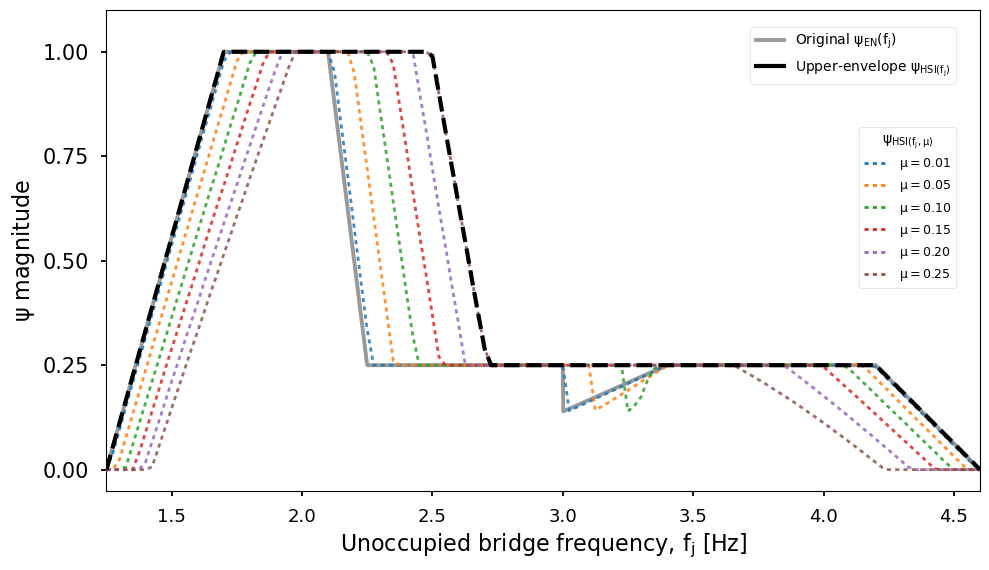

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# MASS RATIOS TO INCLUDE
# ============================================================

MU_TO_SHOW = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]


# ============================================================
# SELECT CORRESPONDING DENSITIES
# ============================================================

densities_to_plot = []

for density in densities:

    mu_val = mass_ratio_label.get(
        round(float(density), 4),
        density
    )

    if any(
        np.isclose(mu_val, mu)
        for mu in MU_TO_SHOW
    ):
        densities_to_plot.append(density)


print(
    "Mass ratios plotted:",
    [
        mass_ratio_label.get(
            round(float(d), 4),
            d
        )
        for d in densities_to_plot
    ]
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5.8)
)


# ============================================================
# DETERMINE FREQUENCY RANGE
# ============================================================

all_f0 = []

for density in densities_to_plot:

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) > 0:
        all_f0.extend(x_vals)


all_f0 = np.asarray(
    all_f0,
    dtype=float
)

lo = np.nanmin(all_f0)
hi = np.nanmax(all_f0)


# ============================================================
# COMMON FREQUENCY GRID
# ============================================================

f_grid = np.linspace(
    lo,
    hi,
    1500
)


# ============================================================
# ORIGINAL psi
# ============================================================

psi_grid = psi_original(
    f_grid
)

ax.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=2.8,
    alpha=0.80,
    zorder=5
)


# ============================================================
# PROJECTED psi CURVES
# ============================================================

projected_curves = []

mu_legend_handles = []


for density in densities_to_plot:

    color = density_to_color[
        density
    ]

    mu_val = mass_ratio_label.get(
        round(float(density), 4),
        density
    )


    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )


    if len(x_vals) == 0:

        print(
            f"No projected psi data for "
            f"density={density}, "
            f"damping={PROJECT_DAMPING}"
        )

        continue


    x_vals = np.asarray(
        x_vals,
        dtype=float
    )

    feff_vals = np.asarray(
        feff_vals,
        dtype=float
    )


    # --------------------------------------------------------
    # SORT
    # --------------------------------------------------------

    order = np.argsort(
        x_vals
    )

    x_vals = x_vals[
        order
    ]

    feff_vals = feff_vals[
        order
    ]


    # --------------------------------------------------------
    # REMOVE DUPLICATE f_j VALUES FROM OVERLAPPING BANDS
    # --------------------------------------------------------

    unique_x = np.unique(
        x_vals
    )

    unique_feff = np.array(
        [
            np.mean(
                feff_vals[
                    np.isclose(
                        x_vals,
                        x
                    )
                ]
            )
            for x in unique_x
        ]
    )

    x_vals = unique_x
    feff_vals = unique_feff


    # --------------------------------------------------------
    # PROJECTED psi
    # --------------------------------------------------------

    psi_projected = psi_original(
        feff_vals
    )


    # --------------------------------------------------------
    # PLOT INDIVIDUAL CURVE
    # --------------------------------------------------------

    ax.plot(
        x_vals,
        psi_projected,
        color=color,
        linestyle=(0, (1.5, 1.5)),
        linewidth=2.0,
        alpha=0.85,
        zorder=10
    )


    # --------------------------------------------------------
    # MASS-RATIO LEGEND HANDLE
    # --------------------------------------------------------

    mu_legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linestyle=(0, (1.5, 1.5)),
            linewidth=2.0,
            label=rf"$\mu={mu_val:.2f}$"
        )
    )


    # --------------------------------------------------------
    # INTERPOLATE FOR UPPER ENVELOPE
    # --------------------------------------------------------

    psi_interp = np.full_like(
        f_grid,
        np.nan,
        dtype=float
    )

    valid_grid = (
        (f_grid >= np.min(x_vals))
        &
        (f_grid <= np.max(x_vals))
    )

    psi_interp[
        valid_grid
    ] = np.interp(
        f_grid[valid_grid],
        x_vals,
        psi_projected
    )

    projected_curves.append(
        psi_interp
    )


# ============================================================
# UPPER ENVELOPE
#
# IMPORTANT:
# only mu = 0.05–0.25 contribute
# ============================================================

# ============================================================
# UPPER ENVELOPE
#
# Envelope considers:
#
#   1. Original code psi(f_j)
#   2. All projected HSI psi curves for mu = 0.05–0.25
#
# psi_env(f_j) =
# max[psi_original, psi_HSI(mu=0.05), ..., psi_HSI(mu=0.25)]
# ============================================================

projected_curves = np.asarray(
    projected_curves
)

# Add original code psi as another candidate curve
all_envelope_curves = np.vstack(
    [
        psi_grid[np.newaxis, :],
        projected_curves
    ]
)

psi_upper_envelope = np.nanmax(
    all_envelope_curves,
    axis=0
)

# ============================================================
# PLOT UPPER ENVELOPE
# ============================================================

ax.plot(
    f_grid,
    psi_upper_envelope,
    color="black",
    linestyle="--",
    linewidth=3.0,
    zorder=20
)


# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    r"Unoccupied bridge frequency, $f_j$ [Hz]"
)

ax.set_ylabel(
    r"$\psi$ magnitude"
)

ax.set_xlim(
    lo,
    hi
)

ax.set_ylim(
    -0.05,
    1.10
)

ax.set_yticks(
    [
        0.00,
        0.25,
        0.50,
        0.75,
        1.00
    ]
)

ax.grid(False)


# ============================================================
# LEGEND 1
# ORIGINAL + UPPER ENVELOPE
# INSIDE PLOT
# ============================================================

main_legend_handles = [

    Line2D(
        [0],
        [0],
        color="gray",
        linestyle="-",
        linewidth=2.8,
        alpha=0.80,
        label=r"Original $\psi_{EN}(f_j)$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="-",
        linewidth=3.0,
        label=r"Upper-envelope $\psi_{\mathrm{HSI}(f_j)}$"
    ),
]


legend_main = ax.legend(
    handles=main_legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    fontsize=10,
    frameon=True
)

ax.add_artist(
    legend_main
)


# ============================================================
# LEGEND 2
# MASS RATIOS
# INSIDE PLOT
# ============================================================

legend_mu = ax.legend(
    handles=mu_legend_handles,
    title=r"$\psi_{\mathrm{HSI}(f_j,\mu)}$",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.77),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    ncol=1
)





# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "psi_projected_upper_envelope.pdf",
    bbox_inches="tight"
)

plt.show()

In [35]:
# ==================================================
# QUANTIFY EFFECT OF UPPER-ENVELOPE SIMPLIFICATION
# ==================================================

print("\n" + "=" * 75)
print("EFFECT OF UPPER-ENVELOPE SIMPLIFICATION")
print("=" * 75)

delta_curves = []

for i, psi_individual in enumerate(projected_curves):

    valid = (
        np.isfinite(psi_individual)
        &
        np.isfinite(psi_upper_envelope)
    )

    if np.sum(valid) < 2:
        continue

    delta_psi = (
        psi_upper_envelope[valid]
        -
        psi_individual[valid]
    )

    f_valid = f_grid[valid]

    # --------------------------------------------------
    # Basic statistics
    # --------------------------------------------------

    mean_delta = np.mean(delta_psi)

    p95_delta = np.percentile(
        delta_psi,
        95
    )

    max_delta = np.max(delta_psi)

    min_delta = np.min(delta_psi)

    # --------------------------------------------------
    # Integrated penalty
    #
    # Integral(envelope - individual)
    # --------------------------------
    # Integral(individual)
    # --------------------------------------------------

    area_individual = np.trapz(
        psi_individual[valid],
        f_valid
    )

    area_excess = np.trapz(
        delta_psi,
        f_valid
    )

    if area_individual > 0:

        integrated_penalty = (
            area_excess
            /
            area_individual
            *
            100
        )

    else:

        integrated_penalty = np.nan

    # --------------------------------------------------
    # Recover corresponding mu label
    # --------------------------------------------------

    density = densities[i]

    mu_val = mass_ratio_label.get(
        round(float(density), 4),
        density
    )

    print(
        f"\nmu = {mu_val:.2f}"
    )

    print(
        f"  Mean Delta psi       = {mean_delta:.4f}"
    )

    print(
        f"  95th pct Delta psi   = {p95_delta:.4f}"
    )

    print(
        f"  Maximum Delta psi    = {max_delta:.4f}"
    )

    print(
        f"  Minimum Delta psi    = {min_delta:.6f}"
    )

    print(
        f"  Integrated penalty   = "
        f"{integrated_penalty:.2f}%"
    )

    delta_full = np.full_like(
        f_grid,
        np.nan,
        dtype=float
    )

    delta_full[valid] = delta_psi

    delta_curves.append(
        (
            mu_val,
            delta_full,
            density_to_color[density]
        )
    )


EFFECT OF UPPER-ENVELOPE SIMPLIFICATION

mu = 0.01
  Mean Delta psi       = 0.1159
  95th pct Delta psi   = 0.7500
  Maximum Delta psi    = 0.7500
  Minimum Delta psi    = 0.000000
  Integrated penalty   = 31.43%

mu = 0.05
  Mean Delta psi       = 0.1118
  95th pct Delta psi   = 0.7500
  Maximum Delta psi    = 0.7500
  Minimum Delta psi    = 0.000000
  Integrated penalty   = 29.98%

mu = 0.10
  Mean Delta psi       = 0.1079
  95th pct Delta psi   = 0.6711
  Maximum Delta psi    = 0.7500
  Minimum Delta psi    = 0.000000
  Integrated penalty   = 28.64%

mu = 0.15
  Mean Delta psi       = 0.1053
  95th pct Delta psi   = 0.5114
  Maximum Delta psi    = 0.7493
  Minimum Delta psi    = 0.000000
  Integrated penalty   = 27.75%

mu = 0.20
  Mean Delta psi       = 0.1072
  95th pct Delta psi   = 0.3839
  Maximum Delta psi    = 0.5498
  Minimum Delta psi    = 0.000000
  Integrated penalty   = 28.41%

mu = 0.25
  Mean Delta psi       = 0.1116
  95th pct Delta psi   = 0.4137
  Maximum Delta psi

C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\440499081.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_individual = np.trapz(
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\440499081.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_excess = np.trapz(


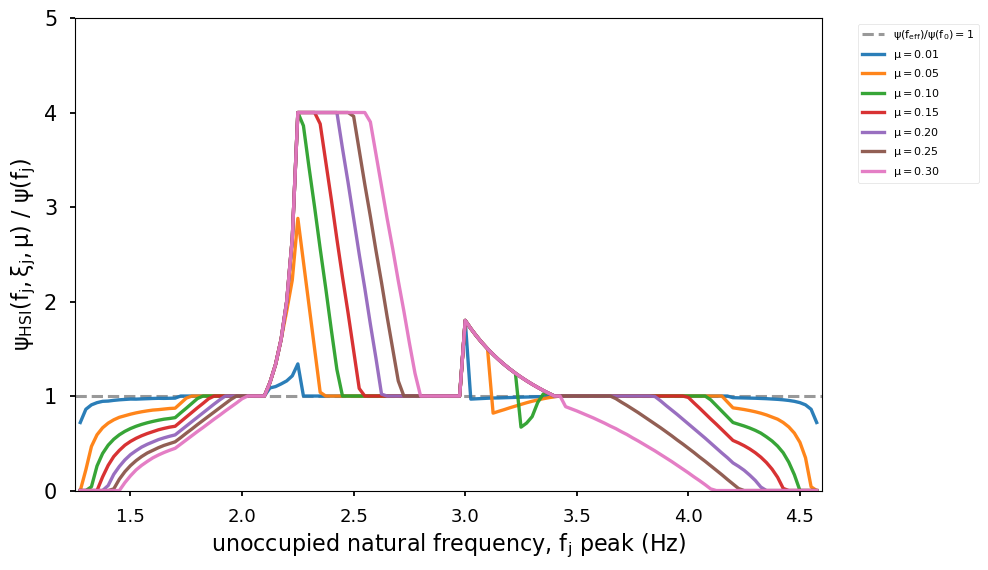

In [6]:
# ==================================================
# PLOT RATIO:
# projected psi / original psi
#
# ratio = psi(f_eff) / psi(f0)
# ==================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'
fig, ax = plt.subplots(figsize=(10, 5.8))

# --------------------------------------------------
# Determine frequency range from projected data
# --------------------------------------------------

all_f0 = []

for density in densities:

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) > 0:
        all_f0.extend(x_vals)

all_f0 = np.asarray(all_f0, dtype=float)

lo = np.nanmin(all_f0)
hi = np.nanmax(all_f0)


# --------------------------------------------------
# Reference line: ratio = 1
# --------------------------------------------------

ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=2.2,
    alpha=0.8,
    label=r"$\psi(f_{\mathrm{eff}})/\psi(f_0)=1$"
)


# --------------------------------------------------
# Ratio:
# x = f0
# y = psi_original(f_eff) / psi_original(f0)
# --------------------------------------------------

for density in densities:

    color = density_to_color[density]
    mu_val = mass_ratio_label.get(round(float(density), 4), density)

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        print(f"No projected psi data for density={density}, damping={PROJECT_DAMPING}")
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    # numerator: new/projected psi
    psi_new = psi_original(feff_vals)

    # denominator: original psi at empty bridge frequency
    psi_old = psi_original(x_vals)

    # Avoid division by zero
    ratio = np.full_like(psi_new, np.nan, dtype=float)

    valid = (
        np.isfinite(psi_new) &
        np.isfinite(psi_old) &
        (psi_old > 1e-12)
    )

    ratio[valid] = psi_new[valid] / psi_old[valid]

    ax.plot(
        x_vals,
        ratio,
        color=color,
        linestyle="-",
        linewidth=2.4,
        alpha=0.95,
        label=fr"$\mu={mu_val:.2f}$"
    )


# ==================================================
# FORMATTING
# ==================================================

ax.set_xlabel(r"unoccupied natural frequency, $f_j$ peak (Hz)")
ax.set_ylabel(r"$\psi_{\mathrm{HSI}}(f_j,\xi_j,\mu)$ / $\psi(f_j)$")



ax.set_xlim(lo, hi)

# You can adjust this depending on how large the ratios become
ax.set_ylim(0.0, 5.0)

#ax.grid(True, alpha=0.35)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.savefig(
    "fig_psi_old_vs_psi_new.pdf",
    bbox_inches="tight"
)
plt.show()

Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

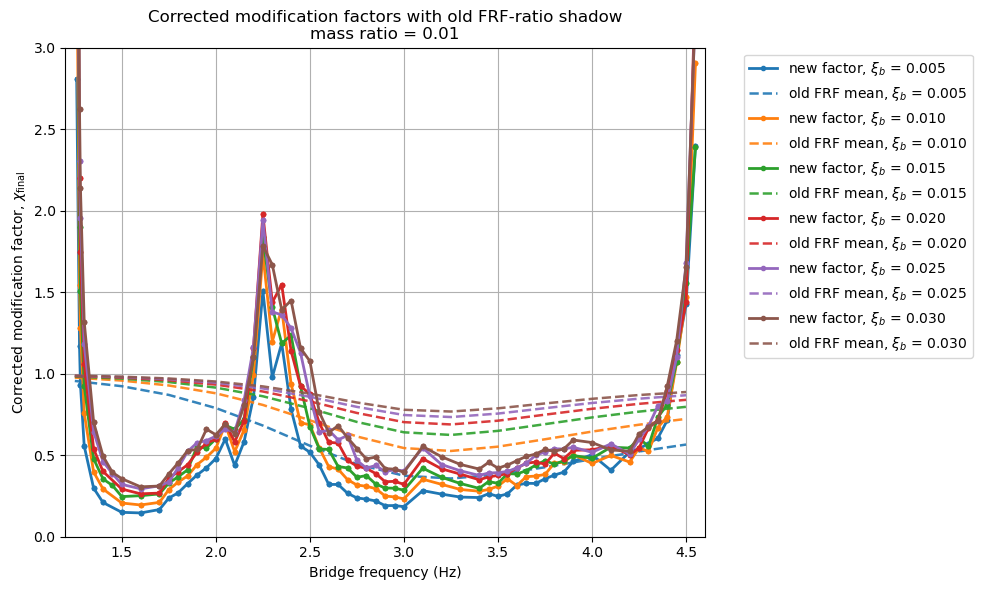

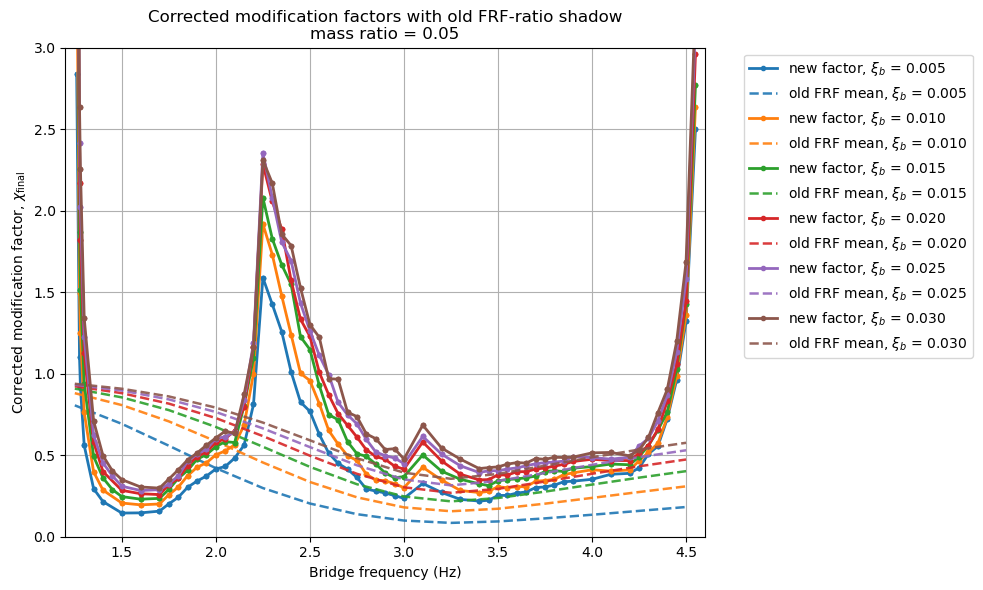

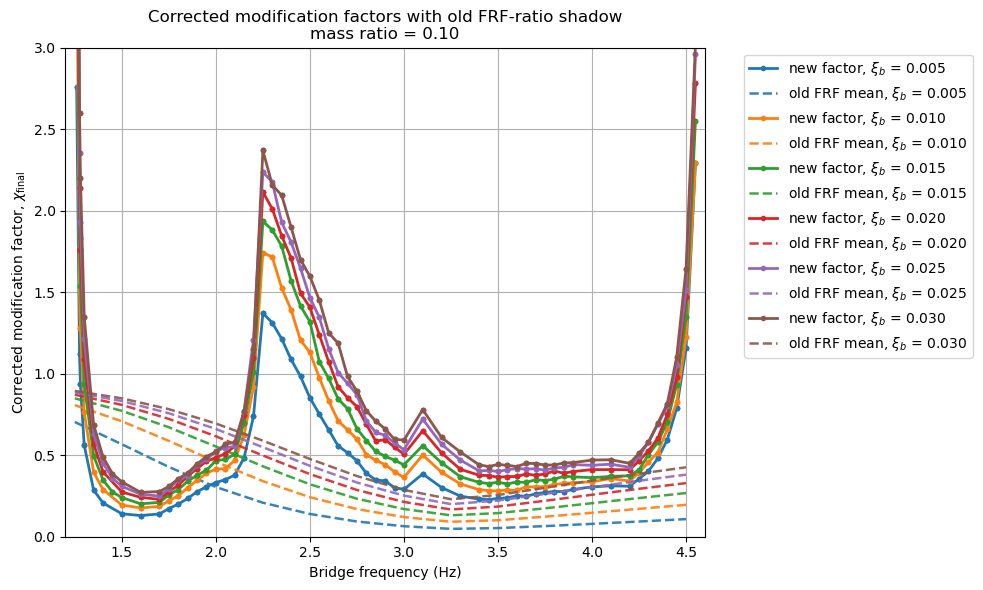

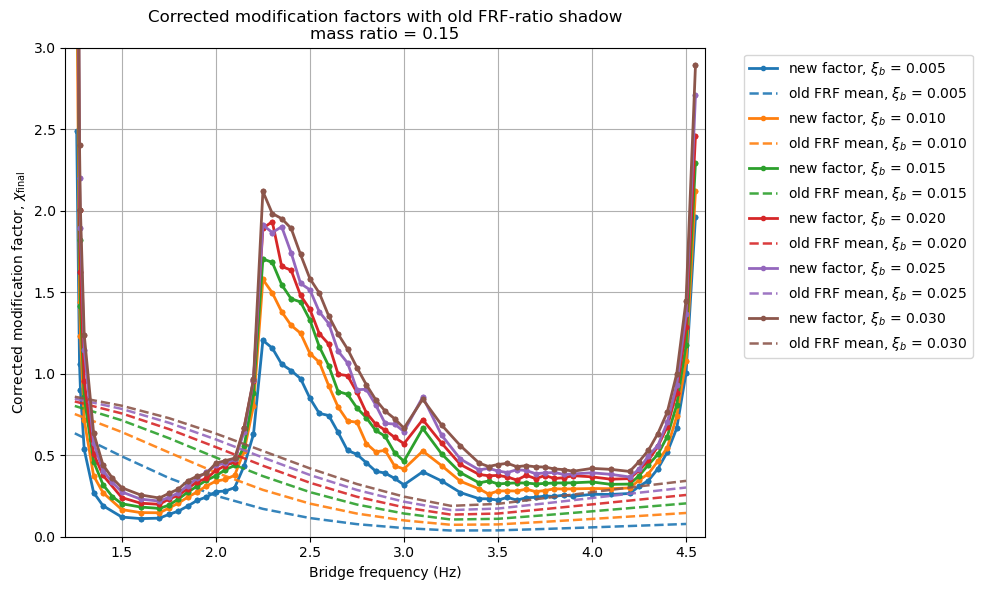

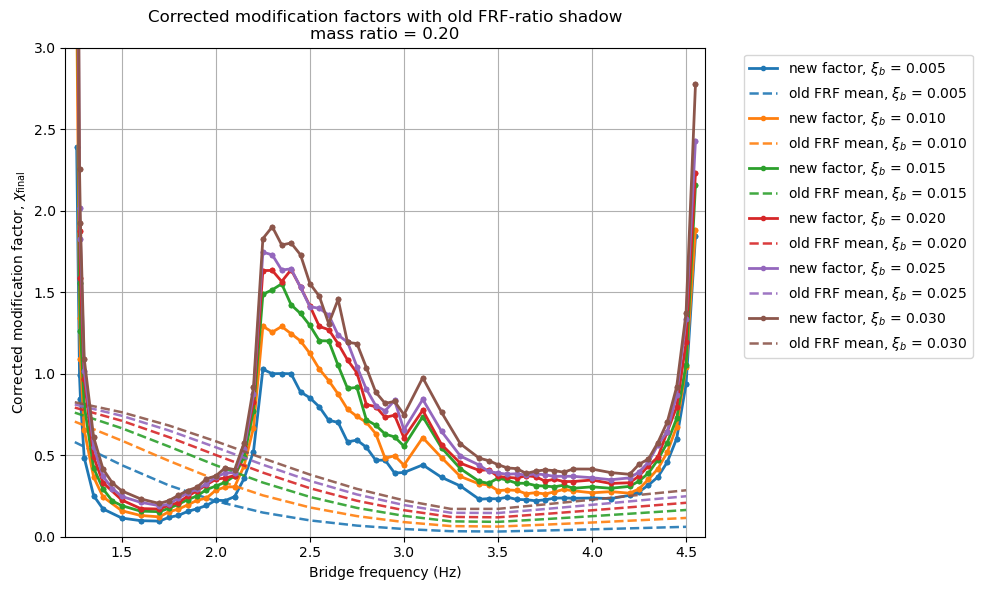

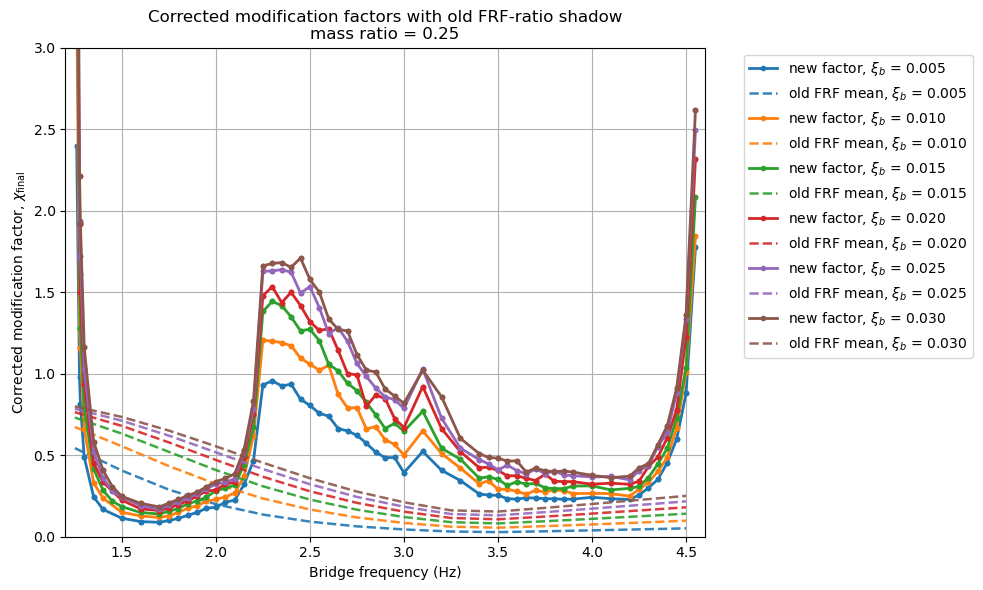

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

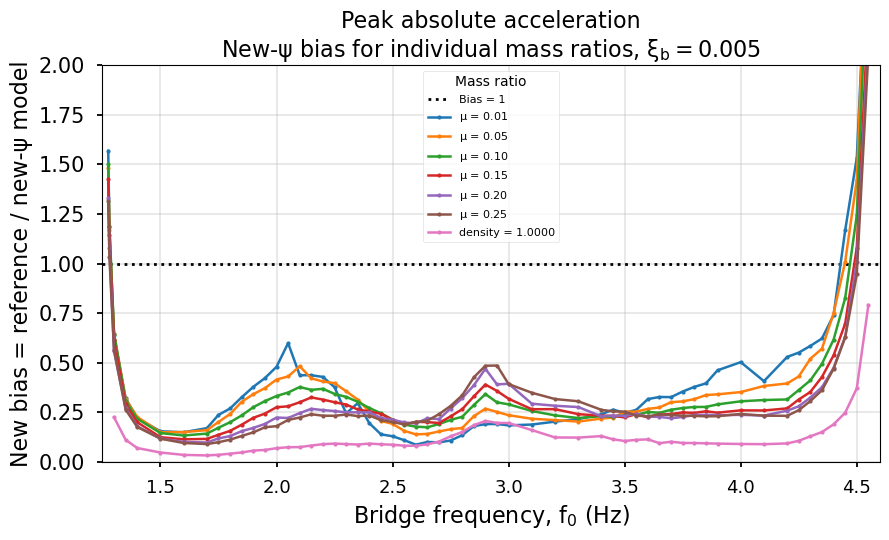

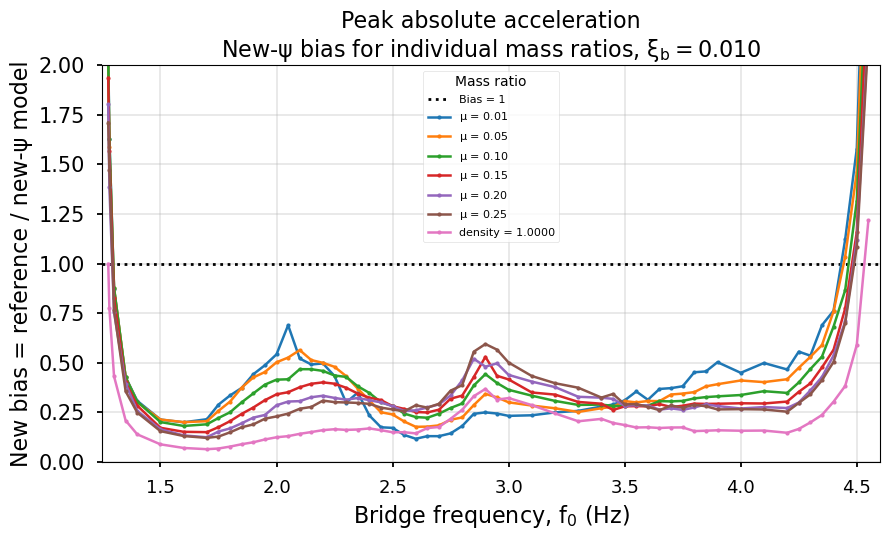

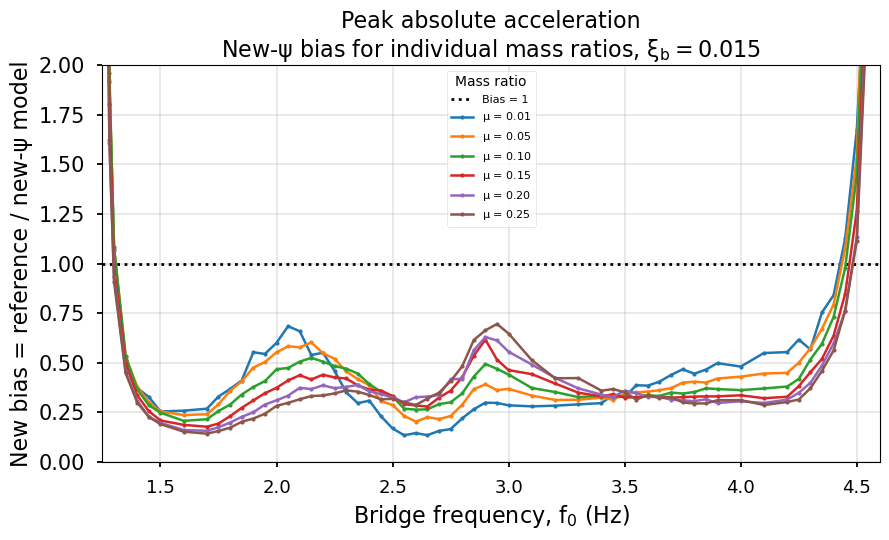

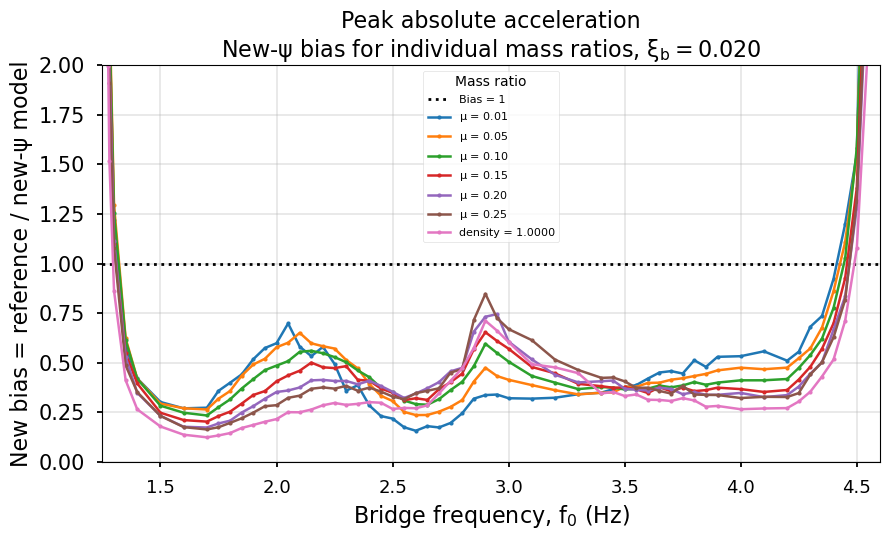

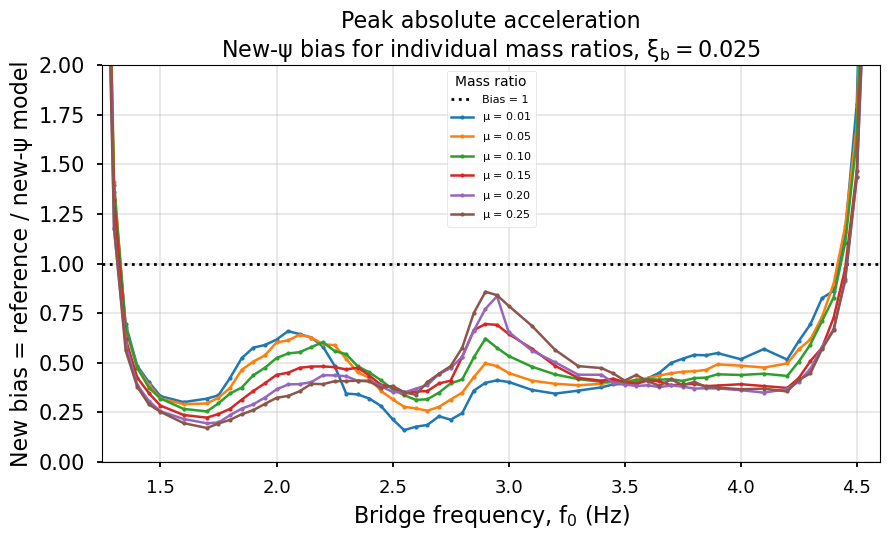

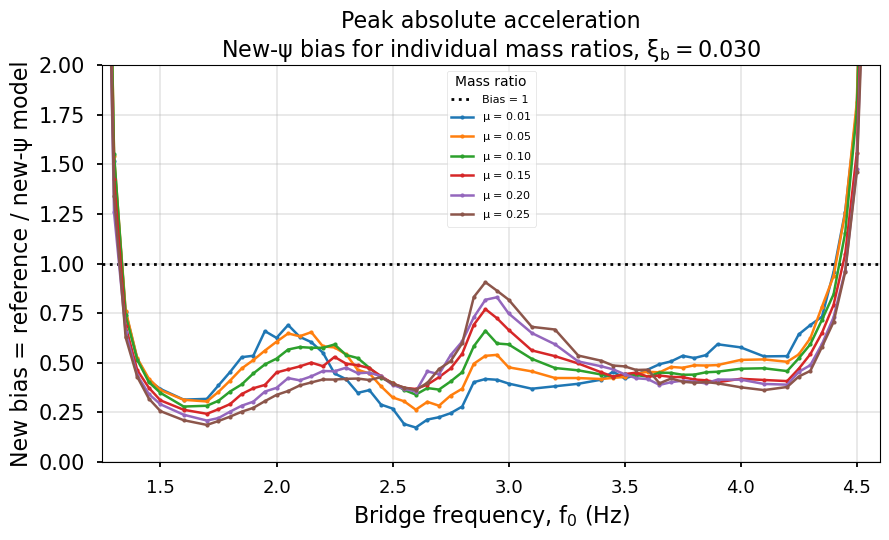

In [8]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.6

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.25, 4.6)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)

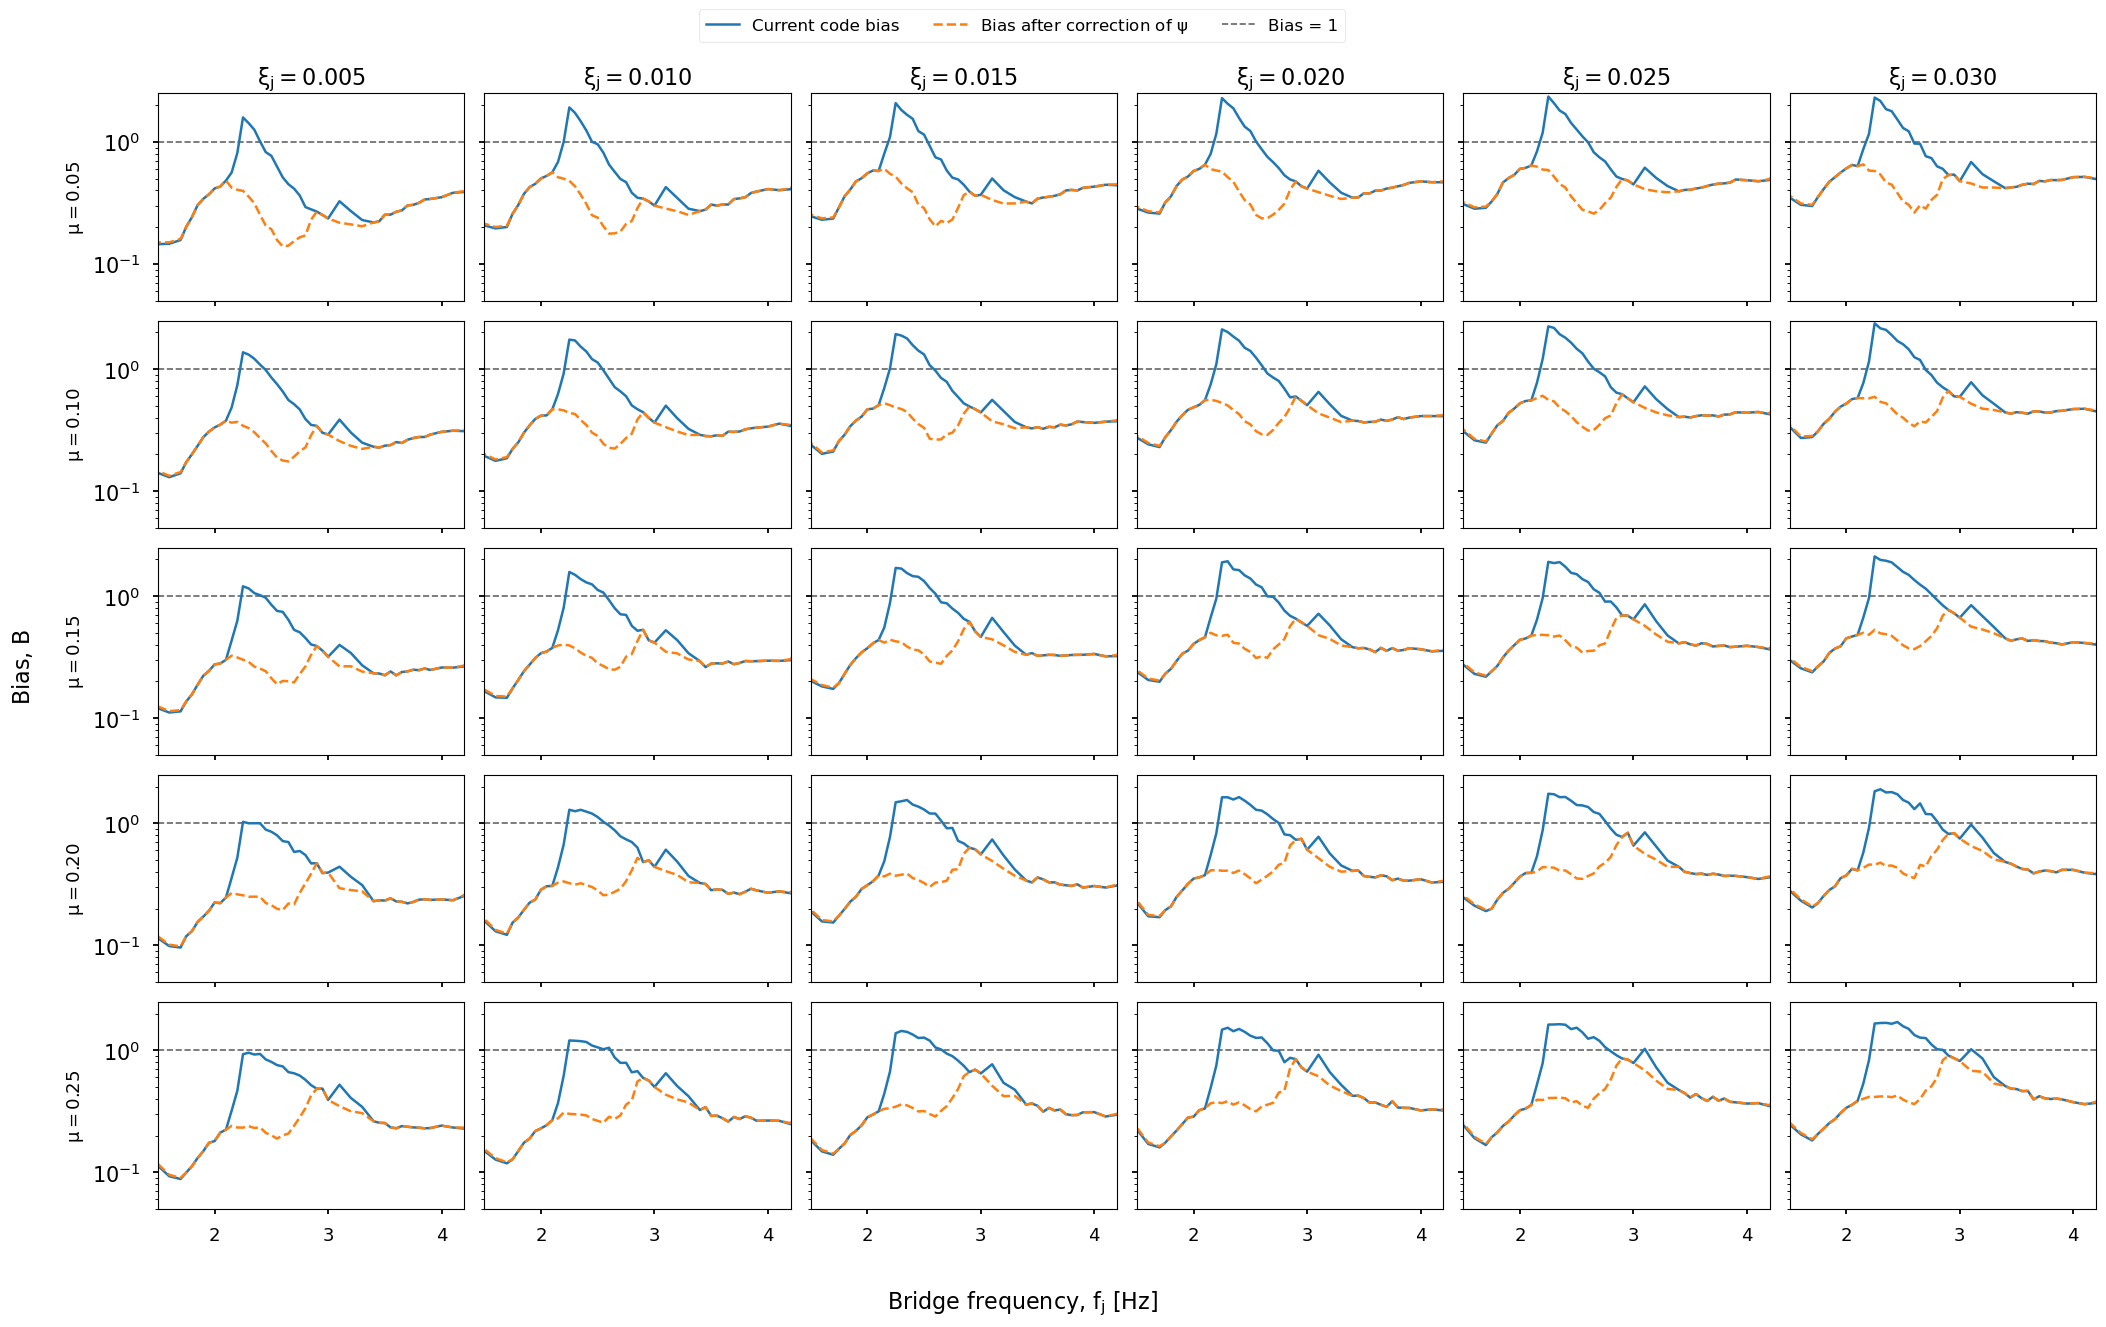

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 1. COPY CURRENT DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 2. SELECT PEAK ABSOLUTE ACCELERATION
# ============================================================

plot_df = comparison_df[
    comparison_df["measure"].astype(str).str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# ============================================================
# 3. MASS RATIOS + DAMPING RATIOS TO PLOT
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]


# ============================================================
# 4. PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_NEW_PSI = "C1"


# ============================================================
# 5. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 6. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]


        # ----------------------------------------------------
        # SELECT DATA
        # ----------------------------------------------------

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                damping
            )
        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # BIAS = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        # ----------------------------------------------------
        # PLOT CURVES
        # ----------------------------------------------------

        if not sub.empty:

            # ------------------------------------------------
            # ORIGINAL CODE BIAS
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                linewidth=1.8,
                linestyle="-",
                color=COLOR_CODE,
                label="Current code bias"
            )


            # ------------------------------------------------
            # BIAS AFTER CORRECTION OF psi
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_NEW_PSI,
                label=r"Bias after correction of $\psi$"
            )


        # ----------------------------------------------------
        # COLUMN TITLE = DAMPING RATIO xi_j
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
                rf"$\xi_j={damping:.3f}$"
            )


        # ----------------------------------------------------
        # ROW LABEL = MASS RATIO
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$",
                fontsize=13
            )


        # ----------------------------------------------------
        # AXIS FORMAT
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            2.5
        )


        # ----------------------------------------------------
        # GRID
        # ----------------------------------------------------

        #ax.grid(
        #    True,
        #    which="both",
        #    alpha=0.20
        #)


# ============================================================
# 7. COMMON X AND Y AXIS LABELS
# ============================================================

fig.supxlabel(
    r"Bridge frequency, $f_j$ [Hz]",
    fontsize=16,
    y=0.035
)

fig.supylabel(
    r"Bias, $B$",
    fontsize=16,
    x=0.04
)


# ============================================================
# 8. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.8,
        linestyle="-",
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after correction of $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
    frameon=True
)


# ============================================================
# 9. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.04,
        0.045,
        0.995,
        0.94
    ]
)


# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "bias_original_vs_corrected_psi.pdf",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

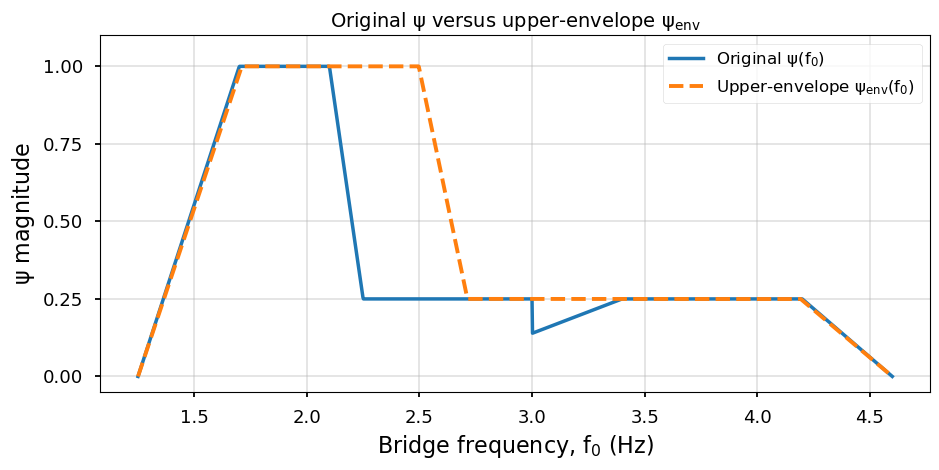

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm580_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_su

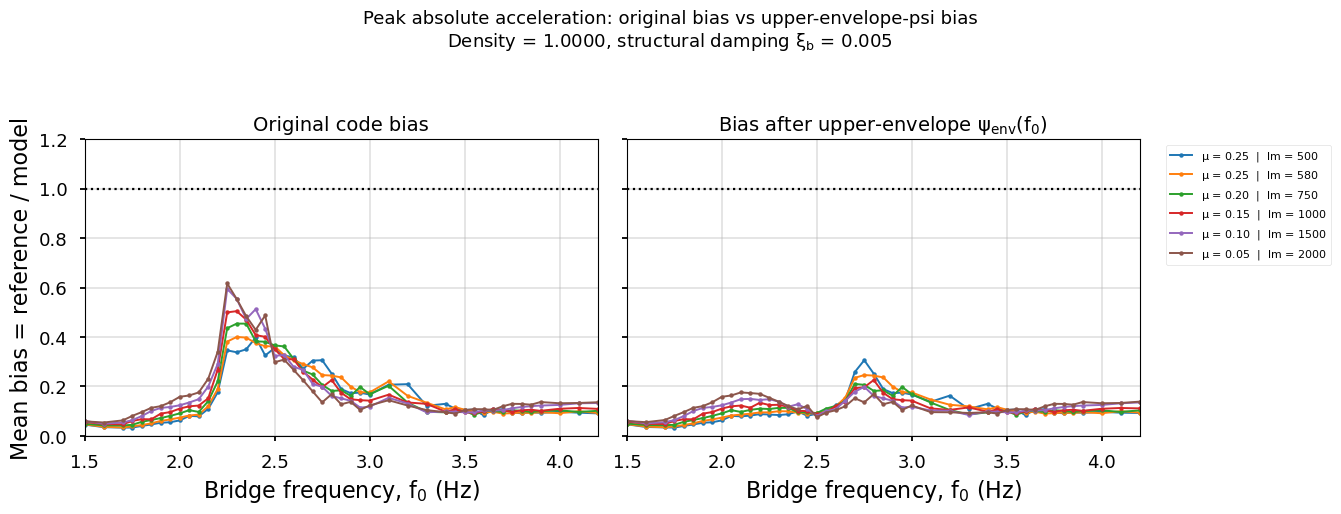

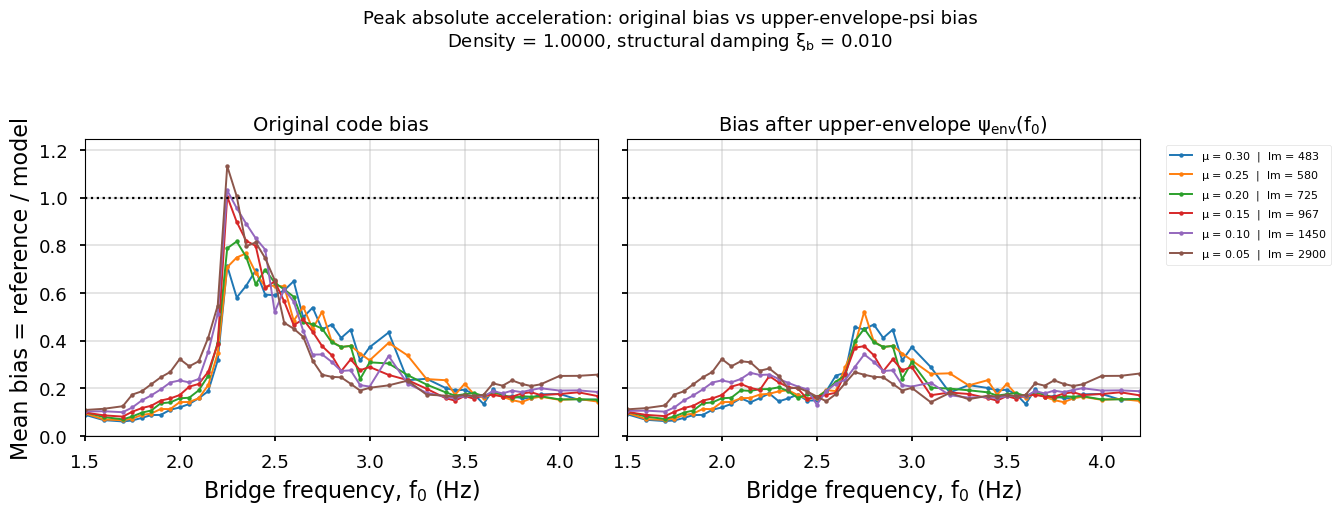

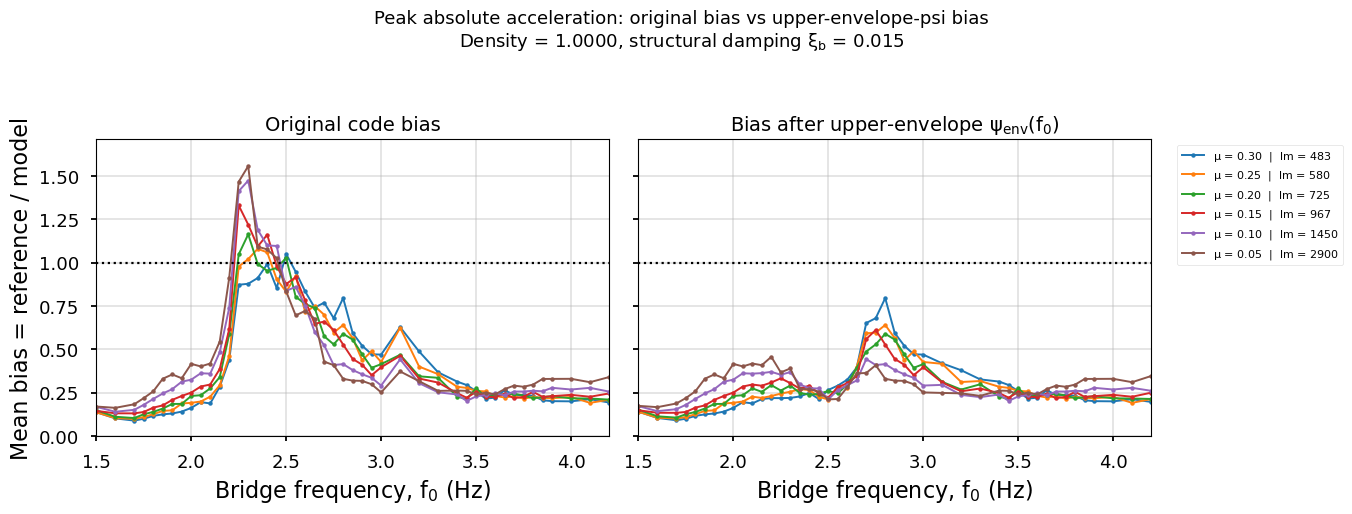

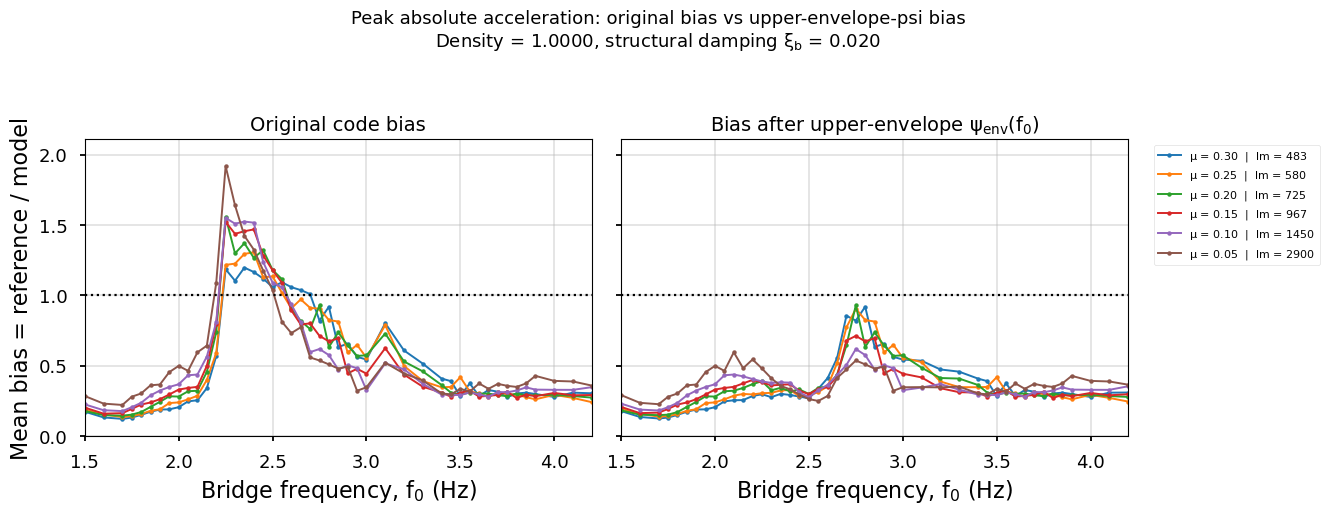

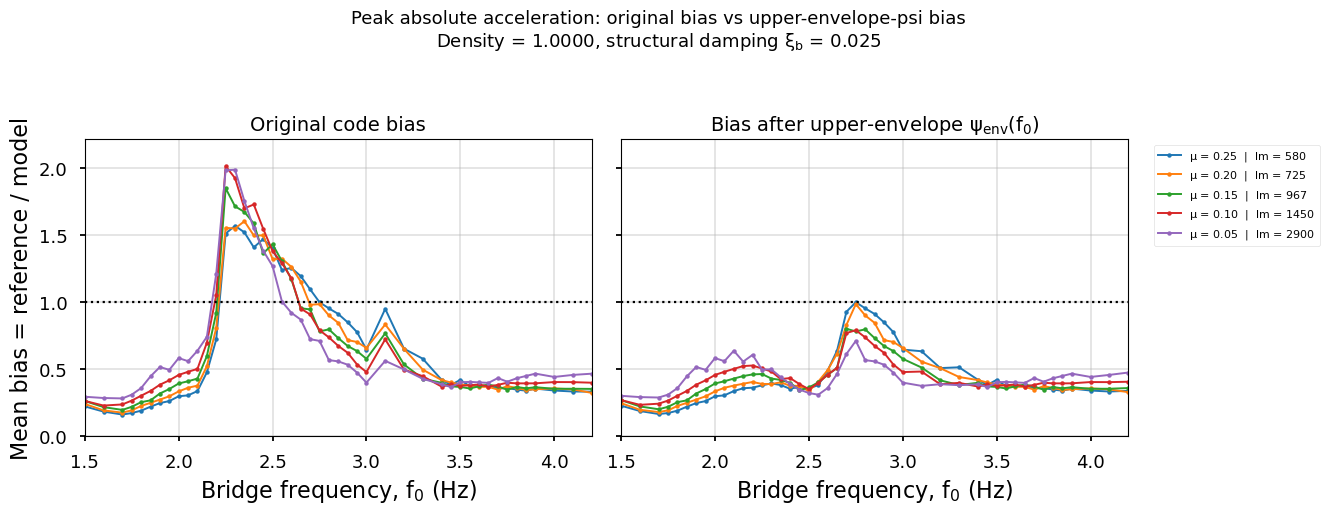

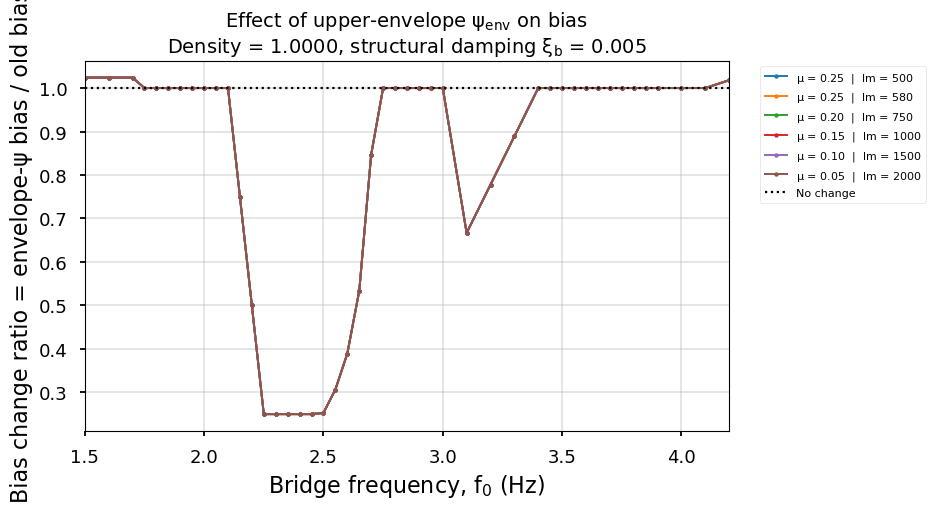

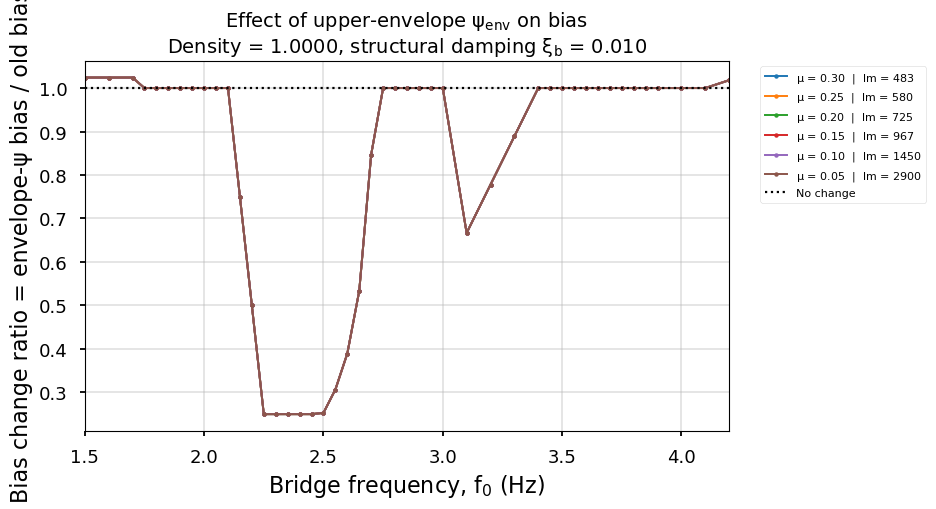

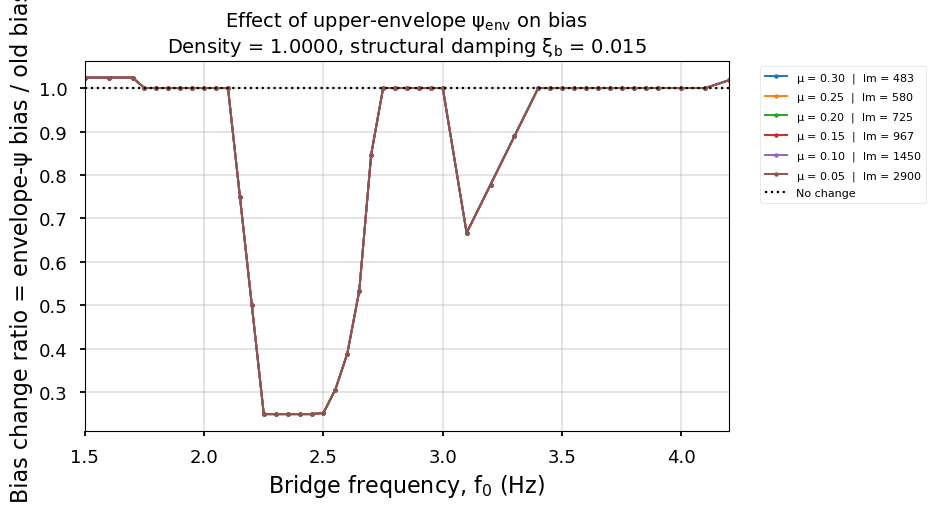

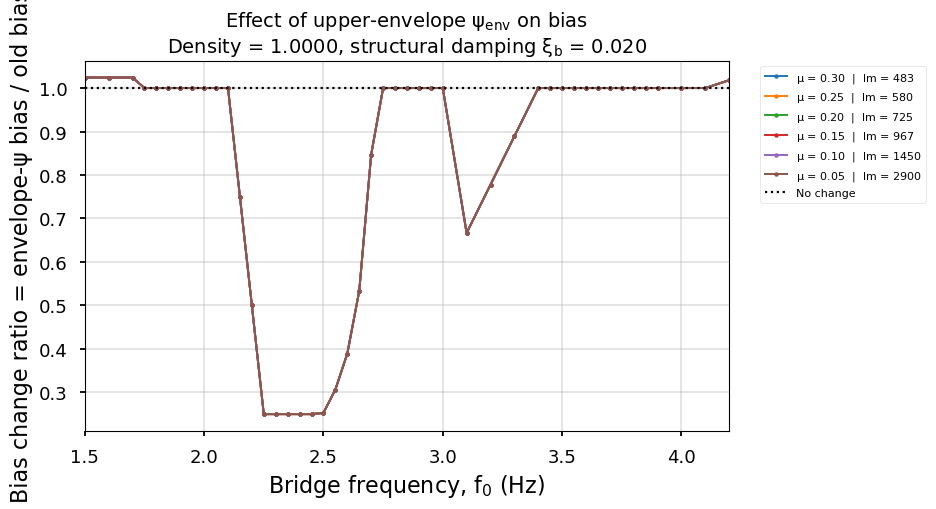

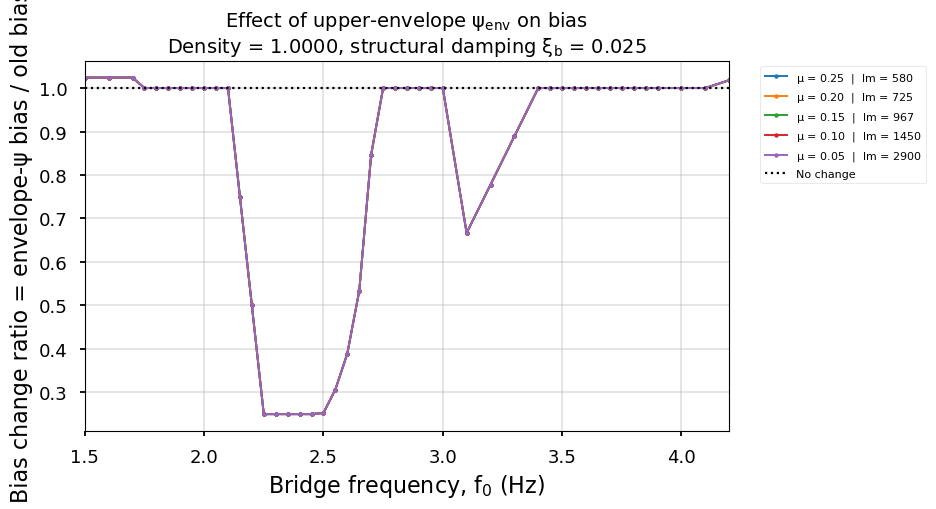


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.25       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              580        0.25       0.164763       0.109441      0.400200      0.246178                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0

In [88]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,
    500:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")

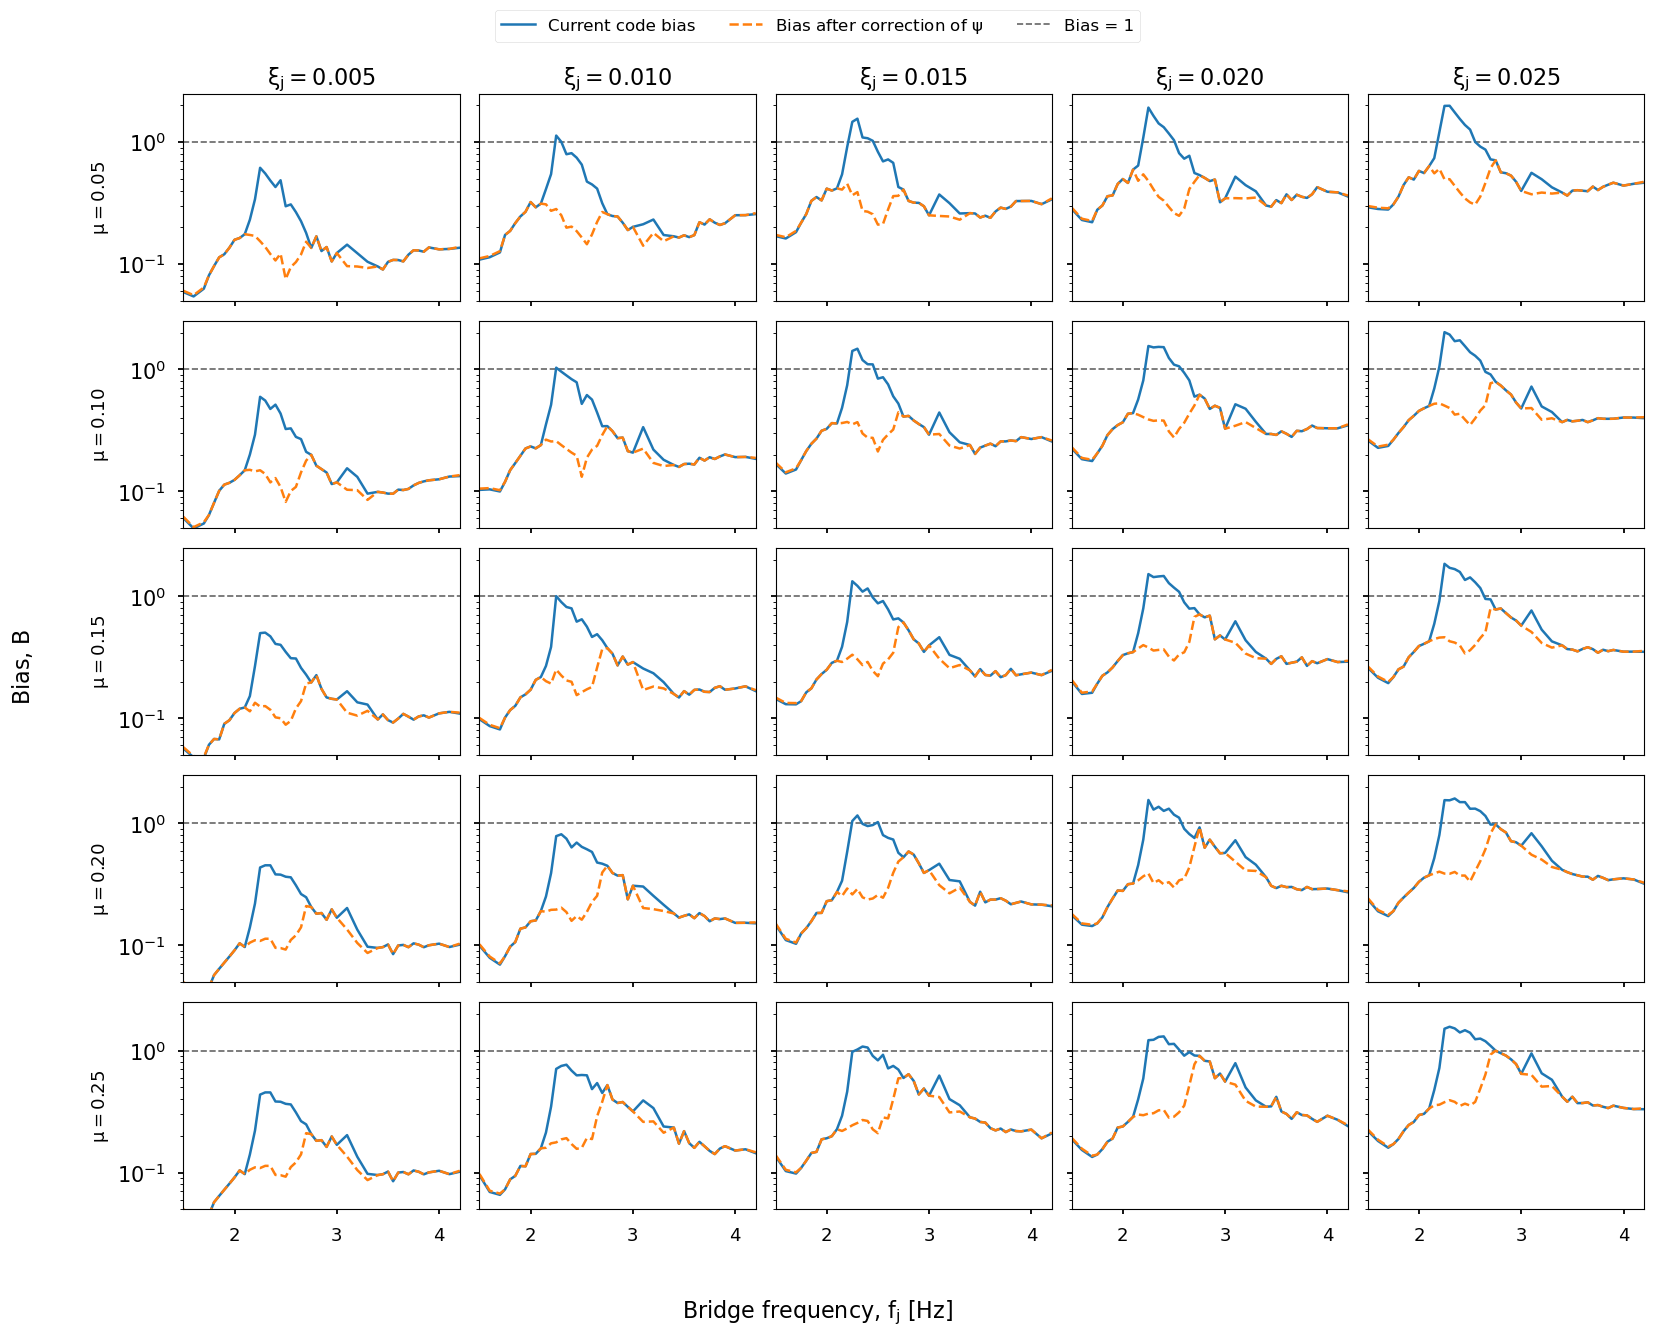

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 1. COPY CURRENT SECOND-LOAD-MODEL DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df does not exist.\n"
        "Run the first second-load-model code first."
    )


comparison_df = compare_df.copy()


# ============================================================
# 2. CREATE STANDARD DAMPING COLUMN
# ============================================================

comparison_df["target_beamdamp"] = pd.to_numeric(
    comparison_df["damping_key"],
    errors="coerce"
)


# ============================================================
# 3. FREQUENCY RANGE
# ============================================================

PLOT_FMIN_SECOND = 1.50
PLOT_FMAX_SECOND = 4.20

plot_df = comparison_df[
    (comparison_df["bridge_frequency"] >= PLOT_FMIN_SECOND)
    &
    (comparison_df["bridge_frequency"] <= PLOT_FMAX_SECOND)
].copy()


# ============================================================
# 4. MASS RATIOS
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    
]


# ============================================================
# 5. DAMPING RATIOS
# ============================================================

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    
]


# ============================================================
# 6. COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_NEW_PSI = "C1"


# ============================================================
# 7. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 8. SPECIAL REPEATED CURVES
#
# Repeat mu = 0.20, xi = 0.005 data in:
#
#     mu = 0.25, xi = 0.005
#     mu = 0.30, xi = 0.005
# ============================================================

REPEAT_SOURCE_MU = 0.20

REPEAT_TARGETS = [
    (0.25, 0.005),
    (0.30, 0.005),
]


# ============================================================
# 9. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]

        # ====================================================
        # DETERMINE SOURCE DATA
        # ====================================================

        is_repeat_panel = any(
            np.isclose(mass_ratio, target_mu)
            and
            np.isclose(damping, target_xi)
            for target_mu, target_xi in REPEAT_TARGETS
        )

        if is_repeat_panel:
            source_mass_ratio = REPEAT_SOURCE_MU
            source_damping = 0.005
        else:
            source_mass_ratio = mass_ratio
            source_damping = damping


        # ====================================================
        # SELECT DATA
        # ====================================================

        sub = plot_df[
            np.isclose(plot_df["mass_ratio"], source_mass_ratio)
            &
            np.isclose(plot_df["target_beamdamp"], source_damping)
        ].copy()

        sub = sub.sort_values("bridge_frequency")


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        # ====================================================
        # PLOT CURVES
        # ====================================================

        if not sub.empty:

            # ORIGINAL CODE BIAS
            ax.plot(
                sub["bridge_frequency"],
                sub["old_bias"],
                linewidth=1.8,
                linestyle="-",
                color=COLOR_CODE,
                label="Current code bias"
            )

            # BIAS AFTER NEW psi
            ax.plot(
                sub["bridge_frequency"],
                sub["env_bias"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_NEW_PSI,
                label=r"Bias after correction of $\psi$"
            )


        # ====================================================
        # COLUMN TITLE = xi_j
        # ====================================================

        if row == 0:
            ax.set_title(
                rf"$\xi_j={damping:.3f}$"
            )


        # ====================================================
        # ROW LABEL = mu
        # ====================================================

        if col == 0:
            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$",
                fontsize=13
            )


        # ====================================================
        # AXES
        # ====================================================

        ax.set_xlim(1.50, 4.20)
        ax.set_yscale("log")
        ax.set_ylim(0.05, 2.5)

        # No grid
        ax.grid(False)


# ============================================================
# 10. COMMON X AND Y AXIS LABELS
# ============================================================

fig.supxlabel(
    r"Bridge frequency, $f_j$ [Hz]",
    fontsize=16,
    y=0.028
)

fig.supylabel(
    r"Bias, $B$",
    fontsize=16,
    x=0.025
)


# ============================================================
# 11. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.8,
        linestyle="-",
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after correction of $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
    frameon=True
)


# ============================================================
# 12. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.04,
        0.045,
        0.995,
        0.94
    ]
)


# ============================================================
# 13. SAVE
# ============================================================

plt.savefig(
    "second_load_model_bias_original_vs_corrected_psi.pdf",
    bbox_inches="tight"
)

plt.show()

C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mean"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mean"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mean"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mean"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mean"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:543: RuntimeWarning: divide by zero encountered in divide
  sub["code_bias_mea

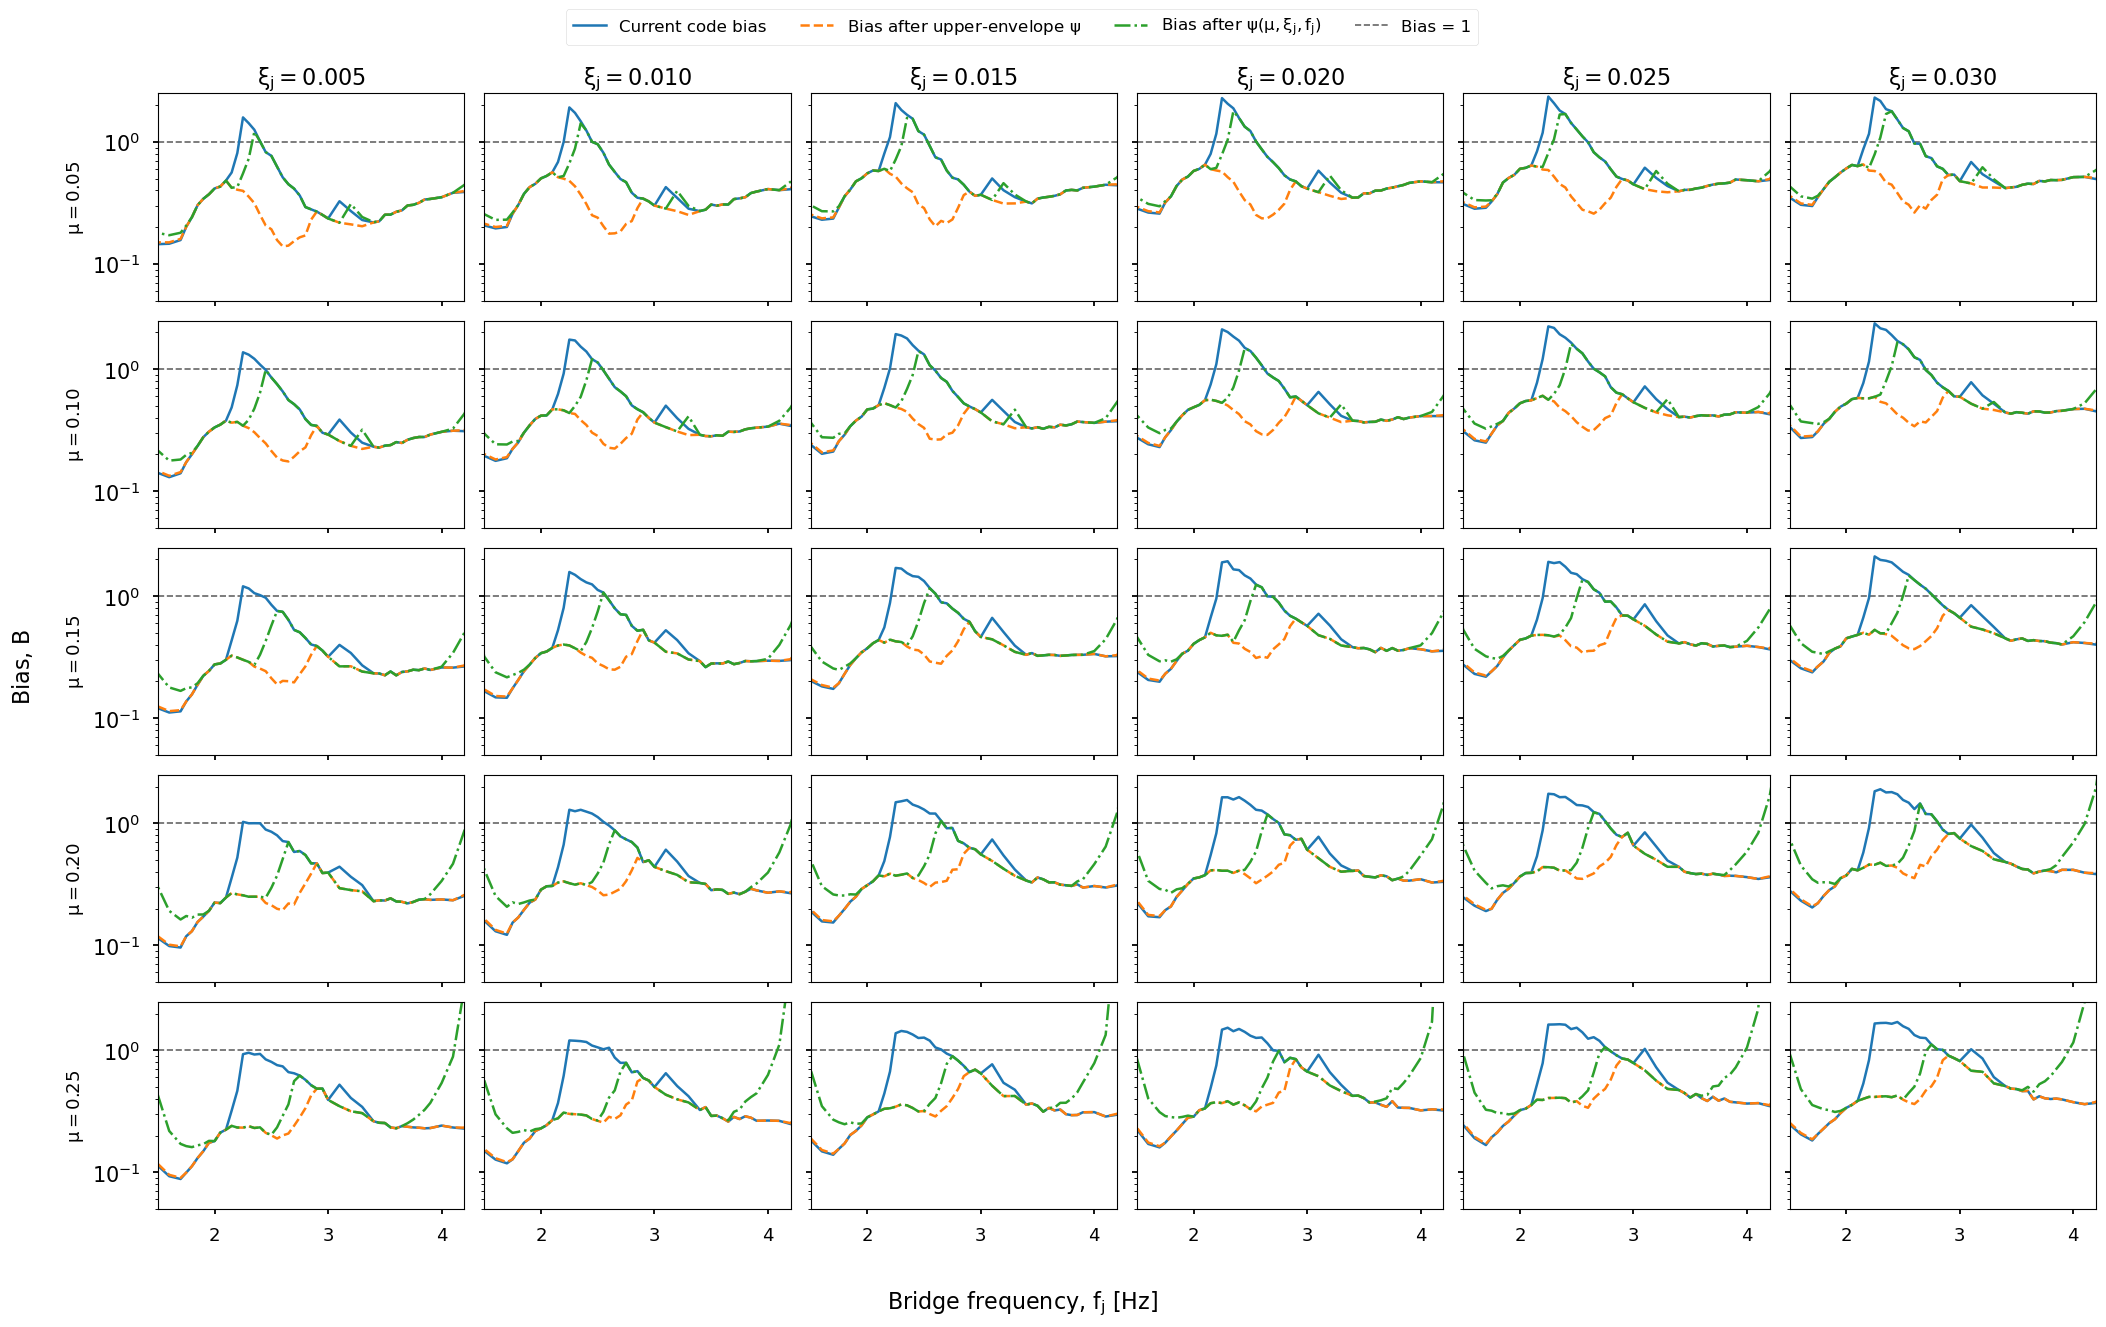

C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:932: RuntimeWarning: divide by zero encountered in divide
  sub["old_bias"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:932: RuntimeWarning: divide by zero encountered in divide
  sub["old_bias"].to_numpy(dtype=float)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_26372\2899322669.py:932: RuntimeWarning: divide by zero encountered in divide
  sub["old_bias"].to_numpy(dtype=float)


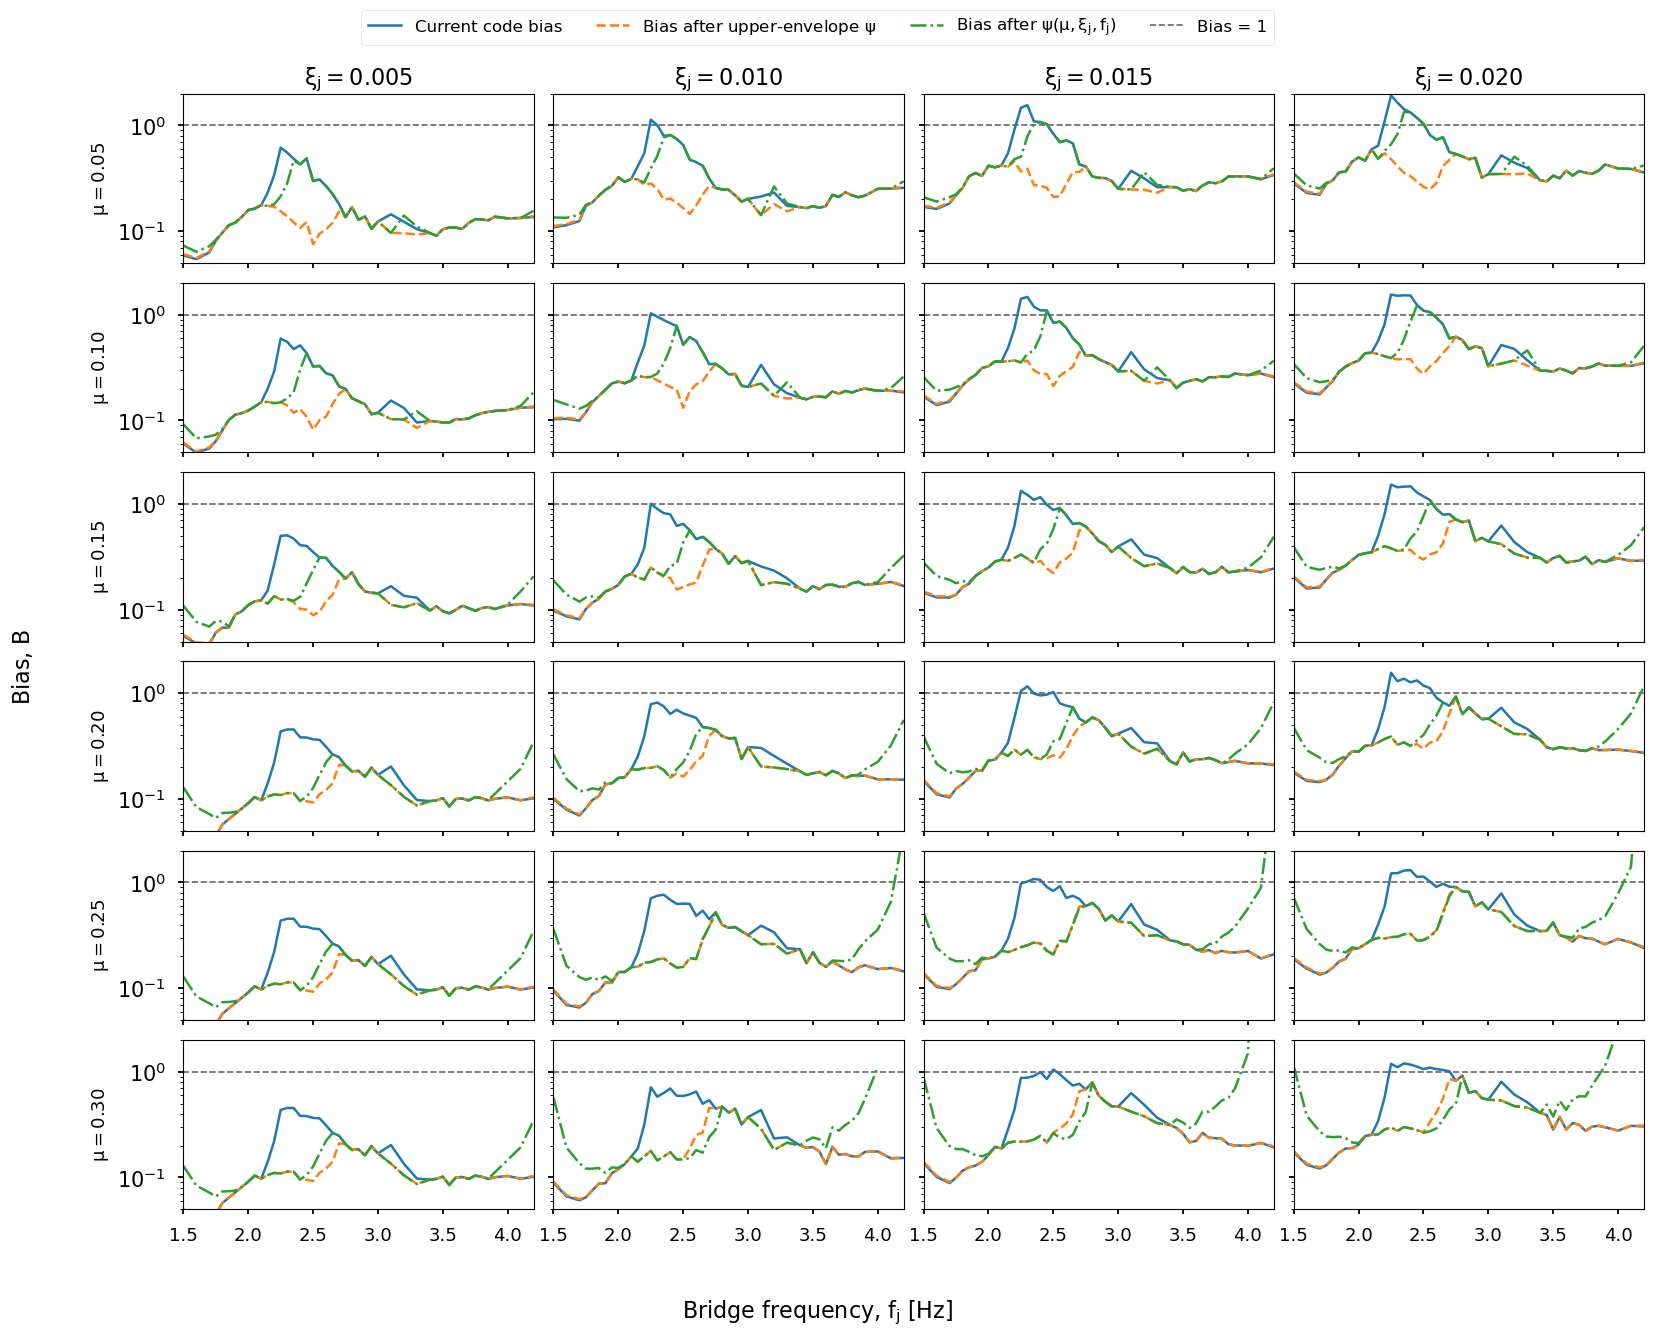

In [34]:
# ============================================================
# HELPERS FOR VARIABLE psi(mu, xi_j, f_j)
# ============================================================

MU_TO_DENSITY = {
    0.01: 0.0333,
    0.05: 0.1667,
    0.10: 0.3333,
    0.15: 0.5000,
    0.20: 0.6667,
    0.25: 0.8333,
    0.30: 1.0000,
}


# ============================================================
# 1. COLLECT f_j AND f_eff FROM NMFR RESULTS
# ============================================================

def collect_f0_feff(
    results_all,
    bands_to_combine,
    beamdamp,
    density
):

    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        # ----------------------------------------------------
        # Find the closest available damping key
        # This avoids exact floating-point key problems
        # ----------------------------------------------------

        available_dampings = list(
            results_all[band_name].keys()
        )

        if len(available_dampings) == 0:
            continue

        available_dampings_float = np.asarray(
            available_dampings,
            dtype=float
        )

        idx = np.argmin(
            np.abs(
                available_dampings_float
                - float(beamdamp)
            )
        )

        damping_key = available_dampings[idx]

        if not np.isclose(
            float(damping_key),
            float(beamdamp),
            atol=1e-8
        ):
            continue


        freq_dict = results_all[
            band_name
        ][
            damping_key
        ]


        for bf in sorted(freq_dict.keys()):

            # ------------------------------------------------
            # Find density key robustly
            # ------------------------------------------------

            available_densities = list(
                freq_dict[bf].keys()
            )

            if len(available_densities) == 0:
                continue

            available_densities_float = np.asarray(
                available_densities,
                dtype=float
            )

            idx_density = np.argmin(
                np.abs(
                    available_densities_float
                    - float(density)
                )
            )

            density_key = available_densities[
                idx_density
            ]

            if not np.isclose(
                float(density_key),
                float(density),
                atol=5e-4
            ):
                continue


            data = freq_dict[
                bf
            ][
                density_key
            ]


            if (
                "f0_peak" not in data
                or
                "f_eff_peak" not in data
            ):
                continue


            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)


            feff_arr = np.asarray(
                data["f_eff_peak"],
                dtype=float
            ).reshape(-1)


            valid = (
                np.isfinite(f0_arr)
                &
                np.isfinite(feff_arr)
            )


            if np.any(valid):

                x_vals.append(
                    np.nanmean(
                        f0_arr[valid]
                    )
                )

                y_vals.append(
                    np.nanmean(
                        feff_arr[valid]
                    )
                )


    x_vals = np.asarray(
        x_vals,
        dtype=float
    )

    y_vals = np.asarray(
        y_vals,
        dtype=float
    )


    if len(x_vals) == 0:

        return (
            x_vals,
            y_vals
        )


    order = np.argsort(
        x_vals
    )


    return (
        x_vals[order],
        y_vals[order]
    )


# ============================================================
# 2. GET VARIABLE psi CURVE
#
# psi(mu, xi_j, f_j)
#     =
# psi_original(f_eff(mu, xi_j, f_j))
# ============================================================

def get_variable_psi_curve(
    mu_val,
    xi_val
):

    mu_key = round(
        float(mu_val),
        2
    )


    if mu_key not in MU_TO_DENSITY:

        print(
            f"No density mapping for "
            f"mu = {mu_val}"
        )

        return (
            np.array([]),
            np.array([])
        )


    density = MU_TO_DENSITY[
        mu_key
    ]


    f_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=float(xi_val),
        density=density
    )


    f_vals = np.asarray(
        f_vals,
        dtype=float
    )

    feff_vals = np.asarray(
        feff_vals,
        dtype=float
    )


    valid = (
        np.isfinite(f_vals)
        &
        np.isfinite(feff_vals)
    )


    f_vals = f_vals[
        valid
    ]

    feff_vals = feff_vals[
        valid
    ]


    if len(f_vals) < 2:

        print(
            f"Insufficient mapping data for "
            f"mu={mu_val:.2f}, "
            f"xi_j={xi_val:.3f}"
        )

        return (
            np.array([]),
            np.array([])
        )


    order = np.argsort(
        f_vals
    )

    f_vals = f_vals[
        order
    ]

    feff_vals = feff_vals[
        order
    ]


    # --------------------------------------------------------
    # Evaluate original psi at effective frequency
    # --------------------------------------------------------

    psi_vals = psi_original(
        feff_vals
    )


    # --------------------------------------------------------
    # Average duplicate frequencies
    # --------------------------------------------------------

    temp = pd.DataFrame({
        "f": f_vals,
        "psi": psi_vals
    })


    temp = (
        temp
        .groupby(
            "f",
            as_index=False
        )["psi"]
        .mean()
        .sort_values("f")
    )


    return (
        temp["f"].to_numpy(
            dtype=float
        ),
        temp["psi"].to_numpy(
            dtype=float
        )
    )


# ============================================================
# 3. EVALUATE VARIABLE psi AT THE FREQUENCIES OF THE
#    BIAS DATA
# ============================================================

def evaluate_variable_psi(
    frequency,
    mu_val,
    xi_val
):

    frequency = np.asarray(
        frequency,
        dtype=float
    )


    map_f, map_psi = get_variable_psi_curve(
        mu_val,
        xi_val
    )


    if len(map_f) < 2:

        return np.full_like(
            frequency,
            np.nan,
            dtype=float
        )


    psi_interp = np.interp(
        frequency,
        map_f,
        map_psi,
        left=np.nan,
        right=np.nan
    )


    return psi_interp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 1. COPY CURRENT DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 2. SELECT PEAK ABSOLUTE ACCELERATION
# ============================================================

plot_df = comparison_df[
    comparison_df["measure"].astype(str).str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# ============================================================
# 3. MASS RATIOS + DAMPING RATIOS
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]


# ============================================================
# 4. COLOURS
# ============================================================

COLOR_CODE = "C0"           # blue
COLOR_ENVELOPE = "C1"       # orange
COLOR_VARIABLE = "C2"       # green


# ============================================================
# 5. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 6. DRAW PANELS
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                damping
            )
        ].copy()

        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # Bias = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        if not sub.empty:

            # =================================================
            # FREQUENCY ARRAY
            # =================================================

            f = sub[
                "bridge_frequency"
            ].to_numpy(dtype=float)


            # =================================================
            # ORIGINAL psi(f_j)
            # =================================================

            psi_old = psi_original(f)


            # =================================================
            # INDIVIDUAL psi(mu, xi_j, f_j)
            # =================================================

            psi_variable = evaluate_variable_psi(
                f,
                mass_ratio,
                damping
            )


            # =================================================
            # BIAS AFTER INDIVIDUAL psi
            #
            # B_new = B_original * psi_old / psi_variable
            # =================================================

            bias_variable_psi = np.where(
                (
                    np.isfinite(psi_variable)
                    &
                    (psi_variable > 1e-10)
                ),
                sub["code_bias_mean"].to_numpy(dtype=float)
                * psi_old
                / psi_variable,
                np.nan
            )


            # ------------------------------------------------
            # CURRENT CODE
            # ------------------------------------------------

            ax.plot(
                f,
                sub["code_bias_mean"],
                linewidth=1.8,
                linestyle="-",
                color=COLOR_CODE
            )


            # ------------------------------------------------
            # UPPER-ENVELOPE psi
            # ------------------------------------------------

            ax.plot(
                f,
                sub["newpsi_bias_mean"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ENVELOPE
            )


            # ------------------------------------------------
            # VARIABLE psi(mu, xi_j, f_j)
            # ------------------------------------------------

            ax.plot(
                f,
                bias_variable_psi,
                linewidth=1.8,
                linestyle="-.",
                color=COLOR_VARIABLE
            )


        # ----------------------------------------------------
        # COLUMN = xi_j
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
                rf"$\xi_j={damping:.3f}$"
            )


        # ----------------------------------------------------
        # ROW = mu
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$",
                fontsize=13
            )


        # ----------------------------------------------------
        # AXES
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            2.5
        )

        ax.grid(False)


# ============================================================
# 7. COMMON AXIS LABELS
# ============================================================

fig.supxlabel(
    r"Bridge frequency, $f_j$ [Hz]",
    fontsize=16,
    y=0.035
)

fig.supylabel(
    r"Bias, $B$",
    fontsize=16,
    x=0.04
)


# ============================================================
# 8. LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0], [0],
        color=COLOR_CODE,
        linewidth=1.8,
        linestyle="-",
        label="Current code bias"
    ),

    Line2D(
        [0], [0],
        color=COLOR_ENVELOPE,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after upper-envelope $\psi$"
    ),

    Line2D(
        [0], [0],
        color=COLOR_VARIABLE,
        linewidth=1.8,
        linestyle="-.",
        label=r"Bias after $\psi(\mu,\xi_j,f_j)$"
    ),

    Line2D(
        [0], [0],
        color="black",
        linewidth=1.2,
        linestyle="--",
        alpha=0.6,
        label="Bias = 1"
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=4,
    frameon=True
)


# ============================================================
# 9. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.04,
        0.045,
        0.995,
        0.94
    ]
)


# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "bias_upper_envelope_vs_variable_psi.pdf",
    bbox_inches="tight"
)

plt.show()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 1. COPY SECOND-LOAD-MODEL DATA
# ============================================================

comparison_df = compare_df.copy()

comparison_df["target_beamdamp"] = pd.to_numeric(
    comparison_df["damping_key"],
    errors="coerce"
)


# ============================================================
# 2. FREQUENCY RANGE
# ============================================================

plot_df = comparison_df[
    (comparison_df["bridge_frequency"] >= 1.50)
    &
    (comparison_df["bridge_frequency"] <= 4.20)
].copy()


# ============================================================
# 3. MASS + DAMPING RATIOS
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
]


# ============================================================
# 4. COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_ENVELOPE = "C1"
COLOR_VARIABLE = "C2"


# ============================================================
# 5. FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 6. SPECIAL REPEATED CURVES
# ============================================================

REPEAT_SOURCE_MU = 0.20

REPEAT_TARGETS = [
    (0.25, 0.005),
    (0.30, 0.005),
]


# ============================================================
# 7. DRAW PANELS
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]


        # ----------------------------------------------------
        # SOURCE DATA FOR EXISTING BIAS CURVES
        # ----------------------------------------------------

        is_repeat_panel = any(
            np.isclose(mass_ratio, target_mu)
            and
            np.isclose(damping, target_xi)
            for target_mu, target_xi in REPEAT_TARGETS
        )


        if is_repeat_panel:

            source_mass_ratio = REPEAT_SOURCE_MU
            source_damping = 0.005

        else:

            source_mass_ratio = mass_ratio
            source_damping = damping


        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                source_mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                source_damping
            )
        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # BIAS = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        if not sub.empty:

            f = sub[
                "bridge_frequency"
            ].to_numpy(dtype=float)


            # =================================================
            # ORIGINAL psi
            # =================================================

            psi_old = psi_original(f)


            # =================================================
            # VARIABLE psi
            #
            # Use same source parameters as repeated panels,
            # keeping the repeated-panel treatment consistent.
            # =================================================

            psi_variable = evaluate_variable_psi(
                f,
                source_mass_ratio,
                source_damping
            )


            # =================================================
            # VARIABLE-psi BIAS
            # =================================================

            bias_variable_psi = np.where(
                (
                    np.isfinite(psi_variable)
                    &
                    (psi_variable > 1e-10)
                ),
                sub["old_bias"].to_numpy(dtype=float)
                * psi_old
                / psi_variable,
                np.nan
            )


            # ------------------------------------------------
            # ORIGINAL CODE
            # ------------------------------------------------

            ax.plot(
                f,
                sub["old_bias"],
                linewidth=1.8,
                linestyle="-",
                color=COLOR_CODE
            )


            # ------------------------------------------------
            # UPPER-ENVELOPE psi
            # ------------------------------------------------

            ax.plot(
                f,
                sub["env_bias"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ENVELOPE
            )


            # ------------------------------------------------
            # VARIABLE psi(mu, xi_j, f_j)
            # ------------------------------------------------

            ax.plot(
                f,
                bias_variable_psi,
                linewidth=1.8,
                linestyle="-.",
                color=COLOR_VARIABLE
            )


        # ----------------------------------------------------
        # xi_j
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
                rf"$\xi_j={damping:.3f}$"
            )


        # ----------------------------------------------------
        # mu
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$",
                fontsize=13
            )


        # ----------------------------------------------------
        # AXES
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            2.0
        )

        ax.grid(False)


# ============================================================
# 8. COMMON AXES
# ============================================================

fig.supxlabel(
    r"Bridge frequency, $f_j$ [Hz]",
    fontsize=16,
    y=0.028
)

fig.supylabel(
    r"Bias, $B$",
    fontsize=16,
    x=0.025
)


# ============================================================
# 9. LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0], [0],
        color=COLOR_CODE,
        linewidth=1.8,
        linestyle="-",
        label="Current code bias"
    ),

    Line2D(
        [0], [0],
        color=COLOR_ENVELOPE,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after upper-envelope $\psi$"
    ),

    Line2D(
        [0], [0],
        color=COLOR_VARIABLE,
        linewidth=1.8,
        linestyle="-.",
        label=r"Bias after $\psi(\mu,\xi_j,f_j)$"
    ),

    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=4,
    frameon=True
)


# ============================================================
# 10. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.04,
        0.045,
        0.995,
        0.94
    ]
)


# ============================================================
# 11. SAVE
# ============================================================

plt.savefig(
    "second_load_model_upper_envelope_vs_variable_psi.pdf",
    bbox_inches="tight"
)

plt.show()

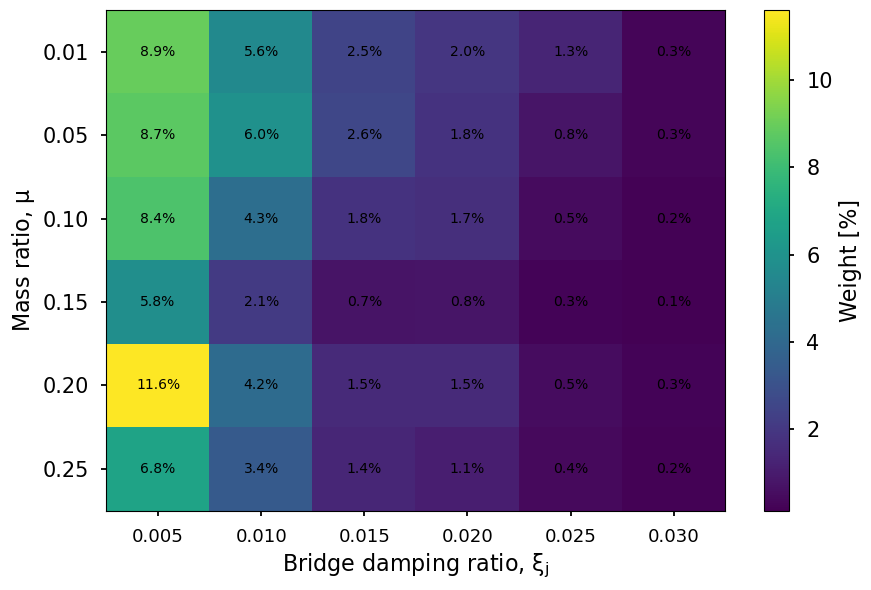

In [47]:
# ============================================================
# 18. PLOT WEIGHT MATRIX
# ============================================================

# ------------------------------------------------------------
# PLOT STYLE
# ------------------------------------------------------------

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# REMOVE UNWANTED ROWS / COLUMNS
# ============================================================

# Specify values you DO NOT want to plot

REMOVE_MU = [
    # 0.30,
]




# Make a plotting copy so the original matrix is unchanged
W_plot = W_percent_matrix.copy()

# Remove selected mu rows
W_plot = W_plot.drop(
    index=REMOVE_MU,
    errors="ignore"
)

# Remove selected damping columns
W_plot = W_plot.drop(
    columns=REMOVE_XI,
    errors="ignore"
)


# Values remaining in the plot
MU_PLOT = W_plot.index.to_numpy()
XI_PLOT = W_plot.columns.to_numpy()


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


im = ax.imshow(
    W_plot.to_numpy(),
    aspect="auto"
)


# ------------------------------------------------------------
# X AXIS
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(len(XI_PLOT))
)

ax.set_xticklabels(
    [
        f"{x:.3f}"
        for x in XI_PLOT
    ]
)


# ------------------------------------------------------------
# Y AXIS
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(len(MU_PLOT))
)

ax.set_yticklabels(
    [
        f"{x:.2f}"
        for x in MU_PLOT
    ]
)


# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xlabel(
    r"Bridge damping ratio, $\xi_j$"
)

ax.set_ylabel(
    r"Mass ratio, $\mu$"
)




# ============================================================
# PUT PERCENTAGES INSIDE CELLS
# ============================================================

for i in range(len(MU_PLOT)):

    for j in range(len(XI_PLOT)):

        value = W_plot.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )


# ============================================================
# COLORBAR
# ============================================================

fig.colorbar(
    im,
    ax=ax,
    label="Weight [%]"
)

plt.savefig(
    "population_probability_weight_matrix.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

MATERIAL DISTRIBUTION
Steel                         152 ( 60.80%)
Concrete                       43 ( 17.20%)
Steel-concrete composite       24 (  9.60%)
FRP                            17 (  6.80%)
Timber                          7 (  2.80%)
Other                           7 (  2.80%)

Total bridges = 250


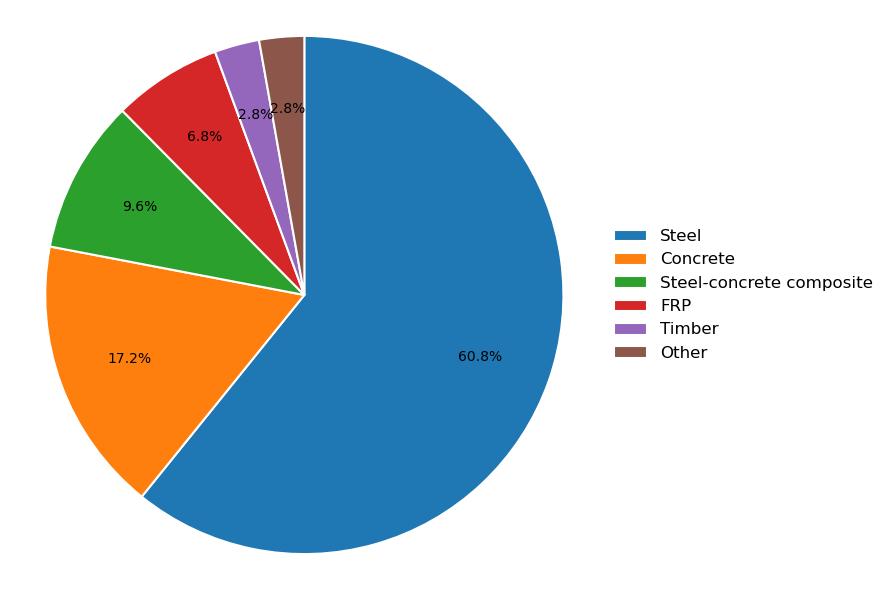

In [51]:
# ============================================================
# MATERIAL DISTRIBUTION — FROM MASTER BRIDGE DATABASE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATABASE
# ============================================================

MASTER_CSV = "data gong wei olivieri.csv"

df = pd.read_csv(
    MASTER_CSV,
    encoding="utf-8-sig"
)

df = df.dropna(how="all").copy()


# ============================================================
# 2. CLEAN MATERIAL DESCRIPTIONS
# ============================================================

def clean_material_group(x):

    s = str(x).strip().lower()

    # --------------------------------------------------------
    # Missing / unknown
    # --------------------------------------------------------

    if s in [
        "",
        "nan",
        "none",
        "-",
        "unknown",
        "other",
        "other types",
    ]:
        return "Other"

    # --------------------------------------------------------
    # FRP
    # --------------------------------------------------------

    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):
        return "FRP"

    # --------------------------------------------------------
    # Timber
    # --------------------------------------------------------

    if (
        "timber" in s
        or "wood" in s
        or "wooden" in s
    ):
        return "Timber"

    # --------------------------------------------------------
    # Steel-concrete composite
    # Check BEFORE plain steel / concrete
    # --------------------------------------------------------

    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
    ):
        return "Steel-concrete composite"

    # --------------------------------------------------------
    # Concrete
    # --------------------------------------------------------

    if (
        "concrete" in s
        or "reinforced concrete" in s
        or s == "rc"
    ):
        return "Concrete"

    # --------------------------------------------------------
    # Steel
    # --------------------------------------------------------

    if "steel" in s:
        return "Steel"

    # Everything else
    return "Other"


# ============================================================
# 3. GET MATERIALS DIRECTLY FROM DATABASE
# ============================================================

df["material"] = (
    df["girder_material"]
    .apply(clean_material_group)
)


# ============================================================
# 4. COUNT MATERIALS
# ============================================================

material_counts = (
    df["material"]
    .value_counts()
)

material_percent = (
    100
    * material_counts
    / material_counts.sum()
)


print("==========================================")
print("MATERIAL DISTRIBUTION")
print("==========================================")

for material, count in material_counts.items():

    percent = material_percent.loc[material]

    print(
        f"{material:28s} "
        f"{count:4d} "
        f"({percent:6.2f}%)"
    )


print(
    "\nTotal bridges =",
    material_counts.sum()
)


# ============================================================
# 5. PLOT STYLE
# ============================================================

plt.style.use('seaborn-v0_8-talk')

plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'


# ============================================================
# 6. PIE CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


wedges, texts, autotexts = ax.pie(
    material_counts.values,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.72,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5
    }
)


# ============================================================
# 7. LEGEND
# ============================================================

legend_labels = [

    f"{material}"

    for material, count
    in material_counts.items()
]


ax.legend(
    wedges,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)




ax.axis("equal")

plt.tight_layout()


# ============================================================
# 8. SAVE
# ============================================================

plt.savefig(
    "footbridge_material_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "footbridge_material_distribution.pdf",
    bbox_inches="tight"
)


plt.show()


Processing: W148_free1
Original number of samples : 156264
Known event duration        : 1200.00 s
Effective original fs       : 130.220000 Hz
Resampling ratio            : 5000/6511
Final sampling frequency    : 100.00 Hz
Final Nyquist frequency     : 50.00 Hz
Final number of samples     : 120000
Final represented duration  : 1200.00 s
High-pass filter            : 5th-order Butterworth
High-pass cutoff            : 0.25 Hz
Peak |acceleration|         : 1.564553 m/s²
RMS acceleration            : 0.093974 m/s²

Processing: W148_free2
Original number of samples : 137994
Known event duration        : 1200.00 s
Effective original fs       : 114.995000 Hz
Resampling ratio            : 20000/22999
Final sampling frequency    : 100.00 Hz
Final Nyquist frequency     : 50.00 Hz
Final number of samples     : 120000
Final represented duration  : 1200.00 s
High-pass filter            : 5th-order Butterworth
High-pass cutoff            : 0.25 Hz
Peak |acceleration|         : 0.421454 m/s²
RMS ac

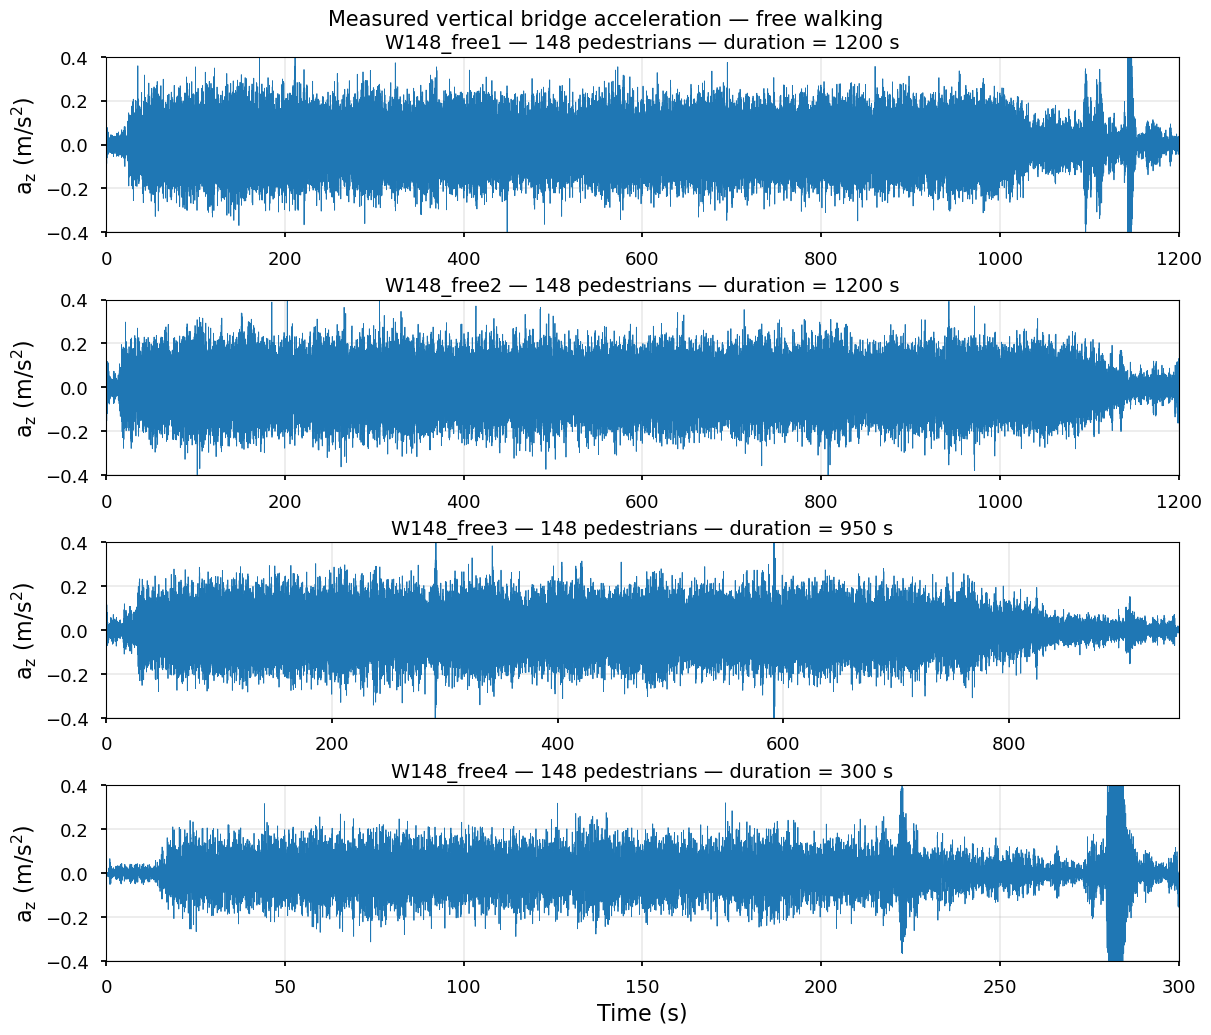

In [80]:
# ============================================================
# EEKLO W148 FREE-WALKING EXPERIMENTS
#
# Processing used here:
#
#   1. Assign the available samples to the reported event
#      duration:
#
#           fs_original = N / T
#
#   2. Remove linear trend (MATLAB detrend equivalent)
#
#   3. Resample to 100 Hz using polyphase resampling
#      - includes anti-alias low-pass filtering
#      - final Nyquist frequency = 50 Hz
#
#   4. Apply 5th-order Butterworth high-pass filter
#      with cutoff = 0.25 Hz
#
#   5. Plot the four processed acceleration histories
#
# NOTE:
# This reproduces the published filtering conditions as closely
# as possible while using fs = N/T instead of assuming the raw
# data are still at 200 Hz.
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
from fractions import Fraction

import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import (
    detrend,
    resample_poly,
    butter,
    sosfiltfilt,
)


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use("seaborn-v0_8-talk")

plt.rcParams["font.monospace"] = "Ubuntu Mono"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"


# ============================================================
# DATA LOCATION
# ============================================================

data_folder = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set"
)


# ============================================================
# SENSOR
# ============================================================

target_sensor = 214


# ============================================================
# PROCESSING PARAMETERS
# ============================================================

TARGET_FS = 100.0             # Hz

HIGHPASS_CUTOFF_HZ = 0.25    # Hz
HIGHPASS_ORDER = 5


# ============================================================
# TEST INFORMATION
#
# Reported event durations
# ============================================================

test_settings = {

    1: {
        "name": "W148_free1",
        "duration": 1200.0,
    },

    2: {
        "name": "W148_free2",
        "duration": 1200.0,
    },

    3: {
        "name": "W148_free3",
        "duration": 950.0,
    },

    4: {
        "name": "W148_free4",
        "duration": 300.0,
    },
}


# ============================================================
# FUNCTION:
# LOAD VERTICAL ACCELERATION FROM MAT FILE
# ============================================================

def load_vertical_acceleration(
    mat_file,
    sensor_number=214,
):

    with h5py.File(mat_file, "r") as f:

        # ----------------------------------------------------
        # Vertical acceleration matrix
        # ----------------------------------------------------

        z_accelerations = np.asarray(
            f["structural_accelerations"]["z"],
            dtype=float,
        )


        # ----------------------------------------------------
        # Sensor numbers
        # ----------------------------------------------------

        sensor_numbers = np.asarray(
            f["structural_accelerations"]["sensors"]
        ).squeeze().astype(int).ravel()


    # ========================================================
    # DETERMINE MATRIX ORIENTATION
    #
    # Desired:
    #
    # rows    = time samples
    # columns = sensors
    # ========================================================

    n_sensors = len(sensor_numbers)


    if z_accelerations.shape[1] == n_sensors:

        # Already correct
        pass


    elif z_accelerations.shape[0] == n_sensors:

        # Transpose
        z_accelerations = z_accelerations.T


    else:

        raise ValueError(
            f"Could not determine orientation for "
            f"{mat_file.name}.\n"
            f"Acceleration shape = {z_accelerations.shape}\n"
            f"Number of sensors  = {n_sensors}"
        )


    # ========================================================
    # FIND TARGET SENSOR
    # ========================================================

    matching_indices = np.where(
        sensor_numbers == sensor_number
    )[0]


    if len(matching_indices) == 0:

        raise ValueError(
            f"Sensor {sensor_number} not found in "
            f"{mat_file.name}.\n"
            f"Available sensors:\n"
            f"{sensor_numbers.tolist()}"
        )


    sensor_column = int(
        matching_indices[0]
    )


    # ========================================================
    # EXTRACT VERTICAL ACCELERATION
    # ========================================================

    acceleration = np.asarray(
        z_accelerations[
            :,
            sensor_column,
        ],
        dtype=float,
    ).copy()


    return acceleration


# ============================================================
# FUNCTION:
# DETREND + RESAMPLE TO 100 Hz
# ============================================================

def resample_to_100Hz(
    acceleration,
    duration,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()


    # ========================================================
    # ORIGINAL NUMBER OF SAMPLES
    # ========================================================

    n_original = len(
        acceleration
    )


    # ========================================================
    # EFFECTIVE ORIGINAL SAMPLING FREQUENCY
    #
    # The complete available signal is assigned to the known
    # experimental event duration:
    #
    #           fs = N / T
    # ========================================================

    fs_original = (
        n_original
        / duration
    )


    # ========================================================
    # STEP 1:
    # REMOVE LINEAR TREND
    #
    # MATLAB:
    #
    #     detrend(x)
    #
    # removes the best-fit linear trend.
    # ========================================================

    acceleration_detrended = detrend(
        acceleration,
        type="linear",
    )


    # ========================================================
    # STEP 2:
    # CALCULATE RESAMPLING RATIO
    #
    # target fs / original fs = up / down
    # ========================================================

    ratio = Fraction(
        TARGET_FS / fs_original
    ).limit_denominator(
        100000
    )


    up = ratio.numerator
    down = ratio.denominator


    # ========================================================
    # POLYPHASE RESAMPLING
    #
    # scipy.signal.resample_poly:
    #
    #   - low-pass filters the signal
    #   - protects against aliasing
    #   - changes the sampling frequency
    #
    # This replaces MATLAB decimate because our inferred
    # original fs values are not exactly 200 Hz.
    # ========================================================

    acceleration_100Hz = resample_poly(
        acceleration_detrended,
        up=up,
        down=down,
    )


    # ========================================================
    # TARGET NUMBER OF SAMPLES
    #
    # e.g.
    #
    # 1200 s x 100 Hz = 120000 samples
    # ========================================================

    n_target = int(
        round(
            duration
            * TARGET_FS
        )
    )


    # ========================================================
    # HANDLE POSSIBLE ONE-SAMPLE ROUNDING DIFFERENCE
    # ========================================================

    if len(acceleration_100Hz) > n_target:

        acceleration_100Hz = (
            acceleration_100Hz[
                :n_target
            ]
        )


    elif len(acceleration_100Hz) < n_target:

        n_missing = (
            n_target
            - len(acceleration_100Hz)
        )

        acceleration_100Hz = np.pad(
            acceleration_100Hz,
            pad_width=(
                0,
                n_missing,
            ),
            mode="edge",
        )


    # ========================================================
    # CREATE EXACT 100-Hz TIME VECTOR
    # ========================================================

    time_100Hz = (
        np.arange(
            n_target
        )
        / TARGET_FS
    )


    return (
        time_100Hz,
        acceleration_100Hz,
        fs_original,
        up,
        down,
    )


# ============================================================
# FUNCTION:
# FIFTH-ORDER 0.25-Hz BUTTERWORTH HIGH-PASS FILTER
# ============================================================

def highpass_filter(
    acceleration,
):

    # ========================================================
    # DESIGN FILTER
    #
    # final sampling rate = 100 Hz
    #
    # Nyquist frequency:
    #
    #       100 / 2 = 50 Hz
    #
    # High-pass cutoff:
    #
    #       0.25 Hz
    # ========================================================

    sos = butter(
        N=HIGHPASS_ORDER,
        Wn=HIGHPASS_CUTOFF_HZ,
        btype="highpass",
        fs=TARGET_FS,
        output="sos",
    )


    # ========================================================
    # ZERO-PHASE FILTERING
    # ========================================================

    acceleration_filtered = sosfiltfilt(
        sos,
        acceleration,
    )


    return acceleration_filtered


# ============================================================
# PROCESS ALL FOUR TESTS
# ============================================================

results = {}


for test_number, settings in test_settings.items():

    # ========================================================
    # FILE
    # ========================================================

    mat_file = (
        data_folder
        / f"{settings['name']}.mat"
    )


    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Processing: "
        f"{settings['name']}"
    )


    # ========================================================
    # LOAD ORIGINAL VERTICAL ACCELERATION
    # ========================================================

    acceleration_original = (
        load_vertical_acceleration(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )


    duration = float(
        settings["duration"]
    )


    # ========================================================
    # DETREND AND RESAMPLE TO 100 Hz
    # ========================================================

    (
        time_100Hz,
        acceleration_100Hz,
        fs_original,
        up,
        down,
    ) = resample_to_100Hz(
        acceleration=acceleration_original,
        duration=duration,
    )


    # ========================================================
    # APPLY FIFTH-ORDER 0.25-Hz HIGH-PASS
    # ========================================================

    acceleration_filtered = (
        highpass_filter(
            acceleration_100Hz
        )
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results[
        test_number
    ] = {

        "name": settings["name"],

        "duration": duration,

        "fs_original": fs_original,

        "fs_final": TARGET_FS,

        "time": time_100Hz,

        "acceleration_original": (
            acceleration_original
        ),

        "acceleration_100Hz": (
            acceleration_100Hz
        ),

        "acceleration_filtered": (
            acceleration_filtered
        ),
    }


    # ========================================================
    # PRINT PROCESSING INFORMATION
    # ========================================================

    print(
        f"Original number of samples : "
        f"{len(acceleration_original)}"
    )

    print(
        f"Known event duration        : "
        f"{duration:.2f} s"
    )

    print(
        f"Effective original fs       : "
        f"{fs_original:.6f} Hz"
    )

    print(
        f"Resampling ratio            : "
        f"{up}/{down}"
    )

    print(
        f"Final sampling frequency    : "
        f"{TARGET_FS:.2f} Hz"
    )

    print(
        f"Final Nyquist frequency     : "
        f"{TARGET_FS / 2:.2f} Hz"
    )

    print(
        f"Final number of samples     : "
        f"{len(acceleration_filtered)}"
    )

    print(
        f"Final represented duration  : "
        f"{len(acceleration_filtered) / TARGET_FS:.2f} s"
    )

    print(
        f"High-pass filter            : "
        f"{HIGHPASS_ORDER}th-order Butterworth"
    )

    print(
        f"High-pass cutoff            : "
        f"{HIGHPASS_CUTOFF_HZ:.2f} Hz"
    )

    print(
        f"Peak |acceleration|         : "
        f"{np.max(np.abs(acceleration_filtered)):.6f} m/s²"
    )

    print(
        f"RMS acceleration            : "
        f"{np.sqrt(np.mean(acceleration_filtered**2)):.6f} m/s²"
    )


# ============================================================
# CHECK EFFECTIVE SAMPLING FREQUENCIES
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "SUMMARY"
)

print(
    "=" * 70
)


for test_number, result in results.items():

    print(
        f"{result['name']:12s} | "
        f"T = {result['duration']:7.1f} s | "
        f"fs_original = {result['fs_original']:10.4f} Hz | "
        f"fs_final = {result['fs_final']:6.1f} Hz"
    )


# ============================================================
# COMMON Y-AXIS LIMIT
#
# Using one y-axis scale makes amplitude comparisons between
# experiments meaningful.
# ============================================================

global_peak = max(

    np.max(
        np.abs(
            result[
                "acceleration_filtered"
            ]
        )
    )

    for result in results.values()
)


y_limit = (
    1.05
    * global_peak
)


# ============================================================
# PLOT ALL FOUR TIME HISTORIES
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        12,
        10,
    ),
    sharey=True,
    constrained_layout=True,
)


for ax, (
    test_number,
    result,
) in zip(
    axes,
    results.items(),
):

    # ========================================================
    # SIGNAL
    # ========================================================

    ax.plot(
        result["time"],
        result[
            "acceleration_filtered"
        ],
        linewidth=0.6,
    )


    # ========================================================
    # AXIS LIMITS
    # ========================================================

    ax.set_xlim(
        0,
        result["duration"],
    )

    ax.set_ylim(
        -0.4,
        0.4,
    )


    # ========================================================
    # LABELS
    # ========================================================

    ax.set_ylabel(
        r"$a_z$ (m/s$^2$)"
    )


    ax.set_title(
        f"{result['name']} "
        f"— 148 pedestrians "
        f"— duration = "
        f"{result['duration']:.0f} s"
    )


    # ========================================================
    # GRID
    # ========================================================

    ax.grid(
        True,
        alpha=0.25,
    )


# ============================================================
# COMMON X LABEL
# ============================================================

axes[-1].set_xlabel(
    "Time (s)"
)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "Measured vertical bridge acceleration — free walking",
    y=1.02,
)


plt.show()

In [86]:
# ============================================================
# 95TH PERCENTILE ABSOLUTE ACCELERATION
# WITHIN STEADY-STATE WINDOWS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# STEADY-STATE WINDOWS
# ============================================================

steady_windows = {

    1: (0.0, 1000.0),   # W148_free1

    2: (0.0, 1000.0),   # W148_free2

    3: (0.0, 550.0),      # W148_free3

    4: (0.0, 250.0),      # W148_free4
}


# ============================================================
# CALCULATE 95TH PERCENTILE
# ============================================================

percentile_results = []


for test_number, result in results.items():

    # --------------------------------------------------------
    # Get steady-state window
    # --------------------------------------------------------

    t_start, t_end = steady_windows[
        test_number
    ]


    # --------------------------------------------------------
    # Processed time and acceleration
    # --------------------------------------------------------

    time = result["time"]

    acceleration = result[
        "acceleration_filtered"
    ]


    # --------------------------------------------------------
    # Select steady-state region
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    acceleration_steady = acceleration[
        mask
    ]


    # --------------------------------------------------------
    # Absolute acceleration
    # --------------------------------------------------------

    absolute_acceleration = np.abs(
        acceleration_steady
    )


    # --------------------------------------------------------
    # 95th percentile
    # --------------------------------------------------------

    a95 = np.percentile(
        absolute_acceleration,
        95
    )


    # --------------------------------------------------------
    # Also calculate useful checks
    # --------------------------------------------------------

    fs = 1.0 / np.median(
        np.diff(time)
    )

    window_samples = int(
        round(fs)
    )

    moving_mean_square = np.convolve(
        acceleration_steady**2,
        np.ones(window_samples) / window_samples,
        mode="valid"
    )

    rms_1s = np.sqrt(
        moving_mean_square
    )

    peak_1s_rms = np.max(
        rms_1s
    )

    peak = np.max(
        absolute_acceleration
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    percentile_results.append({

        "Test": result["name"],

        "Window start (s)": t_start,

        "Window end (s)": t_end,

        "Window duration (s)": (
            t_end - t_start
        ),

        "P95 |a| (m/s²)": a95,

        "Peak 1-s RMS (m/s²)": peak_1s_rms,

        "Peak |a| (m/s²)": peak,
    })


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"{result['name']}: "
        f"P95 |a| = {a95:.6f} m/s²"
    )


# ============================================================
# CREATE TABLE
# ============================================================

percentile_df = pd.DataFrame(
    percentile_results
)


print(
    "\n"
    + "=" * 80
)

print(
    "STEADY-STATE RESPONSE RESULTS"
)

print(
    "=" * 80
)

print(
    percentile_df.to_string(
        index=False
    )
)

W148_free1: P95 |a| = 0.172667 m/s²
W148_free2: P95 |a| = 0.171266 m/s²
W148_free3: P95 |a| = 0.165448 m/s²
W148_free4: P95 |a| = 0.152801 m/s²

STEADY-STATE RESPONSE RESULTS
      Test  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  Peak 1-s RMS (m/s²)  Peak |a| (m/s²)
W148_free1               0.0          1000.0               1000.0        0.172667             0.144727         0.425613
W148_free2               0.0          1000.0               1000.0        0.171266             0.164361         0.421454
W148_free3               0.0           550.0                550.0        0.165448             0.222377         0.442490
W148_free4               0.0           250.0                250.0        0.152801             0.236275         0.397483


In [72]:
# ============================================================
# 95TH PERCENTILE ABSOLUTE ACCELERATION
# WITHIN STEADY-STATE WINDOWS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# STEADY-STATE WINDOWS
# ============================================================

steady_windows = {

    1: (200.0, 1000.0),   # W148_free1

    2: (200.0, 1000.0),   # W148_free2

    3: (1.0, 500.0),      # W148_free3

    4: (0.0, 200.0),      # W148_free4
}


# ============================================================
# CALCULATE 95TH PERCENTILE
# ============================================================

percentile_results = []


for test_number, result in results.items():

    # --------------------------------------------------------
    # Get steady-state window
    # --------------------------------------------------------

    t_start, t_end = steady_windows[
        test_number
    ]


    # --------------------------------------------------------
    # Processed time and acceleration
    # --------------------------------------------------------

    time = result["time"]

    acceleration = result[
        "acceleration_filtered"
    ]


    # --------------------------------------------------------
    # Select steady-state region
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    acceleration_steady = acceleration[
        mask
    ]


    # --------------------------------------------------------
    # Absolute acceleration
    # --------------------------------------------------------

    absolute_acceleration = np.abs(
        acceleration_steady
    )


    # --------------------------------------------------------
    # 95th percentile
    # --------------------------------------------------------

    a95 = np.percentile(
        absolute_acceleration,
        95
    )


    # --------------------------------------------------------
    # Also calculate useful checks
    # --------------------------------------------------------

    rms = np.sqrt(
        np.mean(
            acceleration_steady**2
        )
    )

    peak = np.max(
        absolute_acceleration
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    percentile_results.append({

        "Test": result["name"],

        "Window start (s)": t_start,

        "Window end (s)": t_end,

        "Window duration (s)": (
            t_end - t_start
        ),

        "P95 |a| (m/s²)": a95,

        "RMS (m/s²)": rms,

        "Peak |a| (m/s²)": peak,
    })


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"{result['name']}: "
        f"P95 |a| = {a95:.6f} m/s²"
    )


# ============================================================
# CREATE TABLE
# ============================================================

percentile_df = pd.DataFrame(
    percentile_results
)


print(
    "\n"
    + "=" * 80
)

print(
    "STEADY-STATE RESPONSE RESULTS"
)

print(
    "=" * 80
)

print(
    percentile_df.to_string(
        index=False
    )
)

W148_free1: P95 |a| = 0.171647 m/s²
W148_free2: P95 |a| = 0.169938 m/s²
W148_free3: P95 |a| = 0.166729 m/s²
W148_free4: P95 |a| = 0.153164 m/s²

STEADY-STATE RESPONSE RESULTS
      Test  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  RMS (m/s²)  Peak |a| (m/s²)
W148_free1             200.0          1000.0                800.0        0.171647    0.087213         0.425613
W148_free2             200.0          1000.0                800.0        0.169938    0.086637         0.414682
W148_free3               1.0           500.0                499.0        0.166729    0.084048         0.442490
W148_free4               0.0           200.0                200.0        0.153164    0.077017         0.319773


In [59]:
# ============================================================
# CALCULATE PROPOSED MODIFICATION FACTORS
# FOR EACH MODE
# ============================================================

import numpy as np
from scipy.integrate import quad


# ============================================================
# BASIC DATA
# ============================================================

length = 96.0
width = 2.0

density = 0.5                  # ped/m²
pedestrian_mass = 70.0         # kg

beamFreq = np.array([
    1.71,
    2.99
])

modalDampingRatio = np.array([
    0.0194,
    0.0019
])

modalmass = np.array([
    202000.0,
    22000.0
])


# ============================================================
# MODE SHAPES
# ============================================================

def curve1(x):

    return (
        1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03
    )


def curve2(x):

    return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )


func_list = [
    curve1,
    curve2
]


# ============================================================
# PEDESTRIAN LINEAR MASS
#
# 70 kg/ped × 0.5 ped/m² × 2 m
# ============================================================

ped_linear_mass = (
    pedestrian_mass
    * density
    * width
)

print(
    f"Pedestrian linear mass = "
    f"{ped_linear_mass:.3f} kg/m"
)


# ============================================================
# PEDESTRIAN MODAL MASSES
#
# Mp,j = integral m_p(x) phi_j(x)^2 dx
# ============================================================

ped_modal_mass = np.zeros(2)


for j, phi in enumerate(func_list):

    integral_phi2, _ = quad(
        lambda x: phi(x)**2,
        0,
        length
    )

    ped_modal_mass[j] = (
        ped_linear_mass
        * integral_phi2
    )


# ============================================================
# MODAL MASS RATIOS
# ============================================================

mu = (
    ped_modal_mass
    / modalmass
)


# ============================================================
# OLD psi
# ============================================================

def psi_old(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(x)


    # 1.25–1.70
    m = (
        (x >= 1.25)
        & (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        / (1.70 - 1.25)
    )


    # 1.70–2.10
    m = (
        (x >= 1.70)
        & (x <= 2.10)
    )

    psi[m] = 1.0


    # 2.10–2.30
    m = (
        (x > 2.10)
        & (x < 2.30)
    )

    psi[m] = (
        1.0
        - (x[m] - 2.10)
        / (2.30 - 2.10)
    )


    # 2.50–3.40
    m = (
        (x > 2.50)
        & (x < 3.40)
    )

    psi[m] = (
        0.25
        * (x[m] - 2.50)
        / (3.40 - 2.50)
    )


    # 3.40–4.20
    m = (
        (x >= 3.40)
        & (x <= 4.20)
    )

    psi[m] = 0.25


    # 4.20–4.60
    m = (
        (x > 4.20)
        & (x <= 4.60)
    )

    psi[m] = (
        0.25
        * (
            1.0
            - (x[m] - 4.20)
            / (4.60 - 4.20)
        )
    )


    # Minimum rule
    m = (
        (x >= 2.25)
        & (x <= 3.0)
    )

    psi[m] = np.maximum(
        psi[m],
        0.25
    )


    return psi


# ============================================================
# NEW psi — Eq. (38)
# ============================================================

def psi_new(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(x)


    # 1.25 <= f < 1.70
    m = (
        (x >= 1.25)
        & (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        / 0.45
    )


    # 1.70 <= f < 2.50
    m = (
        (x >= 1.70)
        & (x < 2.50)
    )

    psi[m] = 1.0


    # 2.50 <= f < 2.75
    m = (
        (x >= 2.50)
        & (x < 2.75)
    )

    psi[m] = (
        1.0
        - 3.0
        * (x[m] - 2.50)
    )


    # 2.75 <= f < 4.20
    m = (
        (x >= 2.75)
        & (x < 4.20)
    )

    psi[m] = 0.25


    # 4.20 <= f <= 4.60
    m = (
        (x >= 4.20)
        & (x <= 4.60)
    )

    psi[m] = (
        0.25
        * (4.60 - x[m])
        / 0.40
    )


    return psi


# ============================================================
# LOW-DENSITY RESIDUAL CORRECTION
# ============================================================

def c_final_LD(mu, xi):

    return (
        0.4
        - 0.6 * mu
        + 5.0 * xi
        + 44.0 * mu * xi
    )


# ============================================================
# CALCULATE
# ============================================================

c_final = c_final_LD(
    mu,
    modalDampingRatio
)

psi_old_values = psi_old(
    beamFreq
)

psi_new_values = psi_new(
    beamFreq
)


# ============================================================
# FACTOR TO PASS TO EXISTING NEWMARK SOLVER
#
# Existing solver already applies psi_old.
#
# Therefore:
#
# R = psi_new * c_final / psi_old
# ============================================================

modification_factor = (
    psi_new_values
    * c_final
    / psi_old_values
)


# ============================================================
# PRINT
# ============================================================

for j in range(2):

    print("\n" + "=" * 55)

    print(
        f"MODE {j+1}"
    )

    print(
        f"Frequency               = "
        f"{beamFreq[j]:.3f} Hz"
    )

    print(
        f"Structural damping      = "
        f"{modalDampingRatio[j]:.5f}"
    )

    print(
        f"Structural modal mass   = "
        f"{modalmass[j]:.2f} kg"
    )

    print(
        f"Pedestrian modal mass   = "
        f"{ped_modal_mass[j]:.2f} kg"
    )

    print(
        f"Modal mass ratio mu     = "
        f"{mu[j]:.6f}"
    )

    print(
        f"Old psi                 = "
        f"{psi_old_values[j]:.6f}"
    )

    print(
        f"New psi                 = "
        f"{psi_new_values[j]:.6f}"
    )

    print(
        f"c_final LD              = "
        f"{c_final[j]:.6f}"
    )

    print(
        f"Solver modification     = "
        f"{modification_factor[j]:.6f}"
    )

Pedestrian linear mass = 70.000 kg/m

MODE 1
Frequency               = 1.710 Hz
Structural damping      = 0.01940
Structural modal mass   = 202000.00 kg
Pedestrian modal mass   = 2999.37 kg
Modal mass ratio mu     = 0.014848
Old psi                 = 1.000000
New psi                 = 1.000000
c_final LD              = 0.500766
Solver modification     = 0.500766

MODE 2
Frequency               = 2.990 Hz
Structural damping      = 0.00190
Structural modal mass   = 22000.00 kg
Pedestrian modal mass   = 1793.88 kg
Modal mass ratio mu     = 0.081540
Old psi                 = 0.250000
New psi                 = 0.250000
c_final LD              = 0.367393
Solver modification     = 0.367393


Pedestrian linear mass = 70.000 kg/m

MODAL CORRECTION FACTORS

MODE 1
f_j                     = 1.710 Hz
xi_j                    = 0.01940
Structural modal mass   = 202000.000 kg
Pedestrian modal mass   = 2999.368 kg
mu_j                    = 0.014848
psi_old                 = 1.000000
psi_new                 = 1.000000
c_final                 = 0.500766
Solver modification     = 0.500766

MODE 2
f_j                     = 2.990 Hz
xi_j                    = 0.00190
Structural modal mass   = 22000.000 kg
Pedestrian modal mass   = 1793.883 kg
mu_j                    = 0.081540
psi_old                 = 0.250000
psi_new                 = 0.250000
c_final                 = 0.367393
Solver modification     = 0.367393

RUNNING MODE 1

RUNNING MODE 2

RESPONSE RESULTS

MODE 1
Original P95 = 0.308452 m/s²
Proposed P95 = 0.154462 m/s²

MODE 2
Original P95 = 0.769509 m/s²
Proposed P95 = 0.282712 m/s²

TOTAL RESPONSE
Original P95 = 1.009406 m/s²
Proposed P95 = 0.407025 m/s²

Original RMS = 0.5860

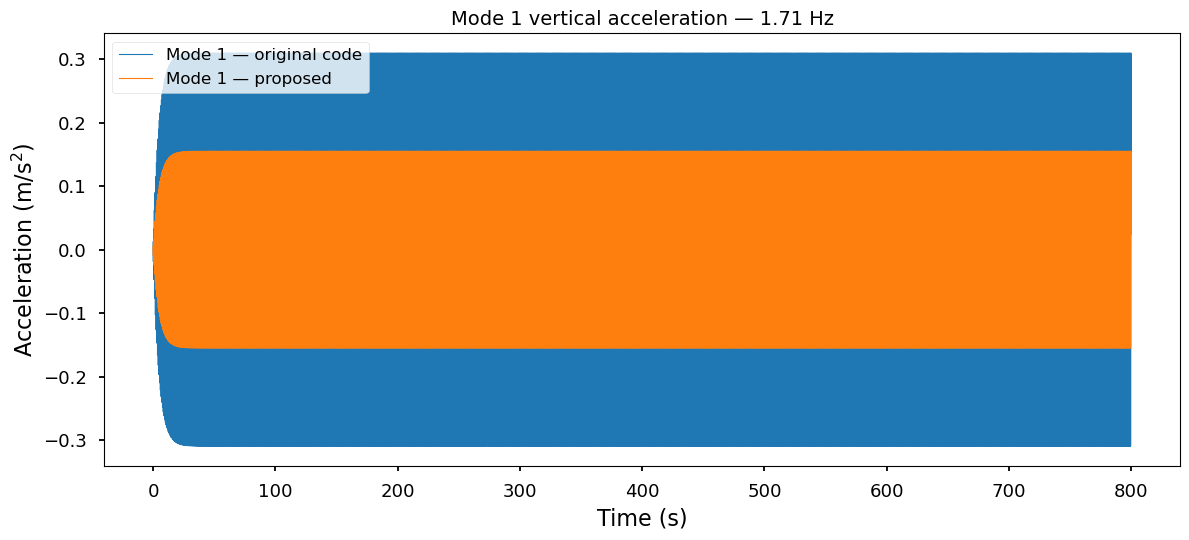

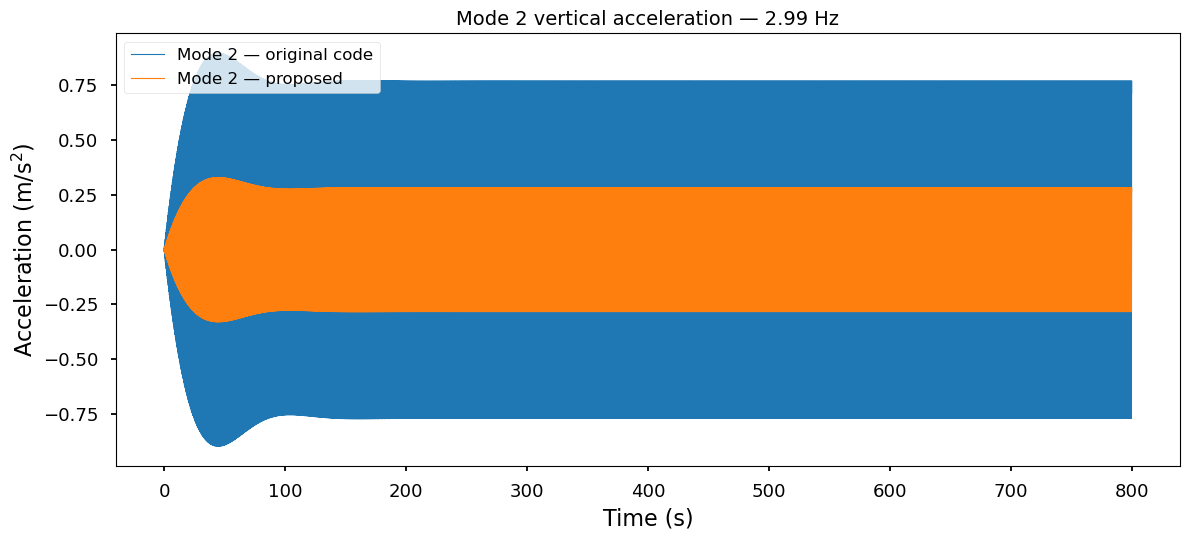

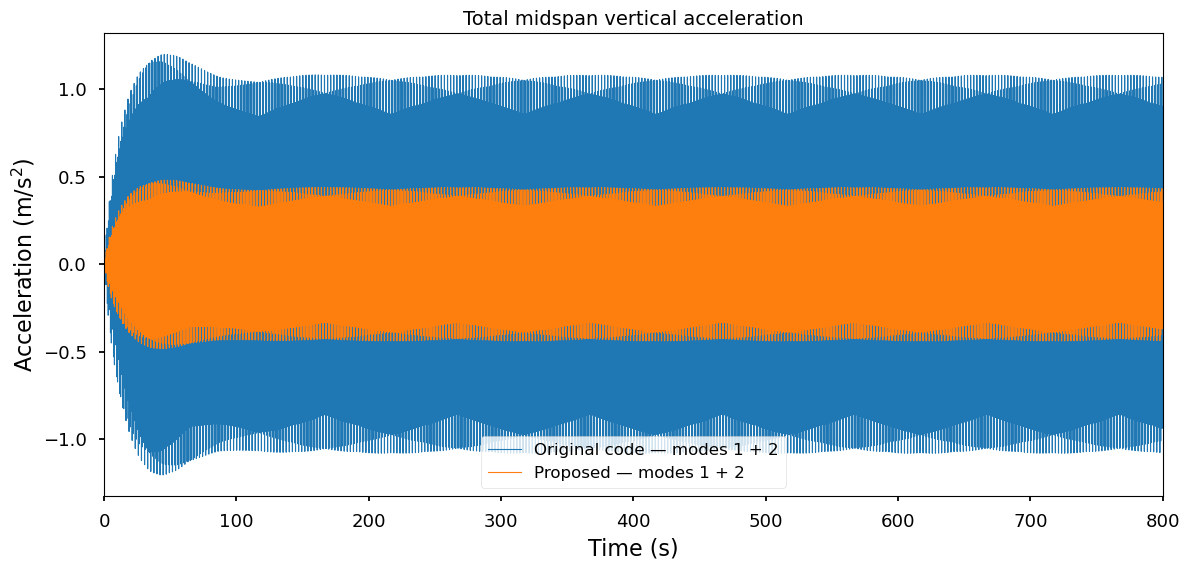

In [67]:
from matrix import *
from solver import *
from pedestrian import *

from matplotlib import pyplot as plt

import math
import numpy as np

from scipy.integrate import quad


# ============================================================
# 1. GLOBAL BRIDGE DATA
# ============================================================

length = 96.0
width = 2.0
height = 0.6

linearMass = 1020.0

x_interested = length / 2


# ============================================================
# MODAL DATA
# ============================================================

beamFreq = np.array([
    1.71,
    2.99,
])

modalDampingRatio = np.array([
    0.0194,
    0.0019,
])

modalmass = np.array([
    202000.0,
    22000.0,
])


# ============================================================
# 2. MODE SHAPES
# ============================================================

def curve1(x):

    return (
        1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03
    )


def curve2(x):

    return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )


func_list_all = [
    curve1,
    curve2,
]


# ============================================================
# 3. TIME SETTINGS
# ============================================================

hht = 0.01

t_end = 800.0


# ============================================================
# 4. PEDESTRIAN DATA
# ============================================================

density = 0.5          # ped/m²

average_pedestrian_mass = 70.0  # kg


# Pedestrian linear mass:
#
# 70 kg/ped x 0.5 ped/m² x 2 m
#
# = 70 kg/m

pedestrian_linear_mass = (
    average_pedestrian_mass
    * density
    * width
)


print(
    f"Pedestrian linear mass = "
    f"{pedestrian_linear_mass:.3f} kg/m"
)


# ============================================================
# 5. PEDESTRIAN MODAL MASS
#
# Mp,j = integral m_p(x) phi_j(x)^2 dx
# ============================================================

ped_modal_mass = np.zeros(2)


for j, phi in enumerate(func_list_all):

    integral_phi_squared, _ = quad(
        lambda x: phi(x)**2,
        0,
        length
    )

    ped_modal_mass[j] = (
        pedestrian_linear_mass
        * integral_phi_squared
    )


# ============================================================
# 6. MODAL MASS RATIO
#
# mu_j = pedestrian modal mass / structural modal mass
# ============================================================

mu = (
    ped_modal_mass
    / modalmass
)


# ============================================================
# 7. OLD psi
#
# This is the psi already used internally by Newmarksuper_Code
# ============================================================

def psi_old(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(x)


    # 1.25–1.70 : 0 -> 1
    m = (
        (x >= 1.25)
        & (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        / (1.70 - 1.25)
    )


    # 1.70–2.10 : 1
    m = (
        (x >= 1.70)
        & (x <= 2.10)
    )

    psi[m] = 1.0


    # 2.10–2.30 : 1 -> 0
    m = (
        (x > 2.10)
        & (x < 2.30)
    )

    psi[m] = (
        1.0
        - (x[m] - 2.10)
        / (2.30 - 2.10)
    )


    # 2.50–3.40 : 0 -> 0.25
    m = (
        (x > 2.50)
        & (x < 3.40)
    )

    psi[m] = (
        0.25
        * (x[m] - 2.50)
        / (3.40 - 2.50)
    )


    # 3.40–4.20 : 0.25
    m = (
        (x >= 3.40)
        & (x <= 4.20)
    )

    psi[m] = 0.25


    # 4.20–4.60 : 0.25 -> 0
    m = (
        (x > 4.20)
        & (x <= 4.60)
    )

    psi[m] = (
        0.25
        * (
            1.0
            - (x[m] - 4.20)
            / (4.60 - 4.20)
        )
    )


    # Minimum rule
    m = (
        (x >= 2.25)
        & (x <= 3.0)
    )

    psi[m] = np.maximum(
        psi[m],
        0.25
    )


    return psi


# ============================================================
# 8. NEW psi
# ============================================================

def psi_new(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(x)


    # f < 1.25
    m = x < 1.25

    psi[m] = 0.0


    # 1.25 <= f < 1.70
    m = (
        (x >= 1.25)
        & (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        / 0.45
    )


    # 1.70 <= f < 2.50
    m = (
        (x >= 1.70)
        & (x < 2.50)
    )

    psi[m] = 1.0


    # 2.50 <= f < 2.75
    m = (
        (x >= 2.50)
        & (x < 2.75)
    )

    psi[m] = (
        1.0
        - 3.0
        * (x[m] - 2.50)
    )


    # 2.75 <= f < 4.20
    m = (
        (x >= 2.75)
        & (x < 4.20)
    )

    psi[m] = 0.25


    # 4.20 <= f <= 4.60
    m = (
        (x >= 4.20)
        & (x <= 4.60)
    )

    psi[m] = (
        0.25
        * (4.60 - x[m])
        / 0.40
    )


    # f > 4.60
    m = x > 4.60

    psi[m] = 0.0


    return psi


# ============================================================
# 9. LOW-DENSITY c_final
#
# rho < 1 ped/m²
# ============================================================

def c_final_LD(mu, xi):

    return (
        0.4
        - 0.6 * mu
        + 5.0 * xi
        + 44.0 * mu * xi
    )


# ============================================================
# 10. CALCULATE CORRECTION FACTORS
# ============================================================

psi_old_values = psi_old(
    beamFreq
)

psi_new_values = psi_new(
    beamFreq
)

c_final_values = c_final_LD(
    mu,
    modalDampingRatio
)


# Existing solver internally gives psi_old.
#
# Therefore:
#
# psi_old * modification_factor
#
# must equal
#
# psi_new * c_final

modification_factor = (
    psi_new_values
    * c_final_values
    / psi_old_values
)


# ============================================================
# PRINT FACTORS
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "MODAL CORRECTION FACTORS"
)

print(
    "=" * 75
)


for j in range(2):

    print(
        f"\nMODE {j + 1}"
    )

    print(
        f"f_j                     = "
        f"{beamFreq[j]:.3f} Hz"
    )

    print(
        f"xi_j                    = "
        f"{modalDampingRatio[j]:.5f}"
    )

    print(
        f"Structural modal mass   = "
        f"{modalmass[j]:.3f} kg"
    )

    print(
        f"Pedestrian modal mass   = "
        f"{ped_modal_mass[j]:.3f} kg"
    )

    print(
        f"mu_j                    = "
        f"{mu[j]:.6f}"
    )

    print(
        f"psi_old                 = "
        f"{psi_old_values[j]:.6f}"
    )

    print(
        f"psi_new                 = "
        f"{psi_new_values[j]:.6f}"
    )

    print(
        f"c_final                 = "
        f"{c_final_values[j]:.6f}"
    )

    print(
        f"Solver modification     = "
        f"{modification_factor[j]:.6f}"
    )


# ============================================================
# Expected approximately:
#
# Mode 1:
# mu       = 0.014848
# c_final  = 0.500766
# factor   = 0.500766
#
# Mode 2:
# mu       = 0.081540
# c_final  = 0.367393
# factor   = 0.367393
# ============================================================


# ============================================================
# 11. FUNCTION TO RUN A SINGLE MODE
# ============================================================

def run_single_mode(
    mode_index,
    force_factor,
):

    # --------------------------------------------------------
    # Extract data for only this mode
    # --------------------------------------------------------

    f_j = np.array([
        beamFreq[mode_index]
    ])

    xi_j = np.array([
        modalDampingRatio[mode_index]
    ])

    mass_j = np.array([
        modalmass[mode_index]
    ])

    phi_j = [
        func_list_all[mode_index]
    ]


    # --------------------------------------------------------
    # Only ONE mode
    # --------------------------------------------------------

    numbers_j = 1


    # --------------------------------------------------------
    # Effective modulus/stiffness input
    # --------------------------------------------------------

    modulus_j = (
        linearMass
        *
        (
            (2 * math.pi * f_j)
            *
            (math.pi / length) ** (-2)
        ) ** 2
    )


    # --------------------------------------------------------
    # Create single-mode bridge
    # --------------------------------------------------------

    Bridge_j = bridge(

        length=length,

        modulus=modulus_j,

        density=linearMass,

        damp=xi_j,

        numbers=numbers_j,

        freq=f_j,
    )


    # --------------------------------------------------------
    # Run Newmark
    # --------------------------------------------------------

    t, u, du, ddu = Newmarksuper_Code(

        Bridge_j,

        numbers_j,

        length,

        hht,

        t_end,

        width,

        f_j,

        density,

        xi_j,

        density * length * width,

        length * width,

        mass_j,

        phi_j,

        force_reduction_factor=np.array([
            force_factor
        ]),
    )


    # --------------------------------------------------------
    # Convert modal acceleration to acceleration at midpoint
    # --------------------------------------------------------

    acceleration = accdyn_super_social(

        Bridge_j,

        ddu,

        x_interested,

        mass_j,

        phi_j,
    )


    return (
        t,
        acceleration,
        ddu,
    )


# ============================================================
# 12. RUN MODE 1
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "RUNNING MODE 1"
)

print(
    "=" * 75
)


# Original code
t1_code, acc1_code, ddu1_code = run_single_mode(

    mode_index=0,

    force_factor=1.0
)


# Proposed
t1_proposed, acc1_proposed, ddu1_proposed = run_single_mode(

    mode_index=0,

    force_factor=modification_factor[0]
)


# ============================================================
# 13. RUN MODE 2
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "RUNNING MODE 2"
)

print(
    "=" * 75
)


# Original code
t2_code, acc2_code, ddu2_code = run_single_mode(

    mode_index=1,

    force_factor=1.0
)


# Proposed
t2_proposed, acc2_proposed, ddu2_proposed = run_single_mode(

    mode_index=1,

    force_factor=modification_factor[1]
)


# ============================================================
# 14. CHECK THAT TIME VECTORS ARE IDENTICAL
# ============================================================

assert np.allclose(
    t1_code,
    t2_code
), "Mode 1 and Mode 2 code time vectors do not match."


assert np.allclose(
    t1_proposed,
    t2_proposed
), "Mode 1 and Mode 2 proposed time vectors do not match."


# ============================================================
# 15. TOTAL VERTICAL ACCELERATION
#
# MODAL SUPERPOSITION:
#
# a_total(t) = a_1(t) + a_2(t)
#
# Do NOT use:
#
# abs(a1) + abs(a2)
#
# and do NOT concatenate them.
# ============================================================

t_code = t1_code

t_proposed = t1_proposed


acc_code_total = (
    acc1_code
    + acc2_code
)


acc_proposed_total = (
    acc1_proposed
    + acc2_proposed
)


# ============================================================
# 16. RESPONSE STATISTICS
# ============================================================

def response_statistics(
    acceleration
):

    acceleration = np.asarray(
        acceleration
    ).squeeze()

    abs_acc = np.abs(
        acceleration
    )

    return {

        "P95": np.percentile(
            abs_acc,
            95
        ),

        "RMS": np.sqrt(
            np.mean(
                acceleration**2
            )
        ),

        "Peak": np.max(
            abs_acc
        ),
    }


# ============================================================
# MODAL STATISTICS
# ============================================================

stats_1_code = response_statistics(
    acc1_code
)

stats_1_proposed = response_statistics(
    acc1_proposed
)

stats_2_code = response_statistics(
    acc2_code
)

stats_2_proposed = response_statistics(
    acc2_proposed
)


# ============================================================
# TOTAL STATISTICS
# ============================================================

stats_total_code = response_statistics(
    acc_code_total
)

stats_total_proposed = response_statistics(
    acc_proposed_total
)


# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "RESPONSE RESULTS"
)

print(
    "=" * 75
)


print(
    "\nMODE 1"
)

print(
    f"Original P95 = "
    f"{stats_1_code['P95']:.6f} m/s²"
)

print(
    f"Proposed P95 = "
    f"{stats_1_proposed['P95']:.6f} m/s²"
)


print(
    "\nMODE 2"
)

print(
    f"Original P95 = "
    f"{stats_2_code['P95']:.6f} m/s²"
)

print(
    f"Proposed P95 = "
    f"{stats_2_proposed['P95']:.6f} m/s²"
)


print(
    "\nTOTAL RESPONSE"
)

print(
    f"Original P95 = "
    f"{stats_total_code['P95']:.6f} m/s²"
)

print(
    f"Proposed P95 = "
    f"{stats_total_proposed['P95']:.6f} m/s²"
)


print(
    f"\nOriginal RMS = "
    f"{stats_total_code['RMS']:.6f} m/s²"
)

print(
    f"Proposed RMS = "
    f"{stats_total_proposed['RMS']:.6f} m/s²"
)


print(
    f"\nOriginal peak = "
    f"{stats_total_code['Peak']:.6f} m/s²"
)

print(
    f"Proposed peak = "
    f"{stats_total_proposed['Peak']:.6f} m/s²"
)


# ============================================================
# 17. PLOT MODE 1
# ============================================================

plt.figure(
    figsize=(12, 5.5)
)

plt.plot(
    t1_code,
    acc1_code,
    label="Mode 1 — original code",
    linewidth=0.8,
)

plt.plot(
    t1_proposed,
    acc1_proposed,
    label="Mode 1 — proposed",
    linewidth=0.8,
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Mode 1 vertical acceleration — 1.71 Hz"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 18. PLOT MODE 2
# ============================================================

plt.figure(
    figsize=(12, 5.5)
)

plt.plot(
    t2_code,
    acc2_code,
    label="Mode 2 — original code",
    linewidth=0.8,
)

plt.plot(
    t2_proposed,
    acc2_proposed,
    label="Mode 2 — proposed",
    linewidth=0.8,
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Mode 2 vertical acceleration — 2.99 Hz"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 19. PLOT TOTAL RESPONSE
# ============================================================

plt.figure(
    figsize=(12, 5.8)
)


plt.plot(
    t_code,
    acc_code_total,
    label="Original code — modes 1 + 2",
    linewidth=0.8,
)


plt.plot(
    t_proposed,
    acc_proposed_total,
    label="Proposed — modes 1 + 2",
    linewidth=0.8,
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Total midspan vertical acceleration"
)

plt.xlim(
    0,
    t_end
)

plt.legend()

plt.tight_layout()

plt.show()

In [75]:
# ============================================================
# 95TH PERCENTILE ABSOLUTE ACCELERATION
# WITHIN STEADY-STATE WINDOWS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# STEADY-STATE WINDOWS
# ============================================================

steady_windows = {

    1: (200.0, 1000.0),   # W148_free1

    2: (200.0, 1000.0),   # W148_free2

    3: (1.0, 500.0),      # W148_free3

    4: (0.0, 200.0),      # W148_free4
}


# ============================================================
# CALCULATE 95TH PERCENTILE
# ============================================================

percentile_results = []


for test_number, result in results.items():

    # --------------------------------------------------------
    # Get steady-state window
    # --------------------------------------------------------

    t_start, t_end = steady_windows[
        test_number
    ]


    # --------------------------------------------------------
    # Processed time and acceleration
    # --------------------------------------------------------

    time = result["time"]

    acceleration = result[
        "acceleration_filtered"
    ]


    # --------------------------------------------------------
    # Select steady-state region
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    acceleration_steady = acceleration[
        mask
    ]


    # --------------------------------------------------------
    # Absolute acceleration
    # --------------------------------------------------------

    absolute_acceleration = np.abs(
        acceleration_steady
    )


    # --------------------------------------------------------
    # 95th percentile
    # --------------------------------------------------------

    a95 = np.percentile(
        absolute_acceleration,
        95
    )


    # --------------------------------------------------------
    # Also calculate useful checks
    # --------------------------------------------------------

    fs = 1.0 / np.median(
        np.diff(time)
    )

    window_samples = int(
        round(fs)
    )

    moving_mean_square = np.convolve(
        acceleration_steady**2,
        np.ones(window_samples) / window_samples,
        mode="valid"
    )

    rms_1s = np.sqrt(
        moving_mean_square
    )

    peak_1s_rms = np.max(
        rms_1s
    )

    peak = np.max(
        absolute_acceleration
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    percentile_results.append({

        "Test": result["name"],

        "Window start (s)": t_start,

        "Window end (s)": t_end,

        "Window duration (s)": (
            t_end - t_start
        ),

        "P95 |a| (m/s²)": a95,

        "Peak 1-s RMS (m/s²)": peak_1s_rms,

        "Peak |a| (m/s²)": peak,
    })


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"{result['name']}: "
        f"P95 |a| = {a95:.6f} m/s²"
    )


# ============================================================
# CREATE TABLE
# ============================================================

percentile_df = pd.DataFrame(
    percentile_results
)


print(
    "\n"
    + "=" * 80
)

print(
    "STEADY-STATE RESPONSE RESULTS"
)

print(
    "=" * 80
)

print(
    percentile_df.to_string(
        index=False
    )
)

W148_free1: P95 |a| = 0.171647 m/s²
W148_free2: P95 |a| = 0.169938 m/s²
W148_free3: P95 |a| = 0.166729 m/s²
W148_free4: P95 |a| = 0.153164 m/s²

STEADY-STATE RESPONSE RESULTS
      Test  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  Peak 1-s RMS (m/s²)  Peak |a| (m/s²)
W148_free1             200.0          1000.0                800.0        0.171647             0.144727         0.425613
W148_free2             200.0          1000.0                800.0        0.169938             0.164361         0.414682
W148_free3               1.0           500.0                499.0        0.166729             0.222377         0.442490
W148_free4               0.0           200.0                200.0        0.153164             0.125528         0.319773


In [69]:
# ============================================================
# RESPONSE STATISTICS
# ORIGINAL CODE vs PROPOSED CODE
#
# Statistics calculated from TOTAL response:
#
# a_total(t) = a_mode1(t) + a_mode2(t)
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# STEADY-STATE WINDOW
# ============================================================

window_start = 200.0
window_end   = 800.0


# ============================================================
# FUNCTION TO CALCULATE WINDOWED STATISTICS
# ============================================================

def calculate_window_stats(
    name,
    time,
    acceleration,
    t_start,
    t_end,
):

    time = np.asarray(
        time
    ).squeeze()

    acceleration = np.asarray(
        acceleration
    ).squeeze()


    # --------------------------------------------------------
    # Select steady-state window
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    time_window = time[
        mask
    ]

    acceleration_window = acceleration[
        mask
    ]


    # --------------------------------------------------------
    # Absolute acceleration
    # --------------------------------------------------------

    abs_acc = np.abs(
        acceleration_window
    )


    # --------------------------------------------------------
    # 95th percentile absolute acceleration
    # --------------------------------------------------------

    p95 = np.percentile(
        abs_acc,
        95
    )


    # --------------------------------------------------------
    # Peak 1-second RMS acceleration
    # --------------------------------------------------------

    fs = 1.0 / np.median(
        np.diff(
            time_window
        )
    )

    window_samples = int(
        round(
            fs * 1.0
        )
    )


    moving_mean_square = np.convolve(

        acceleration_window**2,

        np.ones(
            window_samples
        ) / window_samples,

        mode="valid"
    )


    rms_1s = np.sqrt(
        moving_mean_square
    )


    peak_1s_rms = np.max(
        rms_1s
    )


    # --------------------------------------------------------
    # Peak absolute acceleration
    # --------------------------------------------------------

    peak = np.max(
        abs_acc
    )


    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        "Test": name,

        "Window start (s)": t_start,

        "Window end (s)": t_end,

        "Window duration (s)": (
            t_end - t_start
        ),

        "P95 |a| (m/s²)": p95,

        "Peak 1-s RMS (m/s²)": peak_1s_rms,

        "Peak |a| (m/s²)": peak,
    }


# ============================================================
# ORIGINAL CODE
# ============================================================

stats_code = calculate_window_stats(

    name="Original code",

    time=t_code,

    acceleration=acc_code_total,

    t_start=window_start,

    t_end=window_end,
)


# ============================================================
# PROPOSED CODE
# ============================================================

stats_proposed = calculate_window_stats(

    name="Proposed code",

    time=t_proposed,

    acceleration=acc_proposed_total,

    t_start=window_start,

    t_end=window_end,
)


# ============================================================
# CREATE TABLE
# ============================================================

stats_df = pd.DataFrame([
    stats_code,
    stats_proposed,
])


# ============================================================
# ROUND FOR DISPLAY
# ============================================================

display_df = stats_df.copy()


display_df[
    "P95 |a| (m/s²)"
] = display_df[
    "P95 |a| (m/s²)"
].round(6)


display_df[
    "Peak 1-s RMS (m/s²)"
] = display_df[
    "Peak 1-s RMS (m/s²)"
].round(6)


display_df[
    "Peak |a| (m/s²)"
] = display_df[
    "Peak |a| (m/s²)"
].round(6)


# ============================================================
# DISPLAY
# ============================================================

display(display_df)


# ============================================================
# PRINT VERSION
# ============================================================

print(
    "\n"
    + "=" * 120
)

print(
    "ORIGINAL CODE vs PROPOSED CODE — TOTAL TWO-MODE RESPONSE"
)

print(
    "=" * 120
)

print(
    display_df.to_string(
        index=False
    )
)

,Test,Window start (s),Window end (s),Window duration (s),P95 |a| (m/s²),Peak 1-s RMS (m/s²),Peak |a| (m/s²)
0,Original code,200.0,800.0,600.0,1.006323,0.639589,1.078979
1,Proposed code,200.0,800.0,600.0,0.406410,0.253268,0.437550



ORIGINAL CODE vs PROPOSED CODE — TOTAL TWO-MODE RESPONSE
         Test  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  Peak 1-s RMS (m/s²)  Peak |a| (m/s²)
Original code             200.0           800.0                600.0        1.006323             0.639589         1.078979
Proposed code             200.0           800.0                600.0        0.406410             0.253268         0.437550



Processing: W073_free1
MAT file:   W073_free1.mat
Original samples       = 80274
Reported duration      = 720.0 s
Effective original fs  = 111.491667 Hz
Resampling ratio       = 12000/13379
Final fs               = 100.0 Hz
Final samples          = 72000
Final duration         = 720.0 s
Passband               = 0.25–10.0 Hz

Processing: W073_free2
MAT file:   W073_free2.mat
Original samples       = 83274
Reported duration      = 660.0 s
Effective original fs  = 126.172727 Hz
Resampling ratio       = 11000/13879
Final fs               = 100.0 Hz
Final samples          = 66000
Final duration         = 660.0 s
Passband               = 0.25–10.0 Hz

Processing: W073_free3
MAT file:   W073_free3.mat
Original samples       = 74994
Reported duration      = 649.0 s
Effective original fs  = 115.553159 Hz
Resampling ratio       = 32450/37497
Final fs               = 100.0 Hz
Final samples          = 64900
Final duration         = 649.0 s
Passband               = 0.25–10.0 Hz

Processing: W072_f

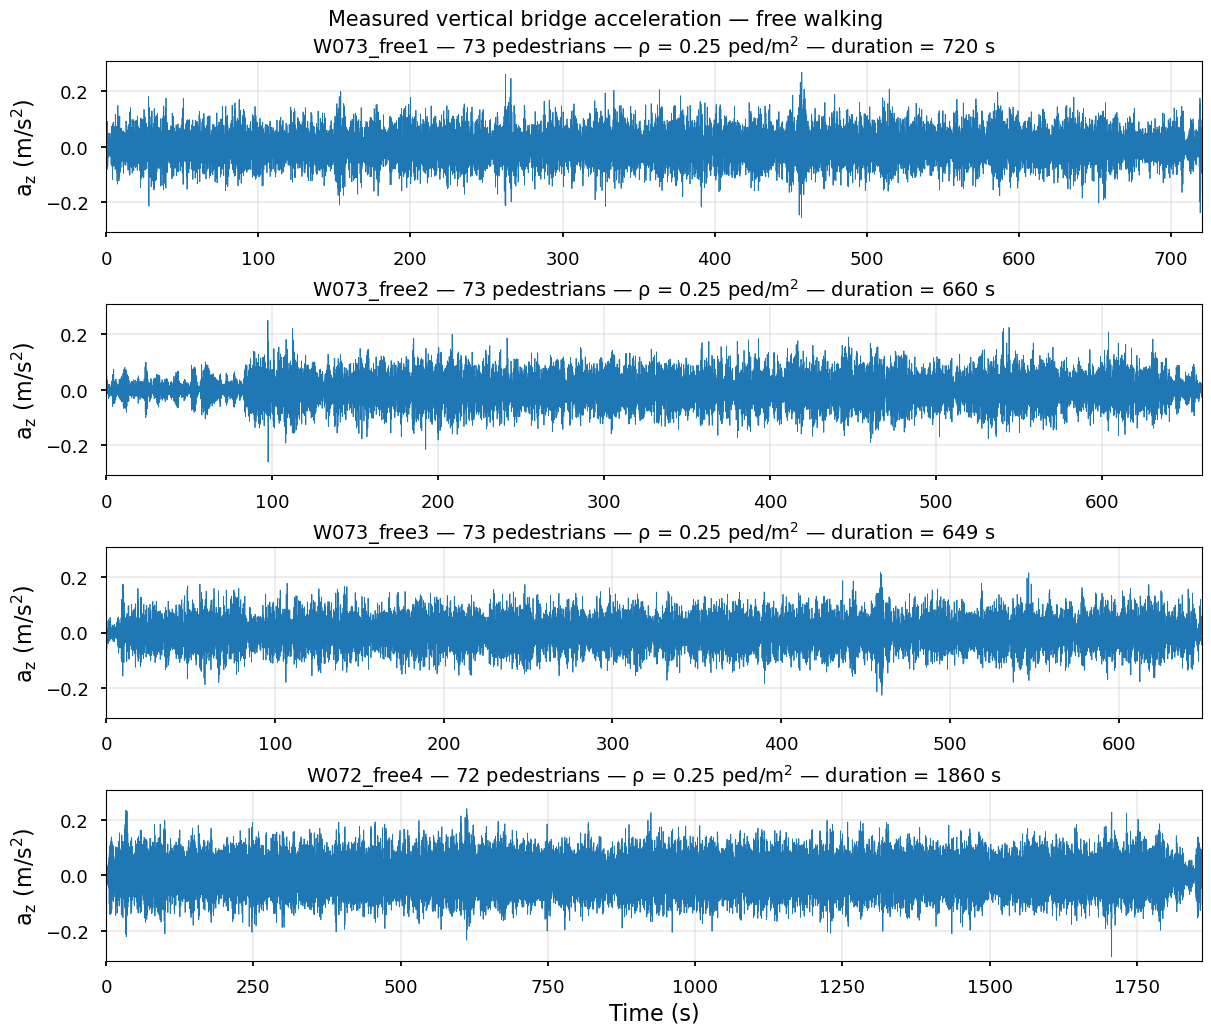

,Test,Pedestrians,Density (ped/m²),Window start (s),Window end (s),Window duration (s),P95 |a| (m/s²),Peak 1-s RMS (m/s²),Peak |a| (m/s²)
0,W073_free1,73,0.25,0.0,600.0,600.0,0.104600,0.129502,0.268132
1,W073_free2,73,0.25,0.0,610.0,610.0,0.098331,0.110964,0.259959
2,W073_free3,73,0.25,0.0,600.0,600.0,0.099695,0.132295,0.225387
3,W072_free4,72,0.25,0.0,1700.0,1700.0,0.103894,0.140241,0.240666



STEADY-STATE EXPERIMENTAL RESPONSE RESULTS — rho = 0.25 ped/m²
      Test  Pedestrians  Density (ped/m²)  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  Peak 1-s RMS (m/s²)  Peak |a| (m/s²)
W073_free1           73              0.25               0.0           600.0                600.0        0.104600             0.129502         0.268132
W073_free2           73              0.25               0.0           610.0                610.0        0.098331             0.110964         0.259959
W073_free3           73              0.25               0.0           600.0                600.0        0.099695             0.132295         0.225387
W072_free4           72              0.25               0.0          1700.0               1700.0        0.103894             0.140241         0.240666


In [79]:
# ============================================================
# EEKLO rho = 0.25 ped/m² FREE-WALKING EXPERIMENTS
#
# Tests:
#
#   W073_free1 : 720 s  : 73 pedestrians
#   W073_free2 : 660 s  : 73 pedestrians
#   W073_free3 : 649 s  : 73 pedestrians
#   W072_free4 : 1860 s : 72 pedestrians
#
# Processing:
#
#   1. Assign available samples to reported duration:
#
#           fs_original = N / T
#
#   2. Remove constant offset
#
#   3. Anti-alias resample to exactly 100 Hz
#
#   4. 5th-order Butterworth high-pass at 0.25 Hz
#
#   5. 4th-order Butterworth low-pass at 10 Hz
#
#   6. Plot all four processed histories
#
# Also calculates:
#
#   - Peak 1-second RMS
#   - Peak absolute acceleration
#
# within the steady-state windows used in eeklodata2.ipynb
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
from fractions import Fraction

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import (
    detrend,
    resample_poly,
    butter,
    sosfiltfilt,
)


# ============================================================
# PLOT STYLE
# ============================================================

plt.style.use("seaborn-v0_8-talk")

plt.rcParams["font.monospace"] = "Ubuntu Mono"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"


# ============================================================
# DATA LOCATION
# ============================================================

data_folder = Path(
    r"\\ad.monash.edu\home\User029\slok0019\Documents"
    r"\reading materials\Eeklo data set"
)


# ============================================================
# EXPERIMENT
# ============================================================

density = 0.25          # ped/m²

target_sensor = 214


# ============================================================
# PROCESSING PARAMETERS
# ============================================================

TARGET_FS = 100.0               # Hz

HIGHPASS_CUTOFF_HZ = 0.25      # Hz
HIGHPASS_ORDER = 5

LOWPASS_CUTOFF_HZ = 10.0       # Hz
LOWPASS_ORDER = 4


# ============================================================
# TEST INFORMATION
#
# IMPORTANT:
#
# Fourth experimental label in the table = W072_free4
# Actual MAT filename used by notebook    = W073_free4.mat
# ============================================================

test_settings = {

    1: {
        "file_name": "W073_free1",
        "name": "W073_free1",
        "duration": 720.0,
        "pedestrians": 73,
        "window": (0.0, 600.0),
    },

    2: {
        "file_name": "W073_free2",
        "name": "W073_free2",
        "duration": 660.0,
        "pedestrians": 73,
        "window": (0.0, 610.0),
    },

    3: {
        "file_name": "W073_free3",
        "name": "W073_free3",
        "duration": 649.0,
        "pedestrians": 73,
        "window": (0.0, 600.0),
    },

    4: {
        "file_name": "W073_free4",
        "name": "W072_free4",
        "duration": 1860.0,
        "pedestrians": 72,
        "window": (0.0, 1700.0),
    },
}


# ============================================================
# LOAD VERTICAL ACCELERATION
# ============================================================

def load_vertical_acceleration(
    mat_file,
    sensor_number=214,
):

    with h5py.File(mat_file, "r") as f:

        z_accelerations = np.asarray(
            f["structural_accelerations"]["z"],
            dtype=float,
        )

        sensor_numbers = np.asarray(
            f["structural_accelerations"]["sensors"]
        ).squeeze().astype(int).ravel()


    # --------------------------------------------------------
    # Ensure:
    #
    # rows    = time
    # columns = sensors
    # --------------------------------------------------------

    n_sensors = len(
        sensor_numbers
    )


    if z_accelerations.shape[1] == n_sensors:

        pass

    elif z_accelerations.shape[0] == n_sensors:

        z_accelerations = (
            z_accelerations.T
        )

    else:

        raise ValueError(
            f"Could not determine orientation for "
            f"{mat_file.name}.\n"
            f"Acceleration shape = "
            f"{z_accelerations.shape}\n"
            f"Number of sensors = {n_sensors}"
        )


    # --------------------------------------------------------
    # Find sensor
    # --------------------------------------------------------

    idx = np.where(
        sensor_numbers == sensor_number
    )[0]


    if len(idx) == 0:

        raise ValueError(
            f"Sensor {sensor_number} not found "
            f"in {mat_file.name}.\n"
            f"Available sensors: "
            f"{sensor_numbers.tolist()}"
        )


    acceleration = np.asarray(
        z_accelerations[
            :,
            int(idx[0]),
        ],
        dtype=float,
    ).copy()


    return acceleration


# ============================================================
# RESAMPLE TO EXACTLY 100 Hz
# ============================================================

def resample_to_100Hz(
    acceleration,
    duration,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()


    # --------------------------------------------------------
    # Effective original sampling frequency
    #
    # Keep reported physical duration
    # --------------------------------------------------------

    n_original = len(
        acceleration
    )

    fs_original = (
        n_original
        / duration
    )


    # ========================================================
    # STEP 1
    # REMOVE CONSTANT OFFSET
    #
    # This follows the processing used in eeklodata2.ipynb
    # ========================================================

    acceleration_detrended = detrend(
        acceleration,
        type="constant",
    )


    # ========================================================
    # STEP 2
    # ANTI-ALIASED RESAMPLING TO 100 Hz
    # ========================================================

    ratio = Fraction(
        TARGET_FS / fs_original
    ).limit_denominator(
        100000
    )

    up = ratio.numerator
    down = ratio.denominator


    acceleration_100Hz = resample_poly(
        acceleration_detrended,
        up=up,
        down=down,
    )


    # --------------------------------------------------------
    # Exact number of samples required
    # --------------------------------------------------------

    n_target = int(
        round(
            duration
            * TARGET_FS
        )
    )


    if len(acceleration_100Hz) > n_target:

        acceleration_100Hz = (
            acceleration_100Hz[
                :n_target
            ]
        )


    elif len(acceleration_100Hz) < n_target:

        n_missing = (
            n_target
            - len(acceleration_100Hz)
        )

        acceleration_100Hz = np.pad(
            acceleration_100Hz,
            (
                0,
                n_missing,
            ),
            mode="edge",
        )


    # --------------------------------------------------------
    # Exact 100-Hz time vector
    # --------------------------------------------------------

    time_100Hz = (
        np.arange(
            n_target,
            dtype=float,
        )
        / TARGET_FS
    )


    return (
        time_100Hz,
        acceleration_100Hz,
        fs_original,
        up,
        down,
    )


# ============================================================
# STRUCTURAL RESPONSE FILTERS
#
# 0.25-Hz high-pass
# +
# 10-Hz low-pass
# ============================================================

def apply_structural_response_filters(
    acceleration,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()


    # ========================================================
    # HIGH-PASS
    # 5th-order Butterworth, 0.25 Hz
    # ========================================================

    highpass_sos = butter(
        N=HIGHPASS_ORDER,
        Wn=HIGHPASS_CUTOFF_HZ,
        btype="highpass",
        fs=TARGET_FS,
        output="sos",
    )


    acceleration_highpassed = sosfiltfilt(
        highpass_sos,
        acceleration,
    )


    # ========================================================
    # LOW-PASS
    # 4th-order Butterworth, 10 Hz
    # ========================================================

    lowpass_sos = butter(
        N=LOWPASS_ORDER,
        Wn=LOWPASS_CUTOFF_HZ,
        btype="lowpass",
        fs=TARGET_FS,
        output="sos",
    )


    acceleration_filtered = sosfiltfilt(
        lowpass_sos,
        acceleration_highpassed,
    )


    # --------------------------------------------------------
    # Remove tiny numerical residual mean
    # --------------------------------------------------------

    acceleration_filtered = (
        acceleration_filtered
        - np.mean(
            acceleration_filtered
        )
    )


    return acceleration_filtered


# ============================================================
# PROCESS ALL FOUR EXPERIMENTS
# ============================================================

results = {}


for test_number, settings in test_settings.items():

    # --------------------------------------------------------
    # MAT file
    # --------------------------------------------------------

    mat_file = (
        data_folder
        / f"{settings['file_name']}.mat"
    )


    print(
        "\n"
        + "=" * 75
    )

    print(
        f"Processing: {settings['name']}"
    )

    print(
        f"MAT file:   {mat_file.name}"
    )


    # --------------------------------------------------------
    # Load raw vertical acceleration
    # --------------------------------------------------------

    acceleration_original = (
        load_vertical_acceleration(
            mat_file=mat_file,
            sensor_number=target_sensor,
        )
    )


    duration = float(
        settings["duration"]
    )


    # --------------------------------------------------------
    # Detrend + resample
    # --------------------------------------------------------

    (
        time_100Hz,
        acceleration_100Hz,
        fs_original,
        up,
        down,
    ) = resample_to_100Hz(

        acceleration=acceleration_original,

        duration=duration,
    )


    # --------------------------------------------------------
    # Apply 0.25–10 Hz structural response filtering
    # --------------------------------------------------------

    acceleration_filtered = (
        apply_structural_response_filters(
            acceleration_100Hz
        )
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results[
        test_number
    ] = {

        "name":
            settings["name"],

        "file_name":
            settings["file_name"],

        "pedestrians":
            settings["pedestrians"],

        "density":
            density,

        "duration":
            duration,

        "window":
            settings["window"],

        "fs_original":
            fs_original,

        "fs_final":
            TARGET_FS,

        "time":
            time_100Hz,

        "acceleration_original":
            acceleration_original,

        "acceleration_100Hz":
            acceleration_100Hz,

        "acceleration_filtered":
            acceleration_filtered,
    }


    # --------------------------------------------------------
    # Print checks
    # --------------------------------------------------------

    print(
        f"Original samples       = "
        f"{len(acceleration_original)}"
    )

    print(
        f"Reported duration      = "
        f"{duration:.1f} s"
    )

    print(
        f"Effective original fs  = "
        f"{fs_original:.6f} Hz"
    )

    print(
        f"Resampling ratio       = "
        f"{up}/{down}"
    )

    print(
        f"Final fs               = "
        f"{TARGET_FS:.1f} Hz"
    )

    print(
        f"Final samples          = "
        f"{len(acceleration_filtered)}"
    )

    print(
        f"Final duration         = "
        f"{len(acceleration_filtered)/TARGET_FS:.1f} s"
    )

    print(
        f"Passband               = "
        f"{HIGHPASS_CUTOFF_HZ:.2f}"
        f"–{LOWPASS_CUTOFF_HZ:.1f} Hz"
    )


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "rho = 0.25 ped/m² — PROCESSING SUMMARY"
)

print(
    "=" * 90
)


for test_number, result in results.items():

    print(

        f"{result['name']:12s} | "

        f"Nped = "
        f"{result['pedestrians']:2d} | "

        f"T = "
        f"{result['duration']:7.1f} s | "

        f"fs_original = "
        f"{result['fs_original']:10.4f} Hz | "

        f"fs_final = "
        f"{result['fs_final']:6.1f} Hz"
    )


# ============================================================
# COMMON Y-AXIS LIMIT
# ============================================================

global_peak = max(

    np.max(
        np.abs(
            result[
                "acceleration_filtered"
            ]
        )
    )

    for result in results.values()
)


y_limit = (
    1.05
    * global_peak
)


# ============================================================
# PLOT ALL FOUR TIME HISTORIES
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(
        12,
        10,
    ),
    sharey=True,
    constrained_layout=True,
)


for ax, (
    test_number,
    result,
) in zip(
    axes,
    results.items(),
):


    ax.plot(
        result["time"],
        result[
            "acceleration_filtered"
        ],
        linewidth=0.6,
    )


    ax.set_xlim(
        0,
        result["duration"],
    )


    ax.set_ylim(
        -y_limit,
        y_limit,
    )


    ax.set_ylabel(
        r"$a_z$ (m/s$^2$)"
    )


    ax.set_title(

        f"{result['name']} "
        f"— {result['pedestrians']} pedestrians "
        f"— $\\rho$ = {density:.2f} ped/m$^2$ "
        f"— duration = "
        f"{result['duration']:.0f} s"
    )


    ax.grid(
        True,
        alpha=0.25,
    )


axes[-1].set_xlabel(
    "Time (s)"
)


fig.suptitle(
    "Measured vertical bridge acceleration — free walking",
    y=1.02,
)


plt.show()


# ============================================================
# PEAK 1-SECOND RMS FUNCTION
# ============================================================

def peak_1s_rms(
    acceleration,
    fs=100.0,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float,
    ).squeeze()


    window_samples = int(
        round(
            fs
        )
    )


    mean_square = np.convolve(

        acceleration**2,

        np.ones(
            window_samples
        )
        / window_samples,

        mode="valid",
    )


    rms_1s = np.sqrt(
        mean_square
    )


    return np.max(
        rms_1s
    )


# ============================================================
# RESPONSE STATISTICS IN STEADY WINDOWS
#
# Windows taken from eeklodata2.ipynb:
#
#   Test 1 : 100–600 s
#   Test 2 : 110–610 s
#   Test 3 : 100–600 s
#   Test 4 : 100–600 s
# ============================================================

response_results = []


for test_number, result in results.items():

    t_start, t_end = (
        result["window"]
    )


    time = result[
        "time"
    ]

    acceleration = result[
        "acceleration_filtered"
    ]


    # --------------------------------------------------------
    # Select steady-state portion
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    acceleration_steady = (
        acceleration[
            mask
        ]
    )


    # --------------------------------------------------------
    # 95th percentile absolute acceleration
    # --------------------------------------------------------

    absolute_acceleration = np.abs(
        acceleration_steady
    )


    a95 = np.percentile(
        absolute_acceleration,
        95
    )


    # --------------------------------------------------------
    # Peak 1-second RMS
    # --------------------------------------------------------

    peak_rms = peak_1s_rms(
        acceleration_steady,
        fs=TARGET_FS,
    )


    # --------------------------------------------------------
    # Peak absolute acceleration
    # --------------------------------------------------------

    peak_absolute = np.max(
        np.abs(
            acceleration_steady
        )
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    response_results.append({

        "Test":
            result["name"],

        "Pedestrians":
            result["pedestrians"],

        "Density (ped/m²)":
            density,

        "Window start (s)":
            t_start,

        "Window end (s)":
            t_end,

        "Window duration (s)":
            t_end - t_start,

        "P95 |a| (m/s²)":
            a95,

        "Peak 1-s RMS (m/s²)":
            peak_rms,

        "Peak |a| (m/s²)":
            peak_absolute,
    })


# ============================================================
# TABLE
# ============================================================

response_df = pd.DataFrame(
    response_results
)


display_df = response_df.copy()


display_df[
    "P95 |a| (m/s²)"
] = display_df[
    "P95 |a| (m/s²)"
].round(6)



display_df[
    "Peak 1-s RMS (m/s²)"
] = display_df[
    "Peak 1-s RMS (m/s²)"
].round(6)


display_df[
    "Peak |a| (m/s²)"
] = display_df[
    "Peak |a| (m/s²)"
].round(6)


display(
    display_df
)


print(
    "\n"
    + "=" * 120
)

print(
    "STEADY-STATE EXPERIMENTAL RESPONSE RESULTS — rho = 0.25 ped/m²"
)

print(
    "=" * 120
)


print(
    display_df.to_string(
        index=False
    )
)

In [64]:
# ============================================================
# CALCULATE PROPOSED MODIFICATION FACTORS
# FOR EACH MODE
#
# rho = 0.25 ped/m²
# ============================================================

import numpy as np
from scipy.integrate import quad


# ============================================================
# BASIC DATA
# ============================================================

length = 96.0
width = 2.0

density = 0.25                 # ped/m²
pedestrian_mass = 70.0         # kg


beamFreq = np.array([
    1.71,
    2.99
])


modalDampingRatio = np.array([
    0.0194,
    0.0019
])


modalmass = np.array([
    202000.0,
    22000.0
])


# ============================================================
# MODE SHAPES
# ============================================================

def curve1(x):

    return (
        1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03
    )


def curve2(x):

    return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )


func_list = [
    curve1,
    curve2
]


# ============================================================
# PEDESTRIAN LINEAR MASS
#
# m_p = pedestrian mass × density × bridge width
#
#     = 70 × 0.25 × 2
#     = 35 kg/m
# ============================================================

ped_linear_mass = (
    pedestrian_mass
    * density
    * width
)


print(
    f"Pedestrian linear mass = "
    f"{ped_linear_mass:.3f} kg/m"
)


# ============================================================
# PEDESTRIAN MODAL MASSES
#
# Mp,j = integral_0^L m_p phi_j(x)^2 dx
# ============================================================

ped_modal_mass = np.zeros(
    2
)


for j, phi in enumerate(
    func_list
):

    integral_phi2, _ = quad(

        lambda x: phi(x)**2,

        0,

        length
    )


    ped_modal_mass[j] = (
        ped_linear_mass
        * integral_phi2
    )


# ============================================================
# MODAL MASS RATIOS
#
# mu_j = Mp,j / Mj
# ============================================================

mu = (
    ped_modal_mass
    / modalmass
)


# ============================================================
# OLD psi
#
# This is the psi already used internally by Newmarksuper_Code
# ============================================================

def psi_old(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(
        x
    )


    # --------------------------------------------------------
    # 1.25–1.70 : 0 -> 1
    # --------------------------------------------------------

    m = (
        (x >= 1.25)
        &
        (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        /
        (1.70 - 1.25)
    )


    # --------------------------------------------------------
    # 1.70–2.10 : 1
    # --------------------------------------------------------

    m = (
        (x >= 1.70)
        &
        (x <= 2.10)
    )

    psi[m] = 1.0


    # --------------------------------------------------------
    # 2.10–2.30 : 1 -> 0
    # --------------------------------------------------------

    m = (
        (x > 2.10)
        &
        (x < 2.30)
    )

    psi[m] = (
        1.0
        -
        (x[m] - 2.10)
        /
        (2.30 - 2.10)
    )


    # --------------------------------------------------------
    # 2.50–3.40 : 0 -> 0.25
    # --------------------------------------------------------

    m = (
        (x > 2.50)
        &
        (x < 3.40)
    )

    psi[m] = (
        0.25
        *
        (x[m] - 2.50)
        /
        (3.40 - 2.50)
    )


    # --------------------------------------------------------
    # 3.40–4.20 : 0.25
    # --------------------------------------------------------

    m = (
        (x >= 3.40)
        &
        (x <= 4.20)
    )

    psi[m] = 0.25


    # --------------------------------------------------------
    # 4.20–4.60 : 0.25 -> 0
    # --------------------------------------------------------

    m = (
        (x > 4.20)
        &
        (x <= 4.60)
    )

    psi[m] = (
        0.25
        *
        (
            1.0
            -
            (x[m] - 4.20)
            /
            (4.60 - 4.20)
        )
    )


    # --------------------------------------------------------
    # Minimum rule:
    #
    # 2.25 <= f <= 3.00
    #
    # psi_old >= 0.25
    # --------------------------------------------------------

    m = (
        (x >= 2.25)
        &
        (x <= 3.0)
    )

    psi[m] = np.maximum(
        psi[m],
        0.25
    )


    return psi


# ============================================================
# NEW psi
# Equation (38)
# ============================================================

def psi_new(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(
        x
    )


    # --------------------------------------------------------
    # f < 1.25
    # --------------------------------------------------------

    m = (
        x < 1.25
    )

    psi[m] = 0.0


    # --------------------------------------------------------
    # 1.25 <= f < 1.70
    # --------------------------------------------------------

    m = (
        (x >= 1.25)
        &
        (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        /
        0.45
    )


    # --------------------------------------------------------
    # 1.70 <= f < 2.50
    # --------------------------------------------------------

    m = (
        (x >= 1.70)
        &
        (x < 2.50)
    )

    psi[m] = 1.0


    # --------------------------------------------------------
    # 2.50 <= f < 2.75
    # --------------------------------------------------------

    m = (
        (x >= 2.50)
        &
        (x < 2.75)
    )

    psi[m] = (
        1.0
        -
        3.0
        *
        (x[m] - 2.50)
    )


    # --------------------------------------------------------
    # 2.75 <= f < 4.20
    # --------------------------------------------------------

    m = (
        (x >= 2.75)
        &
        (x < 4.20)
    )

    psi[m] = 0.25


    # --------------------------------------------------------
    # 4.20 <= f <= 4.60
    # --------------------------------------------------------

    m = (
        (x >= 4.20)
        &
        (x <= 4.60)
    )

    psi[m] = (
        0.25
        *
        (4.60 - x[m])
        /
        0.40
    )


    # --------------------------------------------------------
    # f > 4.60
    # --------------------------------------------------------

    m = (
        x > 4.60
    )

    psi[m] = 0.0


    return psi


# ============================================================
# LOW-DENSITY RESIDUAL CORRECTION
#
# rho < 1 ped/m²
#
# c_final^LD =
#
# 0.4 - 0.6 mu + 5 xi + 44 mu xi
# ============================================================

def c_final_LD(
    mu,
    xi
):

    return (
        0.4
        - 0.6 * mu
        + 5.0 * xi
        + 44.0 * mu * xi
    )


# ============================================================
# CALCULATE VALUES
# ============================================================

c_final = c_final_LD(
    mu,
    modalDampingRatio
)


psi_old_values = psi_old(
    beamFreq
)


psi_new_values = psi_new(
    beamFreq
)


# ============================================================
# MODIFICATION FACTOR PASSED TO EXISTING NEWMARK SOLVER
#
# Solver already contains:
#
#       psi_old
#
# Desired force factor:
#
#       psi_new * c_final
#
# Therefore:
#
#               psi_new * c_final
# R_j =        -------------------
#                    psi_old
# ============================================================

modification_factor = (
    psi_new_values
    *
    c_final
    /
    psi_old_values
)


# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "PROPOSED MODIFICATION FACTORS — rho = 0.25 ped/m²"
)

print(
    "=" * 70
)


for j in range(2):

    print(
        "\n"
        + "=" * 55
    )

    print(
        f"MODE {j + 1}"
    )


    print(
        f"Frequency               = "
        f"{beamFreq[j]:.3f} Hz"
    )


    print(
        f"Structural damping      = "
        f"{modalDampingRatio[j]:.5f}"
    )


    print(
        f"Structural modal mass   = "
        f"{modalmass[j]:.2f} kg"
    )


    print(
        f"Pedestrian modal mass   = "
        f"{ped_modal_mass[j]:.2f} kg"
    )


    print(
        f"Modal mass ratio mu     = "
        f"{mu[j]:.6f}"
    )


    print(
        f"Old psi                 = "
        f"{psi_old_values[j]:.6f}"
    )


    print(
        f"New psi                 = "
        f"{psi_new_values[j]:.6f}"
    )


    print(
        f"c_final LD              = "
        f"{c_final[j]:.6f}"
    )


    print(
        f"Solver modification     = "
        f"{modification_factor[j]:.6f}"
    )

Pedestrian linear mass = 35.000 kg/m

PROPOSED MODIFICATION FACTORS — rho = 0.25 ped/m²

MODE 1
Frequency               = 1.710 Hz
Structural damping      = 0.01940
Structural modal mass   = 202000.00 kg
Pedestrian modal mass   = 1499.68 kg
Modal mass ratio mu     = 0.007424
Old psi                 = 1.000000
New psi                 = 1.000000
c_final LD              = 0.498883
Solver modification     = 0.498883

MODE 2
Frequency               = 2.990 Hz
Structural damping      = 0.00190
Structural modal mass   = 22000.00 kg
Pedestrian modal mass   = 896.94 kg
Modal mass ratio mu     = 0.040770
Old psi                 = 0.250000
New psi                 = 0.250000
c_final LD              = 0.388446
Solver modification     = 0.388446


Density = 0.250 ped/m²
Pedestrian linear mass = 35.000 kg/m

MODAL CORRECTION FACTORS — rho = 0.25 ped/m²

MODE 1
Frequency               = 1.710 Hz
Structural damping      = 0.01940
Structural modal mass   = 202000.000 kg
Pedestrian modal mass   = 1499.684 kg
Modal mass ratio mu     = 0.007424
psi_old                 = 1.000000
psi_new                 = 1.000000
c_final                 = 0.498883
Solver modification     = 0.498883

MODE 2
Frequency               = 2.990 Hz
Structural damping      = 0.00190
Structural modal mass   = 22000.000 kg
Pedestrian modal mass   = 896.941 kg
Modal mass ratio mu     = 0.040770
psi_old                 = 0.250000
psi_new                 = 0.250000
c_final                 = 0.388446
Solver modification     = 0.388446

RUNNING MODE 1

RUNNING MODE 2


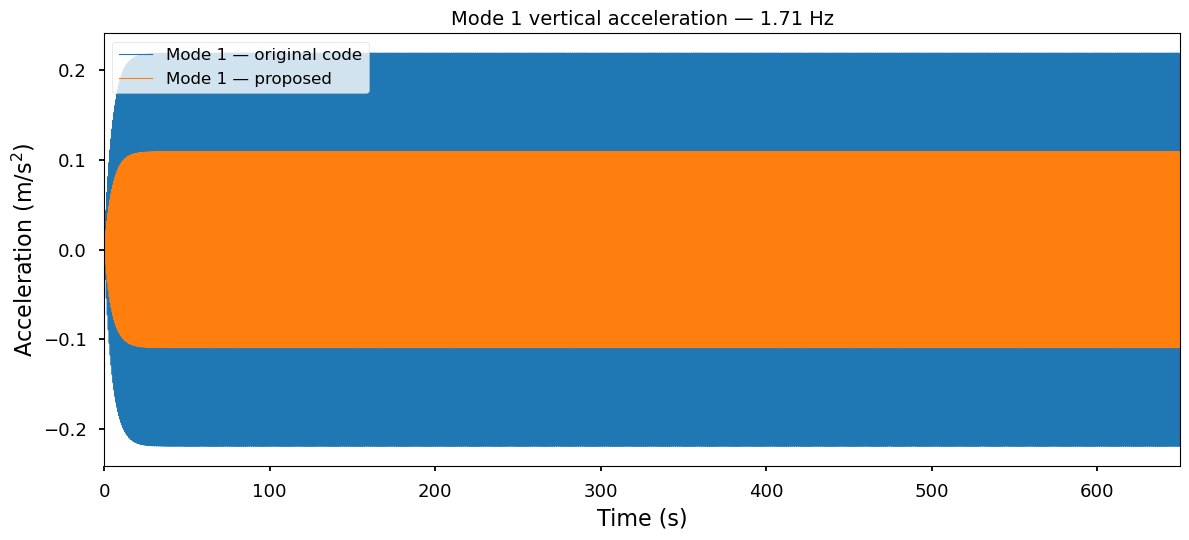

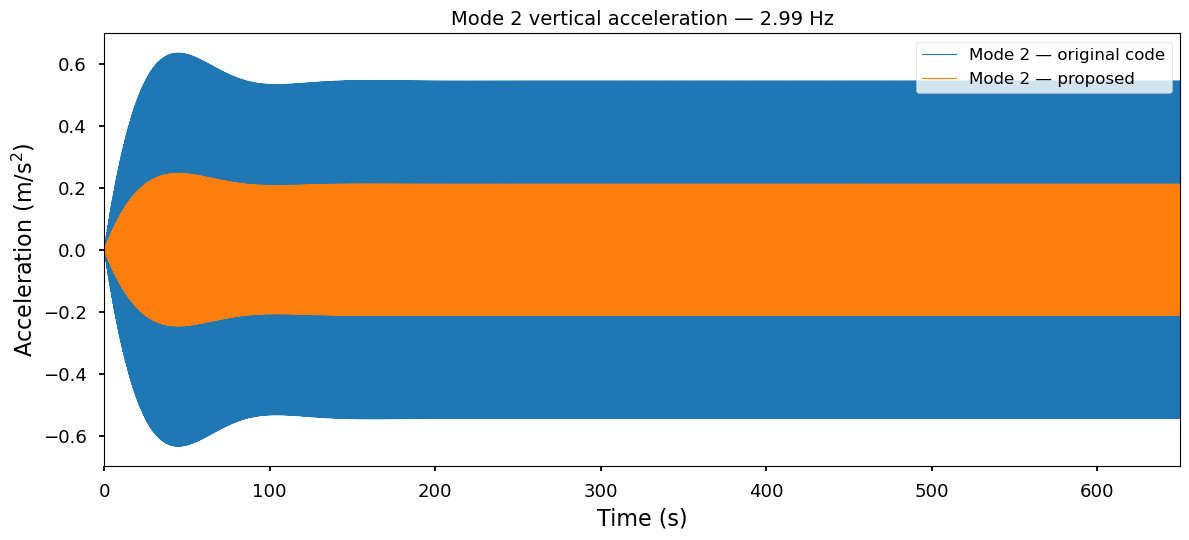

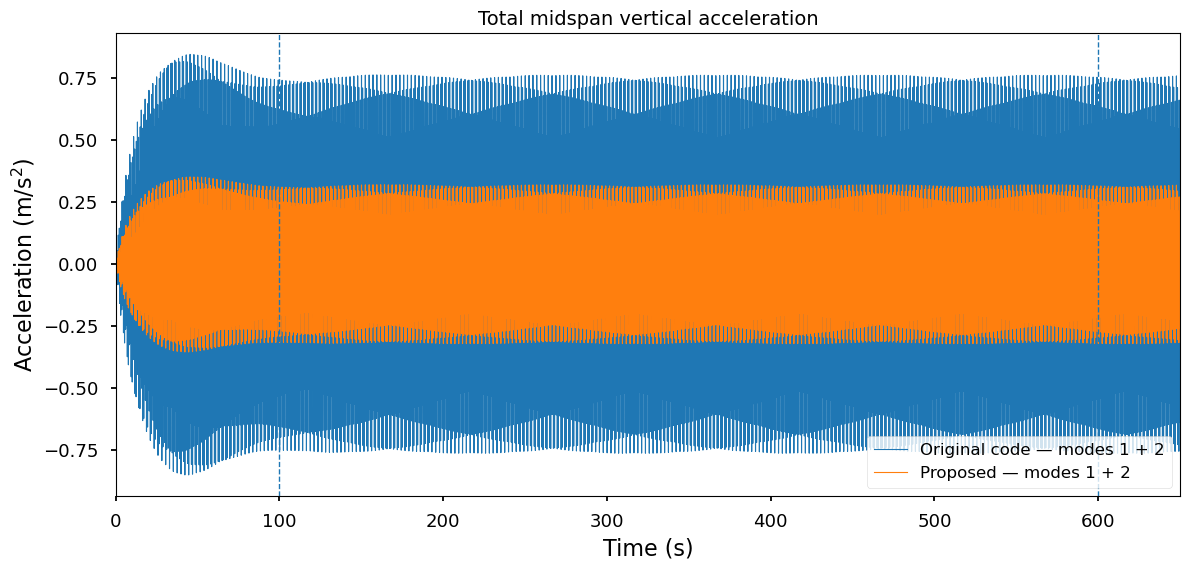

,Test,Window start (s),Window end (s),Window duration (s),P95 |a| (m/s²),Peak 1-s RMS (m/s²),Peak |a| (m/s²)
0,Original code,100.0,600.0,500.0,0.710801,0.452833,0.764493
1,Proposed code,100.0,600.0,500.0,0.297799,0.186429,0.321053



ORIGINAL CODE vs PROPOSED CODE — rho = 0.25 ped/m²
         Test  Window start (s)  Window end (s)  Window duration (s)  P95 |a| (m/s²)  Peak 1-s RMS (m/s²)  Peak |a| (m/s²)
Original code             100.0           600.0                500.0        0.710801             0.452833         0.764493
Proposed code             100.0           600.0                500.0        0.297799             0.186429         0.321053


In [65]:
# ============================================================
# EEKLO rho = 0.25 ped/m²
#
# ORIGINAL CODE vs PROPOSED CODE
#
# TWO MODES RUN SEPARATELY AND THEN SUPERIMPOSED
#
# Final comparison statistics:
#
#   1. P95 |a|
#   2. Peak 1-second RMS
#   3. Peak |a|
#
# Steady-state comparison window:
#
#   100–600 s = 500 s
# ============================================================


from matrix import *
from solver import *
from pedestrian import *

from matplotlib import pyplot as plt

import math
import numpy as np
import pandas as pd

from scipy.integrate import quad


# ============================================================
# 1. GLOBAL BRIDGE DATA
# ============================================================

length = 96.0
width = 2.0
height = 0.6

linearMass = 1020.0

x_interested = length / 2


# ============================================================
# 2. MODAL DATA
# ============================================================

beamFreq = np.array([
    1.71,
    2.99,
])


modalDampingRatio = np.array([
    0.0194,      # Mode 1 = 1.94%
    0.0019,      # Mode 2 = 0.19%
])


modalmass = np.array([
    202000.0,    # kg
    22000.0,     # kg
])


# ============================================================
# 3. MODE SHAPES
# ============================================================

def curve1(x):

    return (
        1.71144429e-14 * x**8
        - 6.76029672e-12 * x**7
        + 1.05320380e-09 * x**6
        - 8.14053964e-08 * x**5
        + 3.27033830e-06 * x**4
        - 7.15713216e-05 * x**3
        + 7.95784053e-04 * x**2
        + 2.20681765e-02 * x
        + 2.26628021e-03
    )


def curve2(x):

    return (
        -8.02321495e-16 * x**9
        + 4.32499733e-13 * x**8
        - 9.53553597e-11 * x**7
        + 1.09530960e-08 * x**6
        - 6.90120316e-07 * x**5
        + 2.30469265e-05 * x**4
        - 3.76429912e-04 * x**3
        + 3.46209330e-03 * x**2
        - 1.90877156e-02 * x
        + 3.95334984e-04
    )


func_list_all = [
    curve1,
    curve2,
]


# ============================================================
# 4. TIME SETTINGS
# ============================================================

hht = 0.01

# Needs to extend beyond the end of our comparison window
t_end = 650.0


# ============================================================
# STEADY-STATE COMPARISON WINDOW
#
# Same 500-s duration as the measured rho = 0.25 histories
# ============================================================

window_start = 100.0
window_end = 600.0


# ============================================================
# 5. PEDESTRIAN DATA
# ============================================================

density = 0.25                 # ped/m²

average_pedestrian_mass = 70.0  # kg


# ============================================================
# PEDESTRIAN LINEAR MASS
#
# m_p = 70 × 0.25 × 2
#
#     = 35 kg/m
# ============================================================

pedestrian_linear_mass = (
    average_pedestrian_mass
    * density
    * width
)


print(
    f"Density = "
    f"{density:.3f} ped/m²"
)

print(
    f"Pedestrian linear mass = "
    f"{pedestrian_linear_mass:.3f} kg/m"
)


# ============================================================
# 6. PEDESTRIAN MODAL MASSES
#
# Mp,j = integral_0^L m_p phi_j^2 dx
# ============================================================

ped_modal_mass = np.zeros(
    2
)


for j, phi in enumerate(
    func_list_all
):

    integral_phi_squared, _ = quad(

        lambda x: phi(x)**2,

        0,

        length
    )


    ped_modal_mass[j] = (
        pedestrian_linear_mass
        * integral_phi_squared
    )


# ============================================================
# 7. MODAL MASS RATIOS
#
# mu_j = Mp,j / Ms,j
# ============================================================

mu = (
    ped_modal_mass
    / modalmass
)


# ============================================================
# 8. OLD psi
#
# This is the psi already applied internally by
# Newmarksuper_Code()
# ============================================================

def psi_old(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(
        x
    )


    # --------------------------------------------------------
    # 1.25–1.70 : 0 -> 1
    # --------------------------------------------------------

    m = (
        (x >= 1.25)
        &
        (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        /
        (1.70 - 1.25)
    )


    # --------------------------------------------------------
    # 1.70–2.10 : 1
    # --------------------------------------------------------

    m = (
        (x >= 1.70)
        &
        (x <= 2.10)
    )

    psi[m] = 1.0


    # --------------------------------------------------------
    # 2.10–2.30 : 1 -> 0
    # --------------------------------------------------------

    m = (
        (x > 2.10)
        &
        (x < 2.30)
    )

    psi[m] = (
        1.0
        -
        (x[m] - 2.10)
        /
        (2.30 - 2.10)
    )


    # --------------------------------------------------------
    # 2.50–3.40 : 0 -> 0.25
    # --------------------------------------------------------

    m = (
        (x > 2.50)
        &
        (x < 3.40)
    )

    psi[m] = (
        0.25
        *
        (x[m] - 2.50)
        /
        (3.40 - 2.50)
    )


    # --------------------------------------------------------
    # 3.40–4.20 : 0.25
    # --------------------------------------------------------

    m = (
        (x >= 3.40)
        &
        (x <= 4.20)
    )

    psi[m] = 0.25


    # --------------------------------------------------------
    # 4.20–4.60 : 0.25 -> 0
    # --------------------------------------------------------

    m = (
        (x > 4.20)
        &
        (x <= 4.60)
    )

    psi[m] = (
        0.25
        *
        (
            1.0
            -
            (x[m] - 4.20)
            /
            (4.60 - 4.20)
        )
    )


    # --------------------------------------------------------
    # Minimum rule
    #
    # 2.25 <= f <= 3.00
    #
    # psi_old >= 0.25
    # --------------------------------------------------------

    m = (
        (x >= 2.25)
        &
        (x <= 3.0)
    )

    psi[m] = np.maximum(
        psi[m],
        0.25
    )


    return psi


# ============================================================
# 9. NEW psi
# ============================================================

def psi_new(x):

    x = np.asarray(
        x,
        dtype=float
    )

    psi = np.zeros_like(
        x
    )


    # --------------------------------------------------------
    # 1.25 <= f < 1.70
    # --------------------------------------------------------

    m = (
        (x >= 1.25)
        &
        (x < 1.70)
    )

    psi[m] = (
        (x[m] - 1.25)
        /
        0.45
    )


    # --------------------------------------------------------
    # 1.70 <= f < 2.50
    # --------------------------------------------------------

    m = (
        (x >= 1.70)
        &
        (x < 2.50)
    )

    psi[m] = 1.0


    # --------------------------------------------------------
    # 2.50 <= f < 2.75
    # --------------------------------------------------------

    m = (
        (x >= 2.50)
        &
        (x < 2.75)
    )

    psi[m] = (
        1.0
        -
        3.0
        *
        (x[m] - 2.50)
    )


    # --------------------------------------------------------
    # 2.75 <= f < 4.20
    # --------------------------------------------------------

    m = (
        (x >= 2.75)
        &
        (x < 4.20)
    )

    psi[m] = 0.25


    # --------------------------------------------------------
    # 4.20 <= f <= 4.60
    # --------------------------------------------------------

    m = (
        (x >= 4.20)
        &
        (x <= 4.60)
    )

    psi[m] = (
        0.25
        *
        (4.60 - x[m])
        /
        0.40
    )


    return psi


# ============================================================
# 10. LOW-DENSITY CORRECTION
#
# rho < 1 ped/m²
#
# c_final =
#
# 0.4 - 0.6 mu + 5 xi + 44 mu xi
# ============================================================

def c_final_LD(
    mu,
    xi
):

    return (
        0.4
        - 0.6 * mu
        + 5.0 * xi
        + 44.0 * mu * xi
    )


# ============================================================
# 11. CALCULATE MODIFICATION FACTORS
# ============================================================

psi_old_values = psi_old(
    beamFreq
)


psi_new_values = psi_new(
    beamFreq
)


c_final_values = c_final_LD(
    mu,
    modalDampingRatio
)


# ============================================================
# Existing solver already applies psi_old.
#
# We want:
#
#     psi_new × c_final
#
# Therefore:
#
# modification =
#
#     psi_new × c_final
#     -----------------
#          psi_old
# ============================================================

modification_factor = (
    psi_new_values
    *
    c_final_values
    /
    psi_old_values
)


# ============================================================
# PRINT MODAL PARAMETERS
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "MODAL CORRECTION FACTORS — rho = 0.25 ped/m²"
)

print(
    "=" * 75
)


for j in range(2):

    print(
        f"\nMODE {j + 1}"
    )

    print(
        f"Frequency               = "
        f"{beamFreq[j]:.3f} Hz"
    )

    print(
        f"Structural damping      = "
        f"{modalDampingRatio[j]:.5f}"
    )

    print(
        f"Structural modal mass   = "
        f"{modalmass[j]:.3f} kg"
    )

    print(
        f"Pedestrian modal mass   = "
        f"{ped_modal_mass[j]:.3f} kg"
    )

    print(
        f"Modal mass ratio mu     = "
        f"{mu[j]:.6f}"
    )

    print(
        f"psi_old                 = "
        f"{psi_old_values[j]:.6f}"
    )

    print(
        f"psi_new                 = "
        f"{psi_new_values[j]:.6f}"
    )

    print(
        f"c_final                 = "
        f"{c_final_values[j]:.6f}"
    )

    print(
        f"Solver modification     = "
        f"{modification_factor[j]:.6f}"
    )


# ============================================================
# EXPECTED APPROXIMATE VALUES
#
# MODE 1:
#
# pedestrian modal mass ~= 1499.68 kg
# mu                    ~= 0.007424
# c_final               ~= 0.498883
# modification factor   ~= 0.498883
#
#
# MODE 2:
#
# pedestrian modal mass ~= 896.94 kg
# mu                    ~= 0.040770
# c_final               ~= 0.388446
# modification factor   ~= 0.388446
# ============================================================


# ============================================================
# 12. FUNCTION TO RUN ONE MODE
# ============================================================

def run_single_mode(
    mode_index,
    force_factor,
):

    # --------------------------------------------------------
    # Modal properties
    # --------------------------------------------------------

    f_j = np.array([
        beamFreq[mode_index]
    ])


    xi_j = np.array([
        modalDampingRatio[
            mode_index
        ]
    ])


    mass_j = np.array([
        modalmass[
            mode_index
        ]
    ])


    phi_j = [
        func_list_all[
            mode_index
        ]
    ]


    # --------------------------------------------------------
    # One mode only
    # --------------------------------------------------------

    numbers_j = 1


    # --------------------------------------------------------
    # Effective modulus/stiffness input
    # --------------------------------------------------------

    modulus_j = (
        linearMass
        *
        (
            (2 * math.pi * f_j)
            *
            (math.pi / length) ** (-2)
        ) ** 2
    )


    # --------------------------------------------------------
    # Create single-mode bridge
    # --------------------------------------------------------

    Bridge_j = bridge(

        length=length,

        modulus=modulus_j,

        density=linearMass,

        damp=xi_j,

        numbers=numbers_j,

        freq=f_j,
    )


    # --------------------------------------------------------
    # Run Newmark
    # --------------------------------------------------------

    t, u, du, ddu = Newmarksuper_Code(

        Bridge_j,

        numbers_j,

        length,

        hht,

        t_end,

        width,

        f_j,

        density,

        xi_j,

        density * length * width,

        length * width,

        mass_j,

        phi_j,

        force_reduction_factor=np.array([
            force_factor
        ]),
    )


    # --------------------------------------------------------
    # Physical acceleration at midpoint
    # --------------------------------------------------------

    acceleration = accdyn_super_social(

        Bridge_j,

        ddu,

        x_interested,

        mass_j,

        phi_j,
    )


    acceleration = np.asarray(
        acceleration
    ).squeeze()


    return (
        np.asarray(t).squeeze(),
        acceleration,
        ddu,
    )


# ============================================================
# 13. MODE 1
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "RUNNING MODE 1"
)

print(
    "=" * 75
)


# Original code
t1_code, acc1_code, ddu1_code = run_single_mode(

    mode_index=0,

    force_factor=1.0
)


# Proposed
t1_proposed, acc1_proposed, ddu1_proposed = run_single_mode(

    mode_index=0,

    force_factor=modification_factor[0]
)


# ============================================================
# 14. MODE 2
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "RUNNING MODE 2"
)

print(
    "=" * 75
)


# Original code
t2_code, acc2_code, ddu2_code = run_single_mode(

    mode_index=1,

    force_factor=1.0
)


# Proposed
t2_proposed, acc2_proposed, ddu2_proposed = run_single_mode(

    mode_index=1,

    force_factor=modification_factor[1]
)


# ============================================================
# 15. CHECK TIME VECTORS
# ============================================================

assert np.allclose(
    t1_code,
    t2_code
), (
    "Original-code modal time vectors do not match."
)


assert np.allclose(
    t1_proposed,
    t2_proposed
), (
    "Proposed modal time vectors do not match."
)


assert np.allclose(
    t1_code,
    t1_proposed
), (
    "Original and proposed time vectors do not match."
)


# ============================================================
# 16. TOTAL VERTICAL ACCELERATION
#
# Modal superposition:
#
# a_total(t) = a1(t) + a2(t)
# ============================================================

t_code = t1_code

t_proposed = t1_proposed


acc_code_total = (
    acc1_code
    +
    acc2_code
)


acc_proposed_total = (
    acc1_proposed
    +
    acc2_proposed
)


# ============================================================
# 17. PLOT MODE 1
# ============================================================

plt.figure(
    figsize=(12, 5.5)
)


plt.plot(
    t1_code,
    acc1_code,
    label="Mode 1 — original code",
    linewidth=0.8,
)


plt.plot(
    t1_proposed,
    acc1_proposed,
    label="Mode 1 — proposed",
    linewidth=0.8,
)


plt.xlim(
    0,
    t_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Mode 1 vertical acceleration — 1.71 Hz"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 18. PLOT MODE 2
# ============================================================

plt.figure(
    figsize=(12, 5.5)
)


plt.plot(
    t2_code,
    acc2_code,
    label="Mode 2 — original code",
    linewidth=0.8,
)


plt.plot(
    t2_proposed,
    acc2_proposed,
    label="Mode 2 — proposed",
    linewidth=0.8,
)


plt.xlim(
    0,
    t_end
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Mode 2 vertical acceleration — 2.99 Hz"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 19. PLOT TOTAL RESPONSE
# ============================================================

plt.figure(
    figsize=(12, 5.8)
)


plt.plot(
    t_code,
    acc_code_total,
    label="Original code — modes 1 + 2",
    linewidth=0.8,
)


plt.plot(
    t_proposed,
    acc_proposed_total,
    label="Proposed — modes 1 + 2",
    linewidth=0.8,
)


# Show steady-state comparison window
plt.axvline(
    window_start,
    linestyle="--",
    linewidth=1.0,
)

plt.axvline(
    window_end,
    linestyle="--",
    linewidth=1.0,
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    r"Acceleration (m/s$^2$)"
)

plt.title(
    "Total midspan vertical acceleration"
)

plt.xlim(
    0,
    t_end
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 20. PEAK 1-SECOND RMS FUNCTION
# ============================================================

def peak_1s_rms(
    acceleration,
    fs,
):

    acceleration = np.asarray(
        acceleration,
        dtype=float
    ).squeeze()


    # --------------------------------------------------------
    # Samples in one second
    # --------------------------------------------------------

    window_samples = int(
        round(
            fs
        )
    )


    if len(acceleration) < window_samples:

        raise ValueError(
            "Acceleration signal is shorter than 1 second."
        )


    # --------------------------------------------------------
    # Moving mean square
    # --------------------------------------------------------

    mean_square = np.convolve(

        acceleration**2,

        np.ones(
            window_samples
        )
        / window_samples,

        mode="valid"
    )


    # --------------------------------------------------------
    # Moving 1-second RMS
    # --------------------------------------------------------

    rms_1s = np.sqrt(
        mean_square
    )


    return np.max(
        rms_1s
    )


# ============================================================
# 21. SAME STATISTICS AS MEASURED SIGNAL
# ============================================================

def calculate_response_stats(
    name,
    time,
    acceleration,
    t_start,
    t_end,
):

    time = np.asarray(
        time,
        dtype=float
    ).squeeze()


    acceleration = np.asarray(
        acceleration,
        dtype=float
    ).squeeze()


    # --------------------------------------------------------
    # Sampling frequency
    #
    # Newmark hht = 0.01 -> about 100 Hz
    # --------------------------------------------------------

    fs = (
        1.0
        /
        np.median(
            np.diff(time)
        )
    )


    # --------------------------------------------------------
    # Select steady-state window
    # --------------------------------------------------------

    mask = (
        (time >= t_start)
        &
        (time <= t_end)
    )


    acceleration_steady = (
        acceleration[
            mask
        ]
    )


    if len(acceleration_steady) == 0:

        raise ValueError(
            f"No acceleration samples available "
            f"between {t_start} and {t_end} s."
        )


    # ========================================================
    # ABSOLUTE ACCELERATION
    # ========================================================

    abs_acceleration = np.abs(
        acceleration_steady
    )


    # ========================================================
    # 1. P95 ABSOLUTE ACCELERATION
    # ========================================================

    p95 = np.percentile(
        abs_acceleration,
        95
    )


    # ========================================================
    # 2. PEAK 1-SECOND RMS
    # ========================================================

    peak_rms_1s = peak_1s_rms(

        acceleration_steady,

        fs
    )


    # ========================================================
    # 3. PEAK ABSOLUTE ACCELERATION
    # ========================================================

    peak_absolute = np.max(
        abs_acceleration
    )


    return {

        "Test":
            name,

        "Window start (s)":
            t_start,

        "Window end (s)":
            t_end,

        "Window duration (s)":
            t_end - t_start,

        "P95 |a| (m/s²)":
            p95,

        "Peak 1-s RMS (m/s²)":
            peak_rms_1s,

        "Peak |a| (m/s²)":
            peak_absolute,
    }


# ============================================================
# 22. ORIGINAL CODE STATISTICS
# ============================================================

stats_code = calculate_response_stats(

    name="Original code",

    time=t_code,

    acceleration=acc_code_total,

    t_start=window_start,

    t_end=window_end,
)


# ============================================================
# 23. PROPOSED CODE STATISTICS
# ============================================================

stats_proposed = calculate_response_stats(

    name="Proposed code",

    time=t_proposed,

    acceleration=acc_proposed_total,

    t_start=window_start,

    t_end=window_end,
)


# ============================================================
# 24. FINAL COMPARISON TABLE
# ============================================================

stats_df = pd.DataFrame([

    stats_code,

    stats_proposed,
])


display_df = stats_df.copy()


for column in [

    "P95 |a| (m/s²)",

    "Peak 1-s RMS (m/s²)",

    "Peak |a| (m/s²)",

]:

    display_df[column] = (
        display_df[column]
        .round(6)
    )


display(
    display_df
)


print(
    "\n"
    + "=" * 125
)

print(
    "ORIGINAL CODE vs PROPOSED CODE — rho = 0.25 ped/m²"
)

print(
    "=" * 125
)


print(
    display_df.to_string(
        index=False
    )
)